In [ ]:
# Cell 1 — Project setup and reproducibility

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import json
import os

print("=" * 70)
print("NOTEBOOK 04 — FINAL PRECURSOR RISK DATASET")
print("=" * 70)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Resolve project root from notebook location
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Create output directories if they do not already exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print()
print("Project root:")
print(PROJECT_ROOT)

print()
print("Directory check:")

for name, path in {
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "REPORTS_DIR": REPORTS_DIR,
}.items():
    print(f"{name:<15}: {path.exists()}")

print()
print("Random seed:")
print(RANDOM_SEED)

print()
print("Notebook classification:")
print("FINAL DATASET CONSTRUCTION")

print()
print("=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

NOTEBOOK 04 — FINAL PRECURSOR RISK DATASET

Project root:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor

Directory check:
DATA_DIR       : True
RAW_DIR        : False
PROCESSED_DIR  : True
REPORTS_DIR    : True

Random seed:
42

Notebook classification:
FINAL DATASET CONSTRUCTION

CELL 1 COMPLETE


In [ ]:
# Cell 2 — Verify PICS dataset access using WFDB's PhysioNet database interface

PICS_DB = "picsdb"
PICS_VERSION = "1.0.0"

print("=" * 70)
print("PICS DATASET ACCESS CHECK")
print("=" * 70)

print()
print("Database:", PICS_DB)
print("Version:", PICS_VERSION)
print("WFDB version:", wfdb.__version__)

print()
print("Testing access to Infant 1 ECG record...")

try:
    record = wfdb.rdrecord(
        "infant1_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampto=1000
    )

    print("ACCESS: PASS")
    print()
    print("Record name:", record.record_name)
    print("Sampling frequency:", record.fs)
    print("Samples loaded:", record.sig_len)
    print("Channels:", record.n_sig)
    print("Signal names:", record.sig_name)

except Exception as e:
    print("ACCESS: FAIL")
    print()
    print("Error type:", type(e).__name__)
    print("Error:", e)

print()
print("=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

PICS DATASET ACCESS CHECK

Database: picsdb
Version: 1.0.0
WFDB version: 4.3.1

Testing access to Infant 1 ECG record...
ACCESS: PASS

Record name: infant1_ecg
Sampling frequency: 250
Samples loaded: 1000
Channels: 1
Signal names: ['ECG']

CELL 2 COMPLETE


In [ ]:
# Cell 3 — Build PICS subject inventory

print("=" * 70)
print("PICS SUBJECT INVENTORY")
print("=" * 70)

pics_subjects = []

for infant_id in range(1, 11):

    ecg_record_name = f"infant{infant_id}_ecg"
    resp_record_name = f"infant{infant_id}_resp"

    subject_info = {
        "infant": infant_id,
        "ecg_record": ecg_record_name,
        "resp_record": resp_record_name,
        "ecg_available": False,
        "resp_available": False,
        "ecg_fs": np.nan,
        "resp_fs": np.nan,
        "ecg_channels": np.nan,
        "resp_channels": np.nan
    }

    # Check ECG
    try:
        ecg_test = wfdb.rdrecord(
            ecg_record_name,
            pn_dir=f"{PICS_DB}/{PICS_VERSION}",
            sampto=10
        )

        subject_info["ecg_available"] = True
        subject_info["ecg_fs"] = ecg_test.fs
        subject_info["ecg_channels"] = ecg_test.n_sig

    except Exception as e:
        pass

    # Check respiration
    try:
        resp_test = wfdb.rdrecord(
            resp_record_name,
            pn_dir=f"{PICS_DB}/{PICS_VERSION}",
            sampto=10
        )

        subject_info["resp_available"] = True
        subject_info["resp_fs"] = resp_test.fs
        subject_info["resp_channels"] = resp_test.n_sig

    except Exception as e:
        pass

    pics_subjects.append(subject_info)


pics_inventory = pd.DataFrame(pics_subjects)

print()
print(pics_inventory.to_string(index=False))

print()
print("=" * 70)
print("AVAILABILITY SUMMARY")
print("=" * 70)

print()
print(
    "Infants with ECG:",
    pics_inventory["ecg_available"].sum(),
    "/",
    len(pics_inventory)
)

print(
    "Infants with respiration:",
    pics_inventory["resp_available"].sum(),
    "/",
    len(pics_inventory)
)

print()
print("=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

PICS SUBJECT INVENTORY

 infant   ecg_record   resp_record  ecg_available  resp_available  ecg_fs  resp_fs  ecg_channels  resp_channels
      1  infant1_ecg  infant1_resp           True            True     250      500             1              1
      2  infant2_ecg  infant2_resp           True            True     500       50             1              1
      3  infant3_ecg  infant3_resp           True            True     500       50             1              1
      4  infant4_ecg  infant4_resp           True            True     500       50             1              1
      5  infant5_ecg  infant5_resp           True            True     250       50             1              1
      6  infant6_ecg  infant6_resp           True            True     500       50             1              1
      7  infant7_ecg  infant7_resp           True            True     500       50             1              1
      8  infant8_ecg  infant8_resp           True            True     500       

In [ ]:
# Cell 4 — Load validated Stage 3b event-detection results

print("=" * 70)
print("LOADING VALIDATED STAGE 3B EVENT RESULTS")
print("=" * 70)

VALIDATION_RESULTS_PATH = REPORTS_DIR / "pics_multi_infant_validation_results.csv"

print()
print("Input file:")
print(VALIDATION_RESULTS_PATH)

if not VALIDATION_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Required Stage 3b validation file was not found:\n"
        f"{VALIDATION_RESULTS_PATH}"
    )

pics_event_validation = pd.read_csv(VALIDATION_RESULTS_PATH)

print()
print("LOAD: PASS")

print()
print("Dataset shape:")
print(pics_event_validation.shape)

print()
print("Columns:")
for column in pics_event_validation.columns:
    print(" -", column)

print()
print("First rows:")
print(pics_event_validation.head(10).to_string(index=False))

print()
print("=" * 70)
print("EVENT VALIDATION DATASET SUMMARY")
print("=" * 70)

print()
print("Number of rows:", len(pics_event_validation))
print(
    "Number of infants:",
    pics_event_validation["infant"].nunique()
)

print(
    "Infants represented:",
    sorted(pics_event_validation["infant"].unique())
)

print()
print("=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

LOADING VALIDATED STAGE 3B EVENT RESULTS

Input file:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_multi_infant_validation_results.csv

LOAD: PASS

Dataset shape:
(20, 15)

Columns:
 - infant
 - event_number
 - event_time_s
 - ecg_fs
 - resp_fs
 - r_peak_count
 - rr_count
 - bradycardia_run_count
 - resp_suppression_run_count
 - short_resp_with_brady_count
 - bradycardia_only_count
 - apnea_candidate_count
 - respiratory_suppression_count
 - classified_period_count
 - status

First rows:
 infant  event_number  event_time_s  ecg_fs  resp_fs  r_peak_count  rr_count  bradycardia_run_count  resp_suppression_run_count  short_resp_with_brady_count  bradycardia_only_count  apnea_candidate_count  respiratory_suppression_count  classified_period_count  status
      1             1      1971.372   250.0    500.0           147       146                      1                           0                            0                       1                      0         

In [ ]:
# Cell 5 — Inspect the complete validated event inventory

print("=" * 70)
print("COMPLETE VALIDATED EVENT INVENTORY")
print("=" * 70)

display(
    pics_event_validation[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs",
            "resp_fs",
            "bradycardia_run_count",
            "resp_suppression_run_count",
            "short_resp_with_brady_count",
            "bradycardia_only_count",
            "apnea_candidate_count",
            "classified_period_count",
            "status"
        ]
    ].sort_values(
        ["infant", "event_number"]
    ).reset_index(drop=True)
)

print()
print("=" * 70)
print("EVENT COUNTS")
print("=" * 70)

print()
print(
    "Respiratory suppression candidates:",
    int(pics_event_validation["resp_suppression_run_count"].sum())
)

print(
    "Short respiration + bradycardia:",
    int(pics_event_validation["short_resp_with_brady_count"].sum())
)

print(
    "Apnea candidates:",
    int(pics_event_validation["apnea_candidate_count"].sum())
)

print(
    "Bradycardia-only:",
    int(pics_event_validation["bradycardia_only_count"].sum())
)

print()
print("=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

COMPLETE VALIDATED EVENT INVENTORY


,infant,event_number,event_time_s,ecg_fs,resp_fs,bradycardia_run_count,resp_suppression_run_count,short_resp_with_brady_count,bradycardia_only_count,apnea_candidate_count,classified_period_count,status
0,1,1,1971.372,250.0,500.0,1,0,0,1,0,1,success
1,1,2,3456.512,250.0,500.0,2,1,1,1,0,2,success
2,2,1,2235.784,500.0,50.0,1,0,0,1,0,1,success
3,2,2,4210.760,500.0,50.0,2,0,0,2,0,2,success
4,3,2,8143.846,500.0,50.0,3,1,1,2,0,3,success
5,3,3,9427.300,500.0,50.0,5,1,0,5,0,6,success
6,4,1,4790.382,500.0,50.0,1,0,0,1,0,1,success
7,4,2,10966.268,500.0,50.0,1,0,0,1,0,1,success
8,5,1,3650.344,250.0,50.0,2,0,0,2,0,2,success
9,5,2,5923.680,250.0,50.0,0,0,0,0,0,0,success



EVENT COUNTS

Respiratory suppression candidates: 5
Short respiration + bradycardia: 2
Apnea candidates: 0
Bradycardia-only: 29

CELL 5 COMPLETE


In [ ]:
# Cell 6 — Freeze final event-labeling policy

print("=" * 70)
print("FINAL PRECURSOR-RISK EVENT LABELING POLICY")
print("=" * 70)

# ------------------------------------------------------------------
# Risk-label definitions
# ------------------------------------------------------------------

RISK_LABEL = {
    "control": 0,
    "respiratory_risk": 1
}

# Positive event classes
POSITIVE_EVENT_CLASSES = [
    "short_resp_with_brady",
    "respiratory_suppression"
]

# Explicitly excluded event class
EXCLUDED_EVENT_CLASSES = [
    "bradycardia_only"
]

# Apnea candidates are included in the positive definition if they
# are detected by the validated Stage 3 detector.
# At present, Cell 5 shows zero apnea candidates in the selected
# Stage 3b validation events.
OPTIONAL_APNEA_CLASS = "apnea_candidate"

# ------------------------------------------------------------------
# Precursor-window definition
# ------------------------------------------------------------------

PRECURSOR_WINDOW_SECONDS = 15.0

# Prediction window must end at the detected event onset.
# Therefore:
#
# precursor_start = event_time - 15 s
# precursor_end   = event_time
#
# The event itself is NOT used as the prediction window.

EVENT_EXCLUSION_SECONDS = 0.0

# ------------------------------------------------------------------
# Control-window requirements
# ------------------------------------------------------------------

CONTROL_LABEL = 0

# Controls must be sufficiently separated from detected
# respiratory-risk events and bradycardia annotations.
CONTROL_MIN_DISTANCE_SECONDS = 60.0

# Controls must not cross record boundaries.
CONTROL_BOUNDARY_MARGIN_SECONDS = 30.0

# ------------------------------------------------------------------
# Dataset terminology
# ------------------------------------------------------------------

DATASET_TARGET = (
    "Early-warning risk prediction preceding "
    "project-derived respiratory-risk events"
)

CLINICAL_CLAIM = (
    "This dataset does not represent clinically confirmed "
    "neonatal apnea ground truth."
)

# ------------------------------------------------------------------
# Reproducibility metadata
# ------------------------------------------------------------------

labeling_policy = {
    "risk_label": RISK_LABEL,
    "positive_event_classes": POSITIVE_EVENT_CLASSES,
    "excluded_event_classes": EXCLUDED_EVENT_CLASSES,
    "optional_apnea_class": OPTIONAL_APNEA_CLASS,
    "precursor_window_seconds": PRECURSOR_WINDOW_SECONDS,
    "event_exclusion_seconds": EVENT_EXCLUSION_SECONDS,
    "control_min_distance_seconds": CONTROL_MIN_DISTANCE_SECONDS,
    "control_boundary_margin_seconds": CONTROL_BOUNDARY_MARGIN_SECONDS,
    "dataset_target": DATASET_TARGET,
    "clinical_claim": CLINICAL_CLAIM
}

# Save policy as JSON so the exact labeling assumptions are preserved.
LABELING_POLICY_PATH = REPORTS_DIR / "pics_final_labeling_policy.json"

with open(LABELING_POLICY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        labeling_policy,
        f,
        indent=4
    )

print()
print("Positive event classes:")
for event_class in POSITIVE_EVENT_CLASSES:
    print("  +", event_class)

print()
print("Excluded event classes:")
for event_class in EXCLUDED_EVENT_CLASSES:
    print("  -", event_class)

print()
print("Precursor window:")
print(
    f"  {PRECURSOR_WINDOW_SECONDS:.1f} seconds immediately "
    "before event onset"
)

print()
print("Minimum control distance:")
print(
    f"  {CONTROL_MIN_DISTANCE_SECONDS:.1f} seconds"
)

print()
print("Saved policy:")
print(LABELING_POLICY_PATH)

print()
print("Notebook classification:")
print("FINAL DATASET POLICY")

print()
print("=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

FINAL PRECURSOR-RISK EVENT LABELING POLICY

Positive event classes:
  + short_resp_with_brady
  + respiratory_suppression

Excluded event classes:
  - bradycardia_only

Precursor window:
  15.0 seconds immediately before event onset

Minimum control distance:
  60.0 seconds

Saved policy:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_labeling_policy.json

Notebook classification:
FINAL DATASET POLICY

CELL 6 COMPLETE


In [ ]:
# Cell 7 — Identify validated positive respiratory-risk events

print("=" * 70)
print("IDENTIFYING POSITIVE RESPIRATORY-RISK EVENTS")
print("=" * 70)

# A selected validation event is considered a positive event if
# Stage 3b detected at least one:
#   1. short_resp_with_brady period, OR
#   2. respiratory_suppression period.
#
# Apnea candidates are also included for completeness, although
# Cell 5 showed zero apnea candidates in the current inventory.

positive_event_mask = (
    (pics_event_validation["short_resp_with_brady_count"] > 0)
    |
    (pics_event_validation["resp_suppression_run_count"] > 0)
    |
    (pics_event_validation["apnea_candidate_count"] > 0)
)

positive_events = (
    pics_event_validation.loc[positive_event_mask]
    .copy()
    .sort_values(["infant", "event_number"])
    .reset_index(drop=True)
)

print()
print("Positive event rows identified:", len(positive_events))

print()
print("Positive event inventory:")
display(
    positive_events[
        [
            "infant",
            "event_number",
            "event_time_s",
            "ecg_fs",
            "resp_fs",
            "resp_suppression_run_count",
            "short_resp_with_brady_count",
            "apnea_candidate_count",
            "bradycardia_only_count",
            "classified_period_count",
            "status"
        ]
    ]
)

print()
print("=" * 70)
print("POSITIVE EVENT DISTRIBUTION")
print("=" * 70)

print()
print(
    "Unique infants containing positive events:",
    positive_events["infant"].nunique()
)

print(
    "Infants:",
    sorted(positive_events["infant"].unique())
)

print()
print("Positive events per infant:")

positive_event_counts = (
    positive_events
    .groupby("infant")
    .size()
    .rename("positive_event_count")
    .reset_index()
)

display(positive_event_counts)

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

print()

if len(positive_events) == 0:
    raise RuntimeError(
        "No positive respiratory-risk events were identified."
    )

if positive_events["infant"].nunique() < 2:
    print("WARNING: Positive events occur in fewer than 2 infants.")

else:
    print("PASS: Positive events occur across multiple infants.")

print()
print(
    "Apnea candidates included:",
    int(
        (
            positive_events["apnea_candidate_count"] > 0
        ).sum()
    )
)

print()
print("Notebook classification:")
print("VALIDATION — EVENT SELECTION")

print()
print("=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

IDENTIFYING POSITIVE RESPIRATORY-RISK EVENTS

Positive event rows identified: 5

Positive event inventory:


,infant,event_number,event_time_s,ecg_fs,resp_fs,resp_suppression_run_count,short_resp_with_brady_count,apnea_candidate_count,bradycardia_only_count,classified_period_count,status
0,1,2,3456.512,250.0,500.0,1,1,0,1,2,success
1,3,2,8143.846,500.0,50.0,1,1,0,2,3,success
2,3,3,9427.300,500.0,50.0,1,0,0,5,6,success
3,9,1,6900.050,500.0,50.0,1,0,0,0,1,success
4,9,2,10072.600,500.0,50.0,1,0,0,0,1,success



POSITIVE EVENT DISTRIBUTION

Unique infants containing positive events: 3
Infants: [np.int64(1), np.int64(3), np.int64(9)]

Positive events per infant:


,infant,positive_event_count
0,1,1
1,3,2
2,9,2



POLICY CHECK

PASS: Positive events occur across multiple infants.

Apnea candidates included: 0

Notebook classification:
VALIDATION — EVENT SELECTION

CELL 7 COMPLETE


In [ ]:
# Cell 8 — Validate precursor-window availability

print("=" * 70)
print("PRECURSOR-WINDOW AVAILABILITY CHECK")
print("=" * 70)

# Create a clean copy of the positive-event inventory
positive_event_inventory = positive_events.copy()

# Calculate the intended 15-second precursor window
positive_event_inventory["precursor_start_s"] = (
    positive_event_inventory["event_time_s"]
    - PRECURSOR_WINDOW_SECONDS
)

positive_event_inventory["precursor_end_s"] = (
    positive_event_inventory["event_time_s"]
)

# ------------------------------------------------------------------
# Read record headers only.
# This avoids downloading the full multi-hour signals at this stage.
# ------------------------------------------------------------------

record_durations = {}

for infant_id in sorted(
    positive_event_inventory["infant"].unique()
):

    ecg_record_name = f"infant{int(infant_id)}_ecg"

    header = wfdb.rdheader(
        ecg_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    record_durations[int(infant_id)] = (
        header.sig_len / header.fs
    )

# Add record duration to event inventory
positive_event_inventory["record_duration_s"] = (
    positive_event_inventory["infant"]
    .map(record_durations)
)

# ------------------------------------------------------------------
# Boundary validation
# ------------------------------------------------------------------

positive_event_inventory["start_boundary_ok"] = (
    positive_event_inventory["precursor_start_s"] >= 0
)

positive_event_inventory["end_boundary_ok"] = (
    positive_event_inventory["precursor_end_s"]
    <= positive_event_inventory["record_duration_s"]
)

positive_event_inventory["window_duration_s"] = (
    positive_event_inventory["precursor_end_s"]
    - positive_event_inventory["precursor_start_s"]
)

positive_event_inventory["precursor_window_valid"] = (
    positive_event_inventory["start_boundary_ok"]
    &
    positive_event_inventory["end_boundary_ok"]
    &
    np.isclose(
        positive_event_inventory["window_duration_s"],
        PRECURSOR_WINDOW_SECONDS
    )
)

print()
print("Positive precursor windows:")
display(
    positive_event_inventory[
        [
            "infant",
            "event_number",
            "event_time_s",
            "record_duration_s",
            "precursor_start_s",
            "precursor_end_s",
            "window_duration_s",
            "start_boundary_ok",
            "end_boundary_ok",
            "precursor_window_valid"
        ]
    ]
)

print()
print("=" * 70)
print("BOUNDARY CHECK SUMMARY")
print("=" * 70)

print()
print(
    "Positive events checked:",
    len(positive_event_inventory)
)

print(
    "Valid 15-second precursor windows:",
    int(
        positive_event_inventory["precursor_window_valid"].sum()
    )
)

print(
    "Invalid precursor windows:",
    int(
        (~positive_event_inventory["precursor_window_valid"]).sum()
    )
)

print()

if not positive_event_inventory["precursor_window_valid"].all():
    raise RuntimeError(
        "At least one positive event does not have a valid "
        "15-second precursor window."
    )

print("PASS: Every positive event has a complete 15-second precursor window.")

print()
print("Notebook classification:")
print("VALIDATION — PRECURSOR WINDOW BOUNDARIES")

print()
print("=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

PRECURSOR-WINDOW AVAILABILITY CHECK



Positive precursor windows:


,infant,event_number,event_time_s,record_duration_s,precursor_start_s,precursor_end_s,window_duration_s,start_boundary_ok,end_boundary_ok,precursor_window_valid
0,1,2,3456.512,164208.764,3441.512,3456.512,15.0,True,True,True
1,3,2,8143.846,157369.228,8128.846,8143.846,15.0,True,True,True
2,3,3,9427.300,157369.228,9412.300,9427.300,15.0,True,True,True
3,9,1,6900.050,253138.176,6885.050,6900.050,15.0,True,True,True
4,9,2,10072.600,253138.176,10057.600,10072.600,15.0,True,True,True



BOUNDARY CHECK SUMMARY

Positive events checked: 5
Valid 15-second precursor windows: 5
Invalid precursor windows: 0

PASS: Every positive event has a complete 15-second precursor window.

Notebook classification:
VALIDATION — PRECURSOR WINDOW BOUNDARIES

CELL 8 COMPLETE


In [ ]:
# Cell 9 — Test raw multimodal precursor-window extraction

print("=" * 70)
print("RAW PRECURSOR-WINDOW EXTRACTION TEST")
print("=" * 70)

# Use Infant 1 Event 2 as the extraction test case.
test_infant = 1
test_event_number = 2

test_event = positive_event_inventory[
    (positive_event_inventory["infant"] == test_infant)
    &
    (positive_event_inventory["event_number"] == test_event_number)
].iloc[0]

test_start_s = float(test_event["precursor_start_s"])
test_end_s = float(test_event["precursor_end_s"])

print()
print("Test infant:", test_infant)
print("Test event:", test_event_number)
print("Precursor start:", test_start_s, "s")
print("Precursor end:", test_end_s, "s")
print("Window duration:", test_end_s - test_start_s, "s")

# ------------------------------------------------------------------
# Load ECG window
# ------------------------------------------------------------------

ecg_record_name = f"infant{test_infant}_ecg"

ecg_header = wfdb.rdheader(
    ecg_record_name,
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

ecg_fs = float(ecg_header.fs)

ecg_start_sample = int(round(test_start_s * ecg_fs))
ecg_end_sample = int(round(test_end_s * ecg_fs))

ecg_window_record = wfdb.rdrecord(
    ecg_record_name,
    pn_dir=f"{PICS_DB}/{PICS_VERSION}",
    sampfrom=ecg_start_sample,
    sampto=ecg_end_sample
)

ecg_window = ecg_window_record.p_signal[:, 0]

# ------------------------------------------------------------------
# Load respiration window
# ------------------------------------------------------------------

resp_record_name = f"infant{test_infant}_resp"

resp_header = wfdb.rdheader(
    resp_record_name,
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

resp_fs = float(resp_header.fs)

resp_start_sample = int(round(test_start_s * resp_fs))
resp_end_sample = int(round(test_end_s * resp_fs))

resp_window_record = wfdb.rdrecord(
    resp_record_name,
    pn_dir=f"{PICS_DB}/{PICS_VERSION}",
    sampfrom=resp_start_sample,
    sampto=resp_end_sample
)

resp_window = resp_window_record.p_signal[:, 0]

# ------------------------------------------------------------------
# Report extraction results
# ------------------------------------------------------------------

print()
print("=" * 70)
print("EXTRACTION RESULTS")
print("=" * 70)

print()
print("ECG sampling frequency:", ecg_fs, "Hz")
print("ECG start sample:", ecg_start_sample)
print("ECG end sample:", ecg_end_sample)
print("ECG samples extracted:", len(ecg_window))
print(
    "ECG duration:",
    len(ecg_window) / ecg_fs,
    "s"
)

print()
print("Respiration sampling frequency:", resp_fs, "Hz")
print("Respiration start sample:", resp_start_sample)
print("Respiration end sample:", resp_end_sample)
print("Respiration samples extracted:", len(resp_window))
print(
    "Respiration duration:",
    len(resp_window) / resp_fs,
    "s"
)

print()
print("ECG NaNs:", int(np.isnan(ecg_window).sum()))
print("Respiration NaNs:", int(np.isnan(resp_window).sum()))

print()
print("ECG finite:", bool(np.isfinite(ecg_window).all()))
print("Respiration finite:", bool(np.isfinite(resp_window).all()))

print()
print("ECG raw range:")
print(
    "  min =",
    float(np.min(ecg_window)),
    "max =",
    float(np.max(ecg_window))
)

print()
print("Respiration raw range:")
print(
    "  min =",
    float(np.min(resp_window)),
    "max =",
    float(np.max(resp_window))
)

# ------------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------------

expected_ecg_samples = int(
    round(PRECURSOR_WINDOW_SECONDS * ecg_fs)
)

expected_resp_samples = int(
    round(PRECURSOR_WINDOW_SECONDS * resp_fs)
)

if len(ecg_window) != expected_ecg_samples:
    raise RuntimeError(
        f"Unexpected ECG sample count: "
        f"{len(ecg_window)} != {expected_ecg_samples}"
    )

if len(resp_window) != expected_resp_samples:
    raise RuntimeError(
        f"Unexpected respiration sample count: "
        f"{len(resp_window)} != {expected_resp_samples}"
    )

if not np.isfinite(ecg_window).all():
    raise RuntimeError("ECG window contains NaN or Inf values.")

if not np.isfinite(resp_window).all():
    raise RuntimeError("Respiration window contains NaN or Inf values.")

print()
print("PASS: ECG and respiration windows extracted correctly.")

print()
print("Notebook classification:")
print("VALIDATION — RAW MULTIMODAL EXTRACTION")

print()
print("=" * 70)
print("CELL 9 COMPLETE")
print("=" * 70)

RAW PRECURSOR-WINDOW EXTRACTION TEST

Test infant: 1
Test event: 2
Precursor start: 3441.512 s
Precursor end: 3456.512 s
Window duration: 15.0 s

EXTRACTION RESULTS

ECG sampling frequency: 250.0 Hz
ECG start sample: 860378
ECG end sample: 864128
ECG samples extracted: 3750
ECG duration: 15.0 s

Respiration sampling frequency: 500.0 Hz
Respiration start sample: 1720756
Respiration end sample: 1728256
Respiration samples extracted: 7500
Respiration duration: 15.0 s

ECG NaNs: 0
Respiration NaNs: 0

ECG finite: True
Respiration finite: True

ECG raw range:
  min = -0.2997528163338307 max = 1.067869408189272

Respiration raw range:
  min = 22.375606880989594 max = 27.44005079214273

PASS: ECG and respiration windows extracted correctly.

Notebook classification:
VALIDATION — RAW MULTIMODAL EXTRACTION

CELL 9 COMPLETE


In [ ]:
# Cell 10 — Extract and validate all positive precursor windows

print("=" * 70)
print("EXTRACTING ALL POSITIVE PRECURSOR WINDOWS")
print("=" * 70)

positive_raw_windows = []

for _, event in positive_event_inventory.iterrows():

    infant_id = int(event["infant"])
    event_number = int(event["event_number"])

    start_s = float(event["precursor_start_s"])
    end_s = float(event["precursor_end_s"])

    ecg_record_name = f"infant{infant_id}_ecg"
    resp_record_name = f"infant{infant_id}_resp"

    # --------------------------------------------------------------
    # ECG
    # --------------------------------------------------------------

    ecg_fs = float(event["ecg_fs"])

    ecg_start_sample = int(round(start_s * ecg_fs))
    ecg_end_sample = int(round(end_s * ecg_fs))

    ecg_record = wfdb.rdrecord(
        ecg_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=ecg_start_sample,
        sampto=ecg_end_sample
    )

    ecg_signal = ecg_record.p_signal[:, 0]

    # --------------------------------------------------------------
    # Respiration
    # --------------------------------------------------------------

    resp_fs = float(event["resp_fs"])

    resp_start_sample = int(round(start_s * resp_fs))
    resp_end_sample = int(round(end_s * resp_fs))

    resp_record = wfdb.rdrecord(
        resp_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=resp_start_sample,
        sampto=resp_end_sample
    )

    resp_signal = resp_record.p_signal[:, 0]

    # --------------------------------------------------------------
    # Validate
    # --------------------------------------------------------------

    expected_ecg_samples = int(
        round(PRECURSOR_WINDOW_SECONDS * ecg_fs)
    )

    expected_resp_samples = int(
        round(PRECURSOR_WINDOW_SECONDS * resp_fs)
    )

    if len(ecg_signal) != expected_ecg_samples:
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"unexpected ECG sample count."
        )

    if len(resp_signal) != expected_resp_samples:
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"unexpected respiration sample count."
        )

    if not np.isfinite(ecg_signal).all():
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"ECG contains NaN/Inf."
        )

    if not np.isfinite(resp_signal).all():
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"respiration contains NaN/Inf."
        )

    positive_raw_windows.append({
        "infant": infant_id,
        "event_number": event_number,
        "event_time_s": float(event["event_time_s"]),
        "precursor_start_s": start_s,
        "precursor_end_s": end_s,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_signal": ecg_signal,
        "resp_signal": resp_signal
    })

    print(
        f"Infant {infant_id:2d} | "
        f"Event {event_number:2d} | "
        f"ECG {len(ecg_signal):5d} samples | "
        f"RESP {len(resp_signal):5d} samples | "
        f"PASS"
    )

print()
print("=" * 70)
print("EXTRACTION SUMMARY")
print("=" * 70)

print()
print(
    "Positive windows extracted:",
    len(positive_raw_windows)
)

print(
    "Unique infants:",
    len(
        set(
            window["infant"]
            for window in positive_raw_windows
        )
    )
)

print()

if len(positive_raw_windows) != len(positive_event_inventory):
    raise RuntimeError(
        "Number of extracted windows does not match "
        "the number of validated positive events."
    )

print("PASS: All positive precursor windows extracted successfully.")

print()
print("Notebook classification:")
print("VALIDATION — POSITIVE RAW WINDOWS")

print()
print("=" * 70)
print("CELL 10 COMPLETE")
print("=" * 70)

EXTRACTING ALL POSITIVE PRECURSOR WINDOWS
Infant  1 | Event  2 | ECG  3750 samples | RESP  7500 samples | PASS
Infant  3 | Event  2 | ECG  7500 samples | RESP   750 samples | PASS
Infant  3 | Event  3 | ECG  7500 samples | RESP   750 samples | PASS
Infant  9 | Event  1 | ECG  7500 samples | RESP   750 samples | PASS
Infant  9 | Event  2 | ECG  7500 samples | RESP   750 samples | PASS

EXTRACTION SUMMARY

Positive windows extracted: 5
Unique infants: 3

PASS: All positive precursor windows extracted successfully.

Notebook classification:
VALIDATION — POSITIVE RAW WINDOWS

CELL 10 COMPLETE


POSITIVE PRECURSOR-WINDOW VISUAL QC


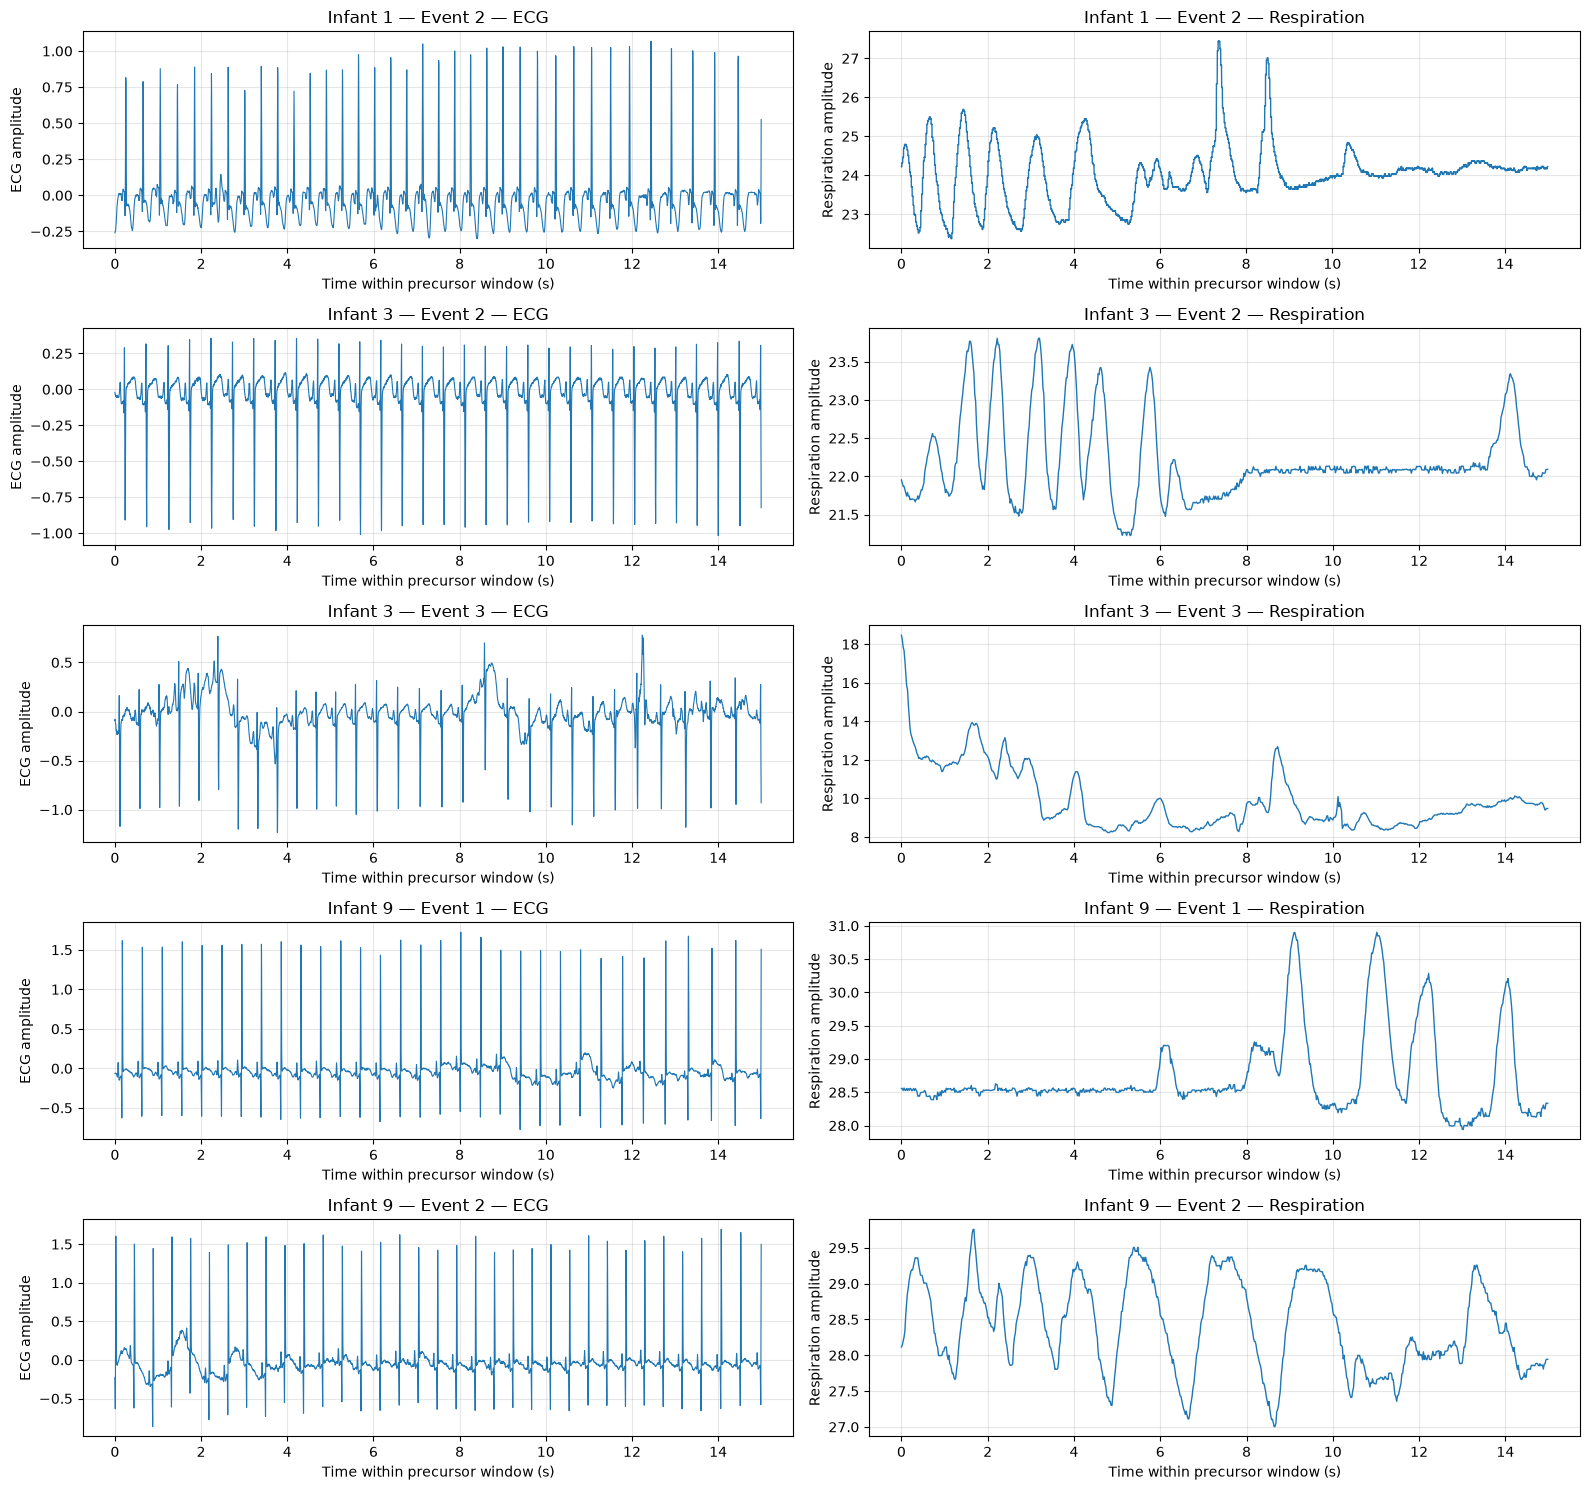


VISUAL QC CHECKLIST

Inspect each window for:
  1. ECG waveform present across the full 15 seconds
  2. Repeated QRS complexes visible
  3. No obvious flat-line ECG
  4. Respiration waveform present
  5. No obvious completely flat respiration channel
  6. No extreme numerical spikes or clipping
  7. Correct 15-second time axis

Number of positive windows displayed: 5

Notebook classification:
VALIDATION — POSITIVE WAVEFORM QUALITY CONTROL

CELL 11 COMPLETE


In [ ]:
# Cell 11 — Visual quality-control inspection of positive precursor windows

print("=" * 70)
print("POSITIVE PRECURSOR-WINDOW VISUAL QC")
print("=" * 70)

fig, axes = plt.subplots(
    nrows=len(positive_raw_windows),
    ncols=2,
    figsize=(16, 3 * len(positive_raw_windows))
)

for row, window in enumerate(positive_raw_windows):

    infant_id = window["infant"]
    event_number = window["event_number"]

    ecg_signal = window["ecg_signal"]
    resp_signal = window["resp_signal"]

    ecg_fs = window["ecg_fs"]
    resp_fs = window["resp_fs"]

    ecg_time = np.arange(len(ecg_signal)) / ecg_fs
    resp_time = np.arange(len(resp_signal)) / resp_fs

    # --------------------------------------------------------------
    # ECG
    # --------------------------------------------------------------

    axes[row, 0].plot(
        ecg_time,
        ecg_signal,
        linewidth=0.8
    )

    axes[row, 0].set_title(
        f"Infant {infant_id} — Event {event_number} — ECG"
    )

    axes[row, 0].set_xlabel("Time within precursor window (s)")
    axes[row, 0].set_ylabel("ECG amplitude")
    axes[row, 0].grid(True, alpha=0.3)

    # --------------------------------------------------------------
    # Respiration
    # --------------------------------------------------------------

    axes[row, 1].plot(
        resp_time,
        resp_signal,
        linewidth=1.0
    )

    axes[row, 1].set_title(
        f"Infant {infant_id} — Event {event_number} — Respiration"
    )

    axes[row, 1].set_xlabel("Time within precursor window (s)")
    axes[row, 1].set_ylabel("Respiration amplitude")
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("VISUAL QC CHECKLIST")
print("=" * 70)

print()
print("Inspect each window for:")
print("  1. ECG waveform present across the full 15 seconds")
print("  2. Repeated QRS complexes visible")
print("  3. No obvious flat-line ECG")
print("  4. Respiration waveform present")
print("  5. No obvious completely flat respiration channel")
print("  6. No extreme numerical spikes or clipping")
print("  7. Correct 15-second time axis")

print()
print("Number of positive windows displayed:", len(positive_raw_windows))

print()
print("Notebook classification:")
print("VALIDATION — POSITIVE WAVEFORM QUALITY CONTROL")

print()
print("=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

In [ ]:
# Cell 12 — Preprocess positive ECG and respiration windows

from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

print("=" * 70)
print("POSITIVE-WINDOW SIGNAL PREPROCESSING")
print("=" * 70)

# ------------------------------------------------------------------
# Validated preprocessing parameters
# ------------------------------------------------------------------

ECG_LOW_CUTOFF_HZ = 0.5
ECG_HIGH_CUTOFF_HZ = 40.0
ECG_FILTER_ORDER = 4

ECG_NOTCH_FREQ_HZ = 50.0
ECG_NOTCH_Q = 30.0

RESP_LOW_CUTOFF_HZ = 0.03
RESP_HIGH_CUTOFF_HZ = 2.0
RESP_FILTER_ORDER = 4

print()
print("ECG bandpass:", ECG_LOW_CUTOFF_HZ, "–", ECG_HIGH_CUTOFF_HZ, "Hz")
print("ECG filter order:", ECG_FILTER_ORDER)
print("ECG notch:", ECG_NOTCH_FREQ_HZ, "Hz, Q =", ECG_NOTCH_Q)

print()
print("Respiration bandpass:",
      RESP_LOW_CUTOFF_HZ, "–", RESP_HIGH_CUTOFF_HZ, "Hz")
print("Respiration filter order:", RESP_FILTER_ORDER)

# ------------------------------------------------------------------
# Filtering functions
# ------------------------------------------------------------------

def filter_ecg_signal(signal, fs):
    """
    Apply validated ECG preprocessing:
    1. 0.5–40 Hz Butterworth bandpass
    2. 50 Hz notch
    3. zero-phase filtering
    """

    signal = np.asarray(signal, dtype=float)

    # Bandpass using SOS for numerical stability
    sos = butter(
        ECG_FILTER_ORDER,
        [
            ECG_LOW_CUTOFF_HZ / (fs / 2.0),
            ECG_HIGH_CUTOFF_HZ / (fs / 2.0)
        ],
        btype="bandpass",
        output="sos"
    )

    filtered = sosfiltfilt(sos, signal)

    # Notch filter
    b_notch, a_notch = iirnotch(
        ECG_NOTCH_FREQ_HZ,
        ECG_NOTCH_Q,
        fs=fs
    )

    filtered = filtfilt(
        b_notch,
        a_notch,
        filtered
    )

    return filtered


def filter_respiration_signal(signal, fs):
    """
    Apply validated respiration preprocessing:
    0.03–2 Hz Butterworth bandpass using SOS
    and zero-phase filtering.
    """

    signal = np.asarray(signal, dtype=float)

    sos = butter(
        RESP_FILTER_ORDER,
        [
            RESP_LOW_CUTOFF_HZ / (fs / 2.0),
            RESP_HIGH_CUTOFF_HZ / (fs / 2.0)
        ],
        btype="bandpass",
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        signal
    )

    return filtered


# ------------------------------------------------------------------
# Process every positive precursor window
# ------------------------------------------------------------------

for window in positive_raw_windows:

    window["ecg_filtered"] = filter_ecg_signal(
        window["ecg_signal"],
        window["ecg_fs"]
    )

    window["resp_filtered"] = filter_respiration_signal(
        window["resp_signal"],
        window["resp_fs"]
    )

    # Numerical integrity checks
    if not np.isfinite(window["ecg_filtered"]).all():
        raise RuntimeError(
            f"Infant {window['infant']} Event "
            f"{window['event_number']}: filtered ECG contains NaN/Inf."
        )

    if not np.isfinite(window["resp_filtered"]).all():
        raise RuntimeError(
            f"Infant {window['infant']} Event "
            f"{window['event_number']}: filtered respiration contains NaN/Inf."
        )


print()
print("=" * 70)
print("FILTERED-SIGNAL SUMMARY")
print("=" * 70)

for window in positive_raw_windows:

    print(
        f"Infant {window['infant']:2d} | "
        f"Event {window['event_number']:2d} | "
        f"ECG range "
        f"[{np.min(window['ecg_filtered']):.4f}, "
        f"{np.max(window['ecg_filtered']):.4f}] | "
        f"RESP range "
        f"[{np.min(window['resp_filtered']):.4f}, "
        f"{np.max(window['resp_filtered']):.4f}] | "
        f"PASS"
    )

print()
print("Processed positive windows:", len(positive_raw_windows))

print()
print("PASS: All filtered ECG and respiration windows are finite.")

print()
print("Notebook classification:")
print("VALIDATION — POSITIVE SIGNAL PREPROCESSING")

print()
print("=" * 70)
print("CELL 12 COMPLETE")
print("=" * 70)

POSITIVE-WINDOW SIGNAL PREPROCESSING

ECG bandpass: 0.5 – 40.0 Hz
ECG filter order: 4
ECG notch: 50.0 Hz, Q = 30.0

Respiration bandpass: 0.03 – 2.0 Hz
Respiration filter order: 4

FILTERED-SIGNAL SUMMARY
Infant  1 | Event  2 | ECG range [-0.7416, 1.0452] | RESP range [-1.5082, 2.2594] | PASS
Infant  3 | Event  2 | ECG range [-1.2158, 1.2198] | RESP range [-0.9388, 1.5719] | PASS
Infant  3 | Event  3 | ECG range [-1.2241, 1.3160] | RESP range [-5.0167, 2.9391] | PASS
Infant  9 | Event  1 | ECG range [-2.6055, 1.7840] | RESP range [-0.8232, 2.0139] | PASS
Infant  9 | Event  2 | ECG range [-2.5760, 1.9800] | RESP range [-1.3005, 1.4127] | PASS

Processed positive windows: 5

PASS: All filtered ECG and respiration windows are finite.

Notebook classification:
VALIDATION — POSITIVE SIGNAL PREPROCESSING

CELL 12 COMPLETE


FILTERED POSITIVE-WINDOW VISUAL QC


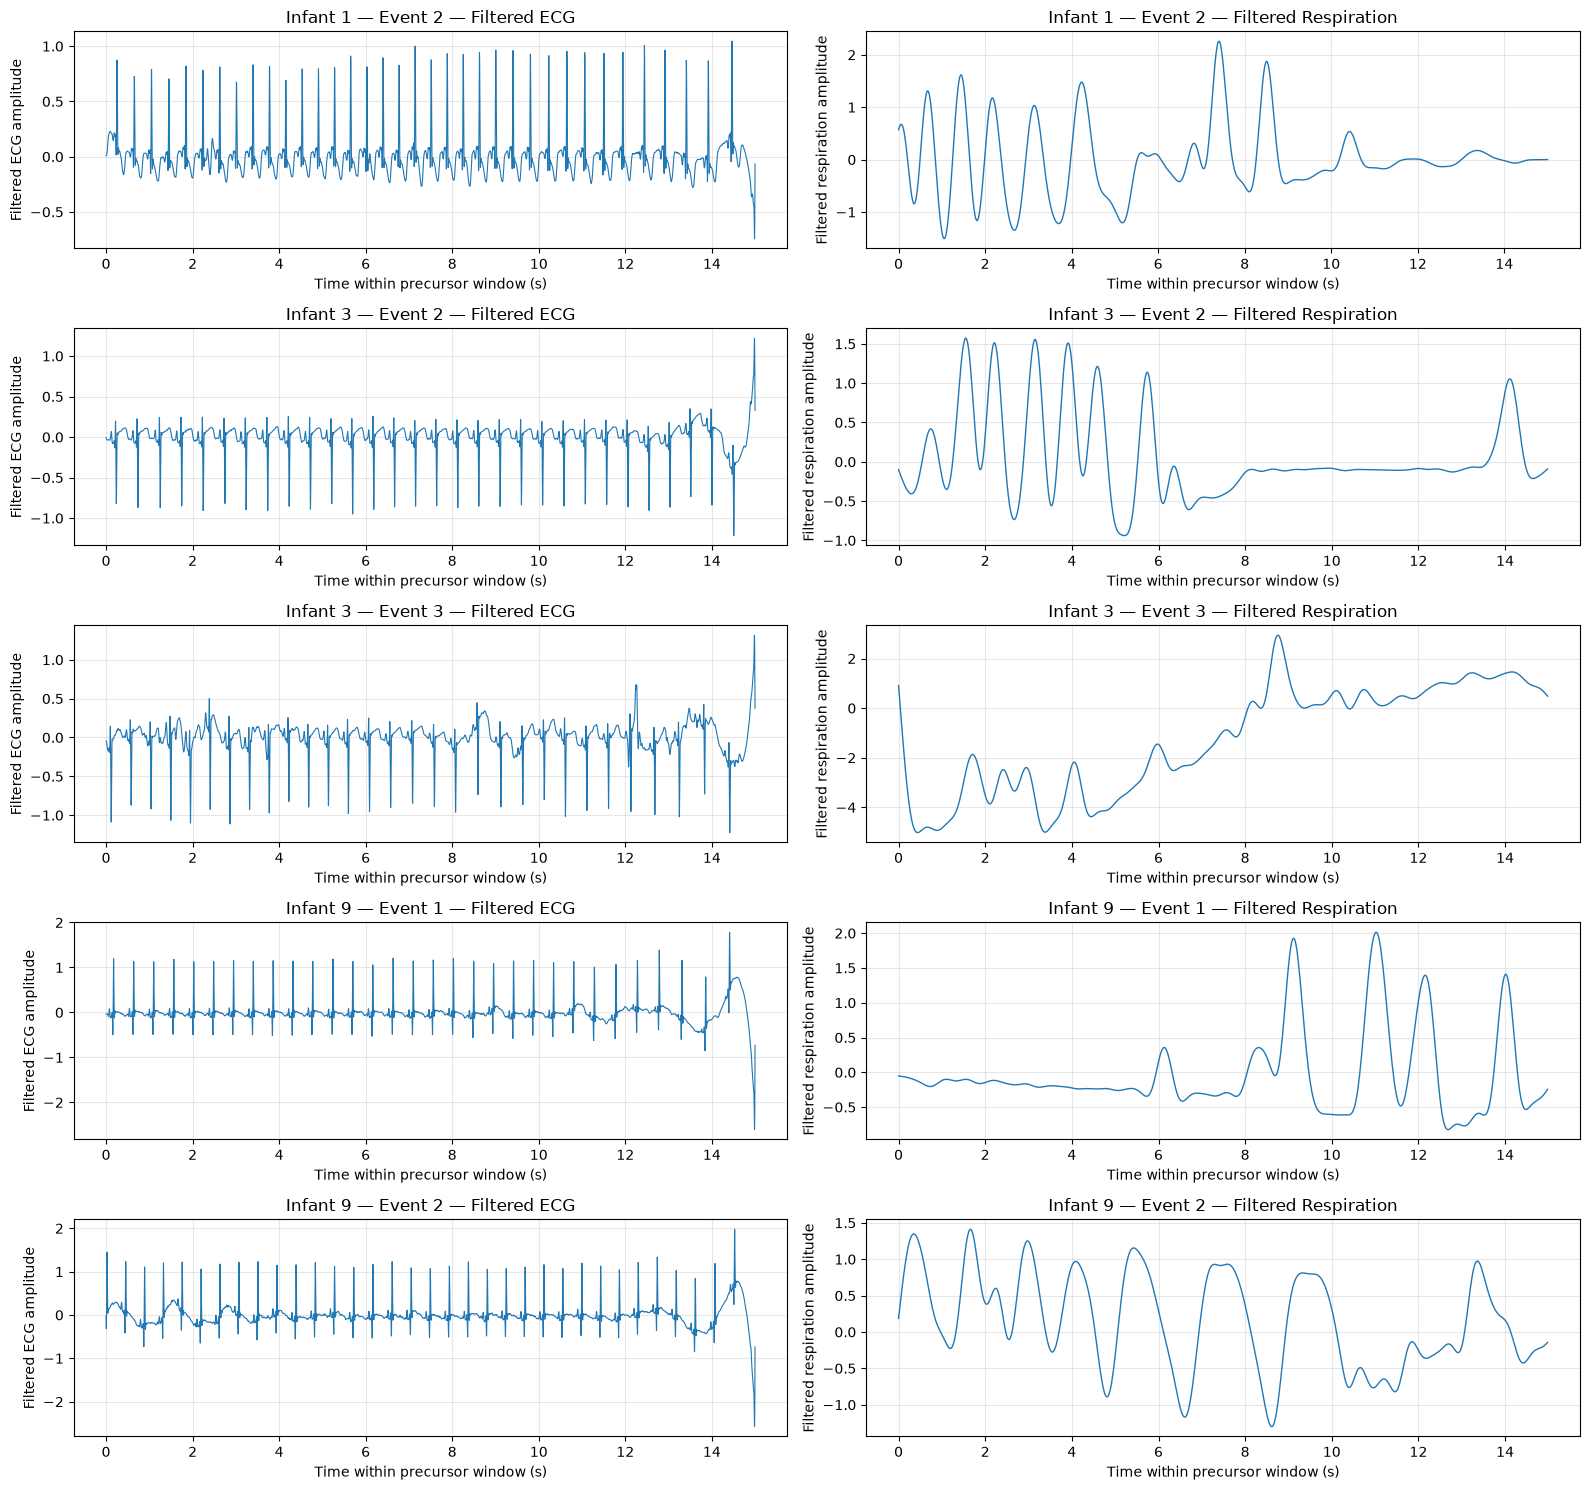


FILTERED-SIGNAL QC CHECKLIST

Check each window for:
  1. ECG QRS complexes remain visible after filtering
  2. No obvious filtering instability
  3. Respiration remains physiologically interpretable
  4. No extreme oscillatory instability
  5. Large amplitudes are inspected rather than automatically rejected
  6. Waveforms span the intended 15-second precursor interval

Windows displayed: 5

Notebook classification:
VALIDATION — FILTERED WAVEFORM QUALITY CONTROL

CELL 13 COMPLETE


In [ ]:
# Cell 13 — Visual QC of filtered positive precursor windows

print("=" * 70)
print("FILTERED POSITIVE-WINDOW VISUAL QC")
print("=" * 70)

fig, axes = plt.subplots(
    nrows=len(positive_raw_windows),
    ncols=2,
    figsize=(16, 3 * len(positive_raw_windows))
)

for row, window in enumerate(positive_raw_windows):

    infant_id = window["infant"]
    event_number = window["event_number"]

    ecg_signal = window["ecg_filtered"]
    resp_signal = window["resp_filtered"]

    ecg_fs = window["ecg_fs"]
    resp_fs = window["resp_fs"]

    ecg_time = np.arange(len(ecg_signal)) / ecg_fs
    resp_time = np.arange(len(resp_signal)) / resp_fs

    # ECG
    axes[row, 0].plot(
        ecg_time,
        ecg_signal,
        linewidth=0.8
    )

    axes[row, 0].set_title(
        f"Infant {infant_id} — Event {event_number} — Filtered ECG"
    )

    axes[row, 0].set_xlabel("Time within precursor window (s)")
    axes[row, 0].set_ylabel("Filtered ECG amplitude")
    axes[row, 0].grid(True, alpha=0.3)

    # Respiration
    axes[row, 1].plot(
        resp_time,
        resp_signal,
        linewidth=1.0
    )

    axes[row, 1].set_title(
        f"Infant {infant_id} — Event {event_number} — Filtered Respiration"
    )

    axes[row, 1].set_xlabel("Time within precursor window (s)")
    axes[row, 1].set_ylabel("Filtered respiration amplitude")
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("FILTERED-SIGNAL QC CHECKLIST")
print("=" * 70)

print()
print("Check each window for:")
print("  1. ECG QRS complexes remain visible after filtering")
print("  2. No obvious filtering instability")
print("  3. Respiration remains physiologically interpretable")
print("  4. No extreme oscillatory instability")
print("  5. Large amplitudes are inspected rather than automatically rejected")
print("  6. Waveforms span the intended 15-second precursor interval")

print()
print("Windows displayed:", len(positive_raw_windows))

print()
print("Notebook classification:")
print("VALIDATION — FILTERED WAVEFORM QUALITY CONTROL")

print()
print("=" * 70)
print("CELL 13 COMPLETE")
print("=" * 70)

In [ ]:
# Cell 14 — Reprocess positive windows using extended signal context
#
# IMPORTANT:
# Cell 12 filtered isolated 15-second windows. Visual QC showed
# possible edge effects in the respiration signal.
#
# We therefore filter a larger context around each precursor window
# and crop the exact 15-second window AFTER filtering.

print("=" * 70)
print("EXTENDED-CONTEXT SIGNAL PREPROCESSING")
print("=" * 70)

FILTER_CONTEXT_SECONDS = 60.0

print()
print("Precursor window:", PRECURSOR_WINDOW_SECONDS, "s")
print("Filtering context on each side:", FILTER_CONTEXT_SECONDS, "s")
print("Total context around each window:",
      PRECURSOR_WINDOW_SECONDS + 2 * FILTER_CONTEXT_SECONDS,
      "s")

# Store corrected signals separately.
# We will not overwrite the original raw signals.
corrected_positive_windows = []

for _, event in positive_event_inventory.iterrows():

    infant_id = int(event["infant"])
    event_number = int(event["event_number"])

    precursor_start_s = float(event["precursor_start_s"])
    precursor_end_s = float(event["precursor_end_s"])
    record_duration_s = float(event["record_duration_s"])

    # --------------------------------------------------------------
    # Extended context
    # --------------------------------------------------------------

    context_start_s = max(
        0.0,
        precursor_start_s - FILTER_CONTEXT_SECONDS
    )

    context_end_s = min(
        record_duration_s,
        precursor_end_s + FILTER_CONTEXT_SECONDS
    )

    if (
        context_start_s > precursor_start_s
        or context_end_s < precursor_end_s
    ):
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            "insufficient context around precursor window."
        )

    # --------------------------------------------------------------
    # ECG extended extraction
    # --------------------------------------------------------------

    ecg_record_name = f"infant{infant_id}_ecg"
    ecg_fs = float(event["ecg_fs"])

    ecg_context_start_sample = int(
        round(context_start_s * ecg_fs)
    )

    ecg_context_end_sample = int(
        round(context_end_s * ecg_fs)
    )

    ecg_context_record = wfdb.rdrecord(
        ecg_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=ecg_context_start_sample,
        sampto=ecg_context_end_sample
    )

    ecg_context = ecg_context_record.p_signal[:, 0]

    # --------------------------------------------------------------
    # Respiration extended extraction
    # --------------------------------------------------------------

    resp_record_name = f"infant{infant_id}_resp"
    resp_fs = float(event["resp_fs"])

    resp_context_start_sample = int(
        round(context_start_s * resp_fs)
    )

    resp_context_end_sample = int(
        round(context_end_s * resp_fs)
    )

    resp_context_record = wfdb.rdrecord(
        resp_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=resp_context_start_sample,
        sampto=resp_context_end_sample
    )

    resp_context = resp_context_record.p_signal[:, 0]

    # --------------------------------------------------------------
    # Filter extended signals
    # --------------------------------------------------------------

    ecg_context_filtered = filter_ecg_signal(
        ecg_context,
        ecg_fs
    )

    resp_context_filtered = filter_respiration_signal(
        resp_context,
        resp_fs
    )

    # --------------------------------------------------------------
    # Crop exact precursor window AFTER filtering
    # --------------------------------------------------------------

    ecg_crop_start = int(
        round(
            (precursor_start_s - context_start_s)
            * ecg_fs
        )
    )

    ecg_crop_end = ecg_crop_start + int(
        round(
            PRECURSOR_WINDOW_SECONDS * ecg_fs
        )
    )

    resp_crop_start = int(
        round(
            (precursor_start_s - context_start_s)
            * resp_fs
        )
    )

    resp_crop_end = resp_crop_start + int(
        round(
            PRECURSOR_WINDOW_SECONDS * resp_fs
        )
    )

    ecg_filtered_cropped = ecg_context_filtered[
        ecg_crop_start:ecg_crop_end
    ]

    resp_filtered_cropped = resp_context_filtered[
        resp_crop_start:resp_crop_end
    ]

    # --------------------------------------------------------------
    # Validate cropped signals
    # --------------------------------------------------------------

    expected_ecg_samples = int(
        round(PRECURSOR_WINDOW_SECONDS * ecg_fs)
    )

    expected_resp_samples = int(
        round(PRECURSOR_WINDOW_SECONDS * resp_fs)
    )

    if len(ecg_filtered_cropped) != expected_ecg_samples:
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"incorrect cropped ECG length "
            f"{len(ecg_filtered_cropped)}."
        )

    if len(resp_filtered_cropped) != expected_resp_samples:
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            f"incorrect cropped respiration length "
            f"{len(resp_filtered_cropped)}."
        )

    if not np.isfinite(ecg_filtered_cropped).all():
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            "cropped ECG contains NaN/Inf."
        )

    if not np.isfinite(resp_filtered_cropped).all():
        raise RuntimeError(
            f"Infant {infant_id} Event {event_number}: "
            "cropped respiration contains NaN/Inf."
        )

    corrected_positive_windows.append({
        "infant": infant_id,
        "event_number": event_number,
        "event_time_s": float(event["event_time_s"]),
        "precursor_start_s": precursor_start_s,
        "precursor_end_s": precursor_end_s,
        "ecg_fs": ecg_fs,
        "resp_fs": resp_fs,
        "ecg_filtered": ecg_filtered_cropped,
        "resp_filtered": resp_filtered_cropped,
        "context_start_s": context_start_s,
        "context_end_s": context_end_s
    })

    print(
        f"Infant {infant_id:2d} | "
        f"Event {event_number:2d} | "
        f"Context {context_start_s:.3f}–"
        f"{context_end_s:.3f} s | "
        f"ECG {len(ecg_filtered_cropped):5d} | "
        f"RESP {len(resp_filtered_cropped):5d} | "
        f"PASS"
    )

print()
print("=" * 70)
print("CORRECTED PREPROCESSING SUMMARY")
print("=" * 70)

print()
print(
    "Corrected windows:",
    len(corrected_positive_windows)
)

print(
    "Expected windows:",
    len(positive_event_inventory)
)

if len(corrected_positive_windows) != len(
    positive_event_inventory
):
    raise RuntimeError(
        "Corrected window count does not match "
        "positive event count."
    )

print()
print("PASS: All positive windows were filtered using extended context.")
print("PASS: Exact 15-second windows were cropped after filtering.")
print("PASS: All corrected signals are finite.")

print()
print("Notebook classification:")
print("VALIDATION — EDGE-EFFECT-CORRECTED PREPROCESSING")

print()
print("=" * 70)
print("CELL 14 COMPLETE")
print("=" * 70)

EXTENDED-CONTEXT SIGNAL PREPROCESSING

Precursor window: 15.0 s
Filtering context on each side: 60.0 s
Total context around each window: 135.0 s


ReadTimeout: HTTPSConnectionPool(host='physionet.org', port=443): Read timed out. (read timeout=None)

CORRECTED PRECURSOR-WINDOW VISUAL QC


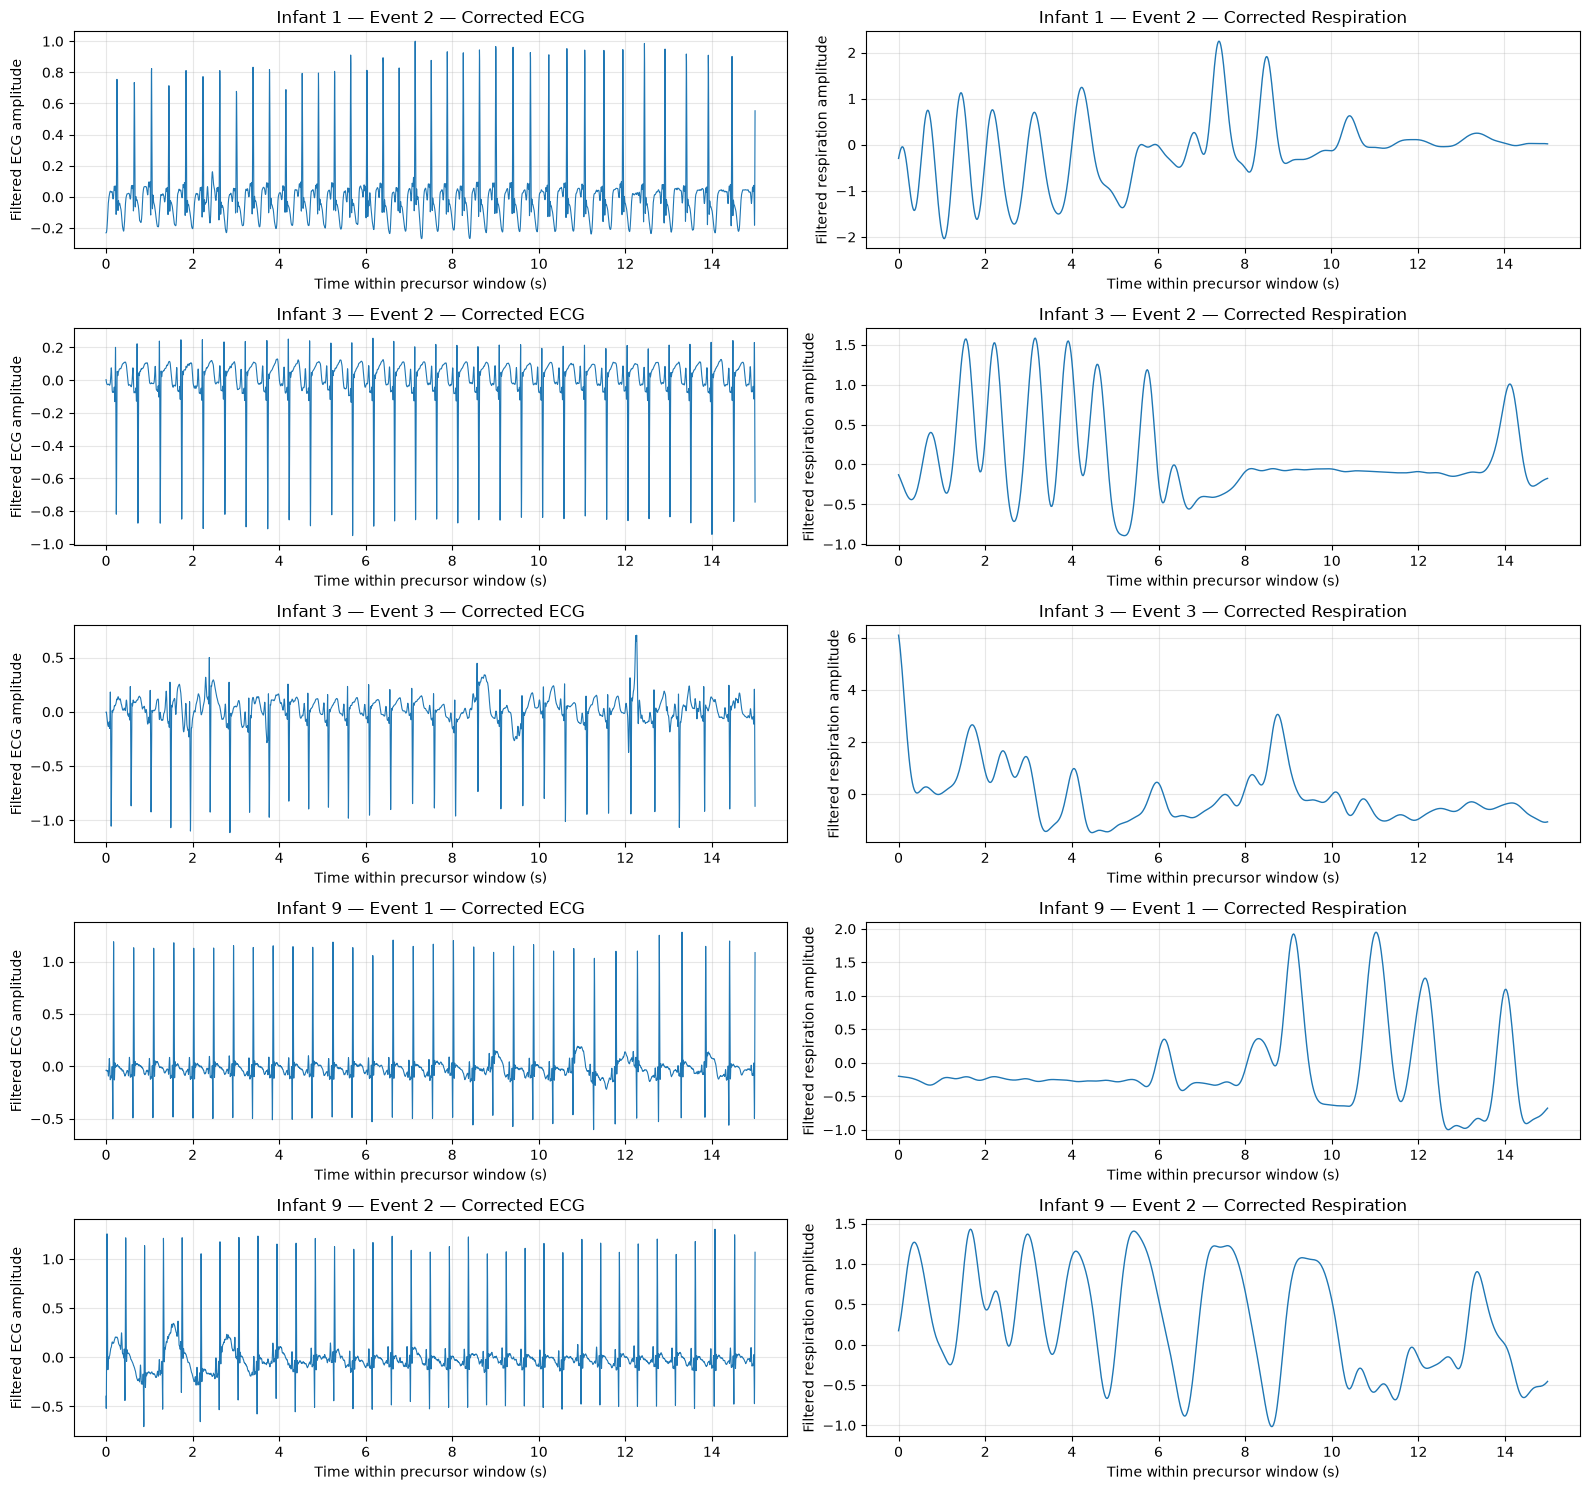


CORRECTED SIGNAL QC CHECKLIST

Confirm:
  1. ECG QRS complexes remain visible.
  2. Respiration has a physiologically interpretable waveform.
  3. No obvious filter instability at the beginning/end.
  4. Infant 3 Event 3 no longer shows the previous extreme
     artificial-looking baseline excursion.
  5. All signals cover the complete 15-second window.

Windows displayed: 5

Notebook classification:
VALIDATION — CORRECTED FILTERED-WAVEFORM QC

CELL 15 COMPLETE


In [ ]:
# Cell 15 — Visual QC of edge-effect-corrected signals

print("=" * 70)
print("CORRECTED PRECURSOR-WINDOW VISUAL QC")
print("=" * 70)

fig, axes = plt.subplots(
    nrows=len(corrected_positive_windows),
    ncols=2,
    figsize=(16, 3 * len(corrected_positive_windows))
)

for row, window in enumerate(corrected_positive_windows):

    infant_id = window["infant"]
    event_number = window["event_number"]

    ecg_signal = window["ecg_filtered"]
    resp_signal = window["resp_filtered"]

    ecg_fs = window["ecg_fs"]
    resp_fs = window["resp_fs"]

    ecg_time = np.arange(len(ecg_signal)) / ecg_fs
    resp_time = np.arange(len(resp_signal)) / resp_fs

    # ECG
    axes[row, 0].plot(
        ecg_time,
        ecg_signal,
        linewidth=0.8
    )

    axes[row, 0].set_title(
        f"Infant {infant_id} — Event {event_number} — Corrected ECG"
    )

    axes[row, 0].set_xlabel("Time within precursor window (s)")
    axes[row, 0].set_ylabel("Filtered ECG amplitude")
    axes[row, 0].grid(True, alpha=0.3)

    # Respiration
    axes[row, 1].plot(
        resp_time,
        resp_signal,
        linewidth=1.0
    )

    axes[row, 1].set_title(
        f"Infant {infant_id} — Event {event_number} — Corrected Respiration"
    )

    axes[row, 1].set_xlabel("Time within precursor window (s)")
    axes[row, 1].set_ylabel("Filtered respiration amplitude")
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("CORRECTED SIGNAL QC CHECKLIST")
print("=" * 70)

print()
print("Confirm:")
print("  1. ECG QRS complexes remain visible.")
print("  2. Respiration has a physiologically interpretable waveform.")
print("  3. No obvious filter instability at the beginning/end.")
print("  4. Infant 3 Event 3 no longer shows the previous extreme")
print("     artificial-looking baseline excursion.")
print("  5. All signals cover the complete 15-second window.")

print()
print("Windows displayed:", len(corrected_positive_windows))

print()
print("Notebook classification:")
print("VALIDATION — CORRECTED FILTERED-WAVEFORM QC")

print()
print("=" * 70)
print("CELL 15 COMPLETE")
print("=" * 70)

In [ ]:
# Cell 16 — Extract physiological features from corrected precursor windows

from scipy.signal import find_peaks

print("=" * 70)
print("PHYSIOLOGICAL FEATURE EXTRACTION")
print("=" * 70)

# ------------------------------------------------------------------
# Feature-extraction parameters
# ------------------------------------------------------------------

ECG_MIN_RR_SECONDS = 0.30

# Respiration peaks should represent individual respiratory cycles.
# A minimum separation of 0.8 s corresponds to a maximum rate of
# 75 breaths/min, which is deliberately permissive for neonatal data.
RESP_MIN_PEAK_DISTANCE_SECONDS = 0.80

# Adaptive prominence avoids using an absolute amplitude threshold
# across infants with different signal scales.
RESP_PEAK_PROMINENCE_FACTOR = 0.10

print()
print("ECG minimum R-R separation:",
      ECG_MIN_RR_SECONDS, "s")

print(
    "Respiration minimum peak separation:",
    RESP_MIN_PEAK_DISTANCE_SECONDS,
    "s"
)

print(
    "Respiration prominence factor:",
    RESP_PEAK_PROMINENCE_FACTOR
)

# ------------------------------------------------------------------
# Feature extraction
# ------------------------------------------------------------------

def extract_precursor_features(window):

    ecg = np.asarray(
        window["ecg_filtered"],
        dtype=float
    )

    resp = np.asarray(
        window["resp_filtered"],
        dtype=float
    )

    ecg_fs = float(window["ecg_fs"])
    resp_fs = float(window["resp_fs"])

    # --------------------------------------------------------------
    # ECG basic statistics
    # --------------------------------------------------------------

    ecg_mean = float(np.mean(ecg))
    ecg_std = float(np.std(ecg))
    ecg_rms = float(
        np.sqrt(np.mean(ecg ** 2))
    )

    # --------------------------------------------------------------
    # ECG R-peak detection
    # --------------------------------------------------------------

    ecg_peaks, _ = find_peaks(
        ecg,
        distance=int(
            ECG_MIN_RR_SECONDS * ecg_fs
        ),
        prominence=0.3
    )

    r_peak_count = int(len(ecg_peaks))

    # --------------------------------------------------------------
    # ECG RR / HR features
    # --------------------------------------------------------------

    if r_peak_count >= 2:

        r_peak_times = ecg_peaks / ecg_fs

        rr_intervals = np.diff(
            r_peak_times
        )

        # Reject physiologically impossible intervals
        valid_rr = rr_intervals[
            (rr_intervals >= 0.30)
            &
            (rr_intervals <= 2.0)
        ]

        if len(valid_rr) > 0:

            heart_rate = 60.0 / valid_rr

            mean_rr = float(
                np.mean(valid_rr)
            )

            std_rr = float(
                np.std(valid_rr)
            )

            mean_hr = float(
                np.mean(heart_rate)
            )

            min_hr = float(
                np.min(heart_rate)
            )

            max_hr = float(
                np.max(heart_rate)
            )

            std_hr = float(
                np.std(heart_rate)
            )

            # SDNN
            if len(valid_rr) >= 2:
                sdnn = float(
                    np.std(
                        valid_rr,
                        ddof=1
                    ) * 1000.0
                )
            else:
                sdnn = 0.0

            # RMSSD
            if len(valid_rr) >= 2:
                successive_differences = np.diff(
                    valid_rr
                )

                rmssd = float(
                    np.sqrt(
                        np.mean(
                            successive_differences ** 2
                        )
                    )
                    * 1000.0
                )
            else:
                rmssd = 0.0

        else:
            mean_rr = np.nan
            std_rr = np.nan
            mean_hr = np.nan
            min_hr = np.nan
            max_hr = np.nan
            std_hr = np.nan
            sdnn = np.nan
            rmssd = np.nan

    else:

        mean_rr = np.nan
        std_rr = np.nan
        mean_hr = np.nan
        min_hr = np.nan
        max_hr = np.nan
        std_hr = np.nan
        sdnn = np.nan
        rmssd = np.nan

    # --------------------------------------------------------------
    # Respiration basic statistics
    # --------------------------------------------------------------

    resp_mean = float(
        np.mean(resp)
    )

    resp_std = float(
        np.std(resp)
    )

    resp_rms = float(
        np.sqrt(np.mean(resp ** 2))
    )

    # --------------------------------------------------------------
    # Respiration peak detection
    # --------------------------------------------------------------

    resp_peak_distance = int(
        RESP_MIN_PEAK_DISTANCE_SECONDS
        * resp_fs
    )

    resp_prominence = (
        RESP_PEAK_PROMINENCE_FACTOR
        * resp_std
    )

    if resp_prominence <= 0:
        resp_peaks = np.array([], dtype=int)

    else:
        resp_peaks, _ = find_peaks(
            resp,
            distance=resp_peak_distance,
            prominence=resp_prominence
        )

    resp_peak_count = int(
        len(resp_peaks)
    )

    # --------------------------------------------------------------
    # Respiration interval / rate features
    # --------------------------------------------------------------

    if resp_peak_count >= 2:

        resp_peak_times = (
            resp_peaks / resp_fs
        )

        resp_intervals = np.diff(
            resp_peak_times
        )

        # Keep physiologically plausible respiratory intervals.
        valid_resp_intervals = resp_intervals[
            (resp_intervals >= 0.80)
            &
            (resp_intervals <= 10.0)
        ]

        if len(valid_resp_intervals) > 0:

            resp_rates = (
                60.0
                / valid_resp_intervals
            )

            mean_resp_interval = float(
                np.mean(valid_resp_intervals)
            )

            std_resp_interval = float(
                np.std(valid_resp_intervals)
            )

            mean_resp_rate = float(
                np.mean(resp_rates)
            )

            std_resp_rate = float(
                np.std(resp_rates)
            )

        else:

            mean_resp_interval = np.nan
            std_resp_interval = np.nan
            mean_resp_rate = np.nan
            std_resp_rate = np.nan

    else:

        mean_resp_interval = np.nan
        std_resp_interval = np.nan
        mean_resp_rate = np.nan
        std_resp_rate = np.nan

    # --------------------------------------------------------------
    # Return feature dictionary
    # --------------------------------------------------------------

    return {
        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,
        "r_peak_count": r_peak_count,
        "mean_rr": mean_rr,
        "std_rr": std_rr,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd,
        "resp_mean": resp_mean,
        "resp_std": resp_std,
        "resp_rms": resp_rms,
        "resp_peak_count": resp_peak_count,
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval,
        "mean_resp_rate": mean_resp_rate,
        "std_resp_rate": std_resp_rate
    }


# ------------------------------------------------------------------
# Extract features for every positive precursor window
# ------------------------------------------------------------------

positive_feature_rows = []

for window in corrected_positive_windows:

    features = extract_precursor_features(
        window
    )

    row = {
        "infant": window["infant"],
        "event_number": window["event_number"],
        "event_time_s": window["event_time_s"],
        "precursor_start_s": window["precursor_start_s"],
        "precursor_end_s": window["precursor_end_s"],
        "risk_label": RISK_LABEL["respiratory_risk"],
        "window_type": "precursor"
    }

    row.update(features)

    positive_feature_rows.append(row)


positive_features = pd.DataFrame(
    positive_feature_rows
)

print()
print("=" * 70)
print("POSITIVE FEATURE DATASET")
print("=" * 70)

print()
print(
    "Shape:",
    positive_features.shape
)

print()
print("Features extracted:")
print(
    positive_features.columns.tolist()
)

print()
print("Feature values:")
display(
    positive_features
)

print()
print("=" * 70)
print("FEATURE VALIDITY CHECK")
print("=" * 70)

feature_columns = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

print()
print("Number of physiological features:",
      len(feature_columns))

print(
    "NaN values across physiological features:",
    int(
        positive_features[feature_columns]
        .isna()
        .sum()
        .sum()
    )
)

print(
    "Infinite values across physiological features:",
    int(
        np.isinf(
            positive_features[feature_columns]
            .to_numpy(dtype=float)
        ).sum()
    )
)

if not np.isinf(
    positive_features[feature_columns]
    .to_numpy(dtype=float)
).any():
    print("PASS: No infinite feature values.")

print()
print("Notebook classification:")
print("VALIDATION — POSITIVE PHYSIOLOGICAL FEATURES")

print()
print("=" * 70)
print("CELL 16 COMPLETE")
print("=" * 70)

PHYSIOLOGICAL FEATURE EXTRACTION

ECG minimum R-R separation: 0.3 s
Respiration minimum peak separation: 0.8 s
Respiration prominence factor: 0.1

POSITIVE FEATURE DATASET

Shape: (5, 27)

Features extracted:
['infant', 'event_number', 'event_time_s', 'precursor_start_s', 'precursor_end_s', 'risk_label', 'window_type', 'ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd', 'resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

Feature values:


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,risk_label,window_type,ecg_mean,ecg_std,ecg_rms,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,1,2,3456.512,3441.512,3456.512,1,precursor,-0.000091,0.182047,0.182047,...,46.042144,16.789352,-0.118476,0.720022,0.729704,10,1.475111,0.256474,41.990929,7.692174
1,3,2,8143.846,8128.846,8143.846,1,precursor,-0.000518,0.156619,0.156620,...,7.181073,6.928203,0.063254,0.532280,0.536025,7,2.226667,1.738186,39.952584,19.874797
2,3,3,9427.300,9412.300,9427.300,1,precursor,-0.000696,0.188482,0.188483,...,114.011796,187.800426,-0.084008,1.076868,1.080140,11,1.352000,0.287917,46.381103,9.615755
3,9,1,6900.050,6885.050,6900.050,1,precursor,-0.000861,0.198022,0.198024,...,26.113457,9.005745,-0.126642,0.599745,0.612970,7,2.204000,0.933501,31.843991,12.059138
4,9,2,10072.600,10057.600,10072.600,1,precursor,0.002017,0.218144,0.218154,...,5.362609,4.046604,0.275171,0.664199,0.718943,10,1.444444,0.300041,43.063705,7.486581



FEATURE VALIDITY CHECK

Number of physiological features: 20
NaN values across physiological features: 0
Infinite values across physiological features: 0
PASS: No infinite feature values.

Notebook classification:
VALIDATION — POSITIVE PHYSIOLOGICAL FEATURES

CELL 16 COMPLETE


In [ ]:
# Cell 17 — Save and numerically verify positive precursor features

print("=" * 70)
print("POSITIVE PRECURSOR FEATURE CHECKPOINT")
print("=" * 70)

POSITIVE_FEATURES_PATH = (
    REPORTS_DIR / "pics_final_positive_precursor_features.csv"
)

# ------------------------------------------------------------------
# Save the positive feature dataset
# ------------------------------------------------------------------

positive_features.to_csv(
    POSITIVE_FEATURES_PATH,
    index=False
)

print()
print("Saved:")
print(POSITIVE_FEATURES_PATH)

print()
print("Dataset shape:")
print(positive_features.shape)

print()
print("Risk-label distribution:")
print(
    positive_features["risk_label"]
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print("Window-type distribution:")
print(
    positive_features["window_type"]
    .value_counts()
    .to_string()
)

print()
print("Positive events by infant:")
print(
    positive_features
    .groupby("infant")
    .size()
    .to_string()
)

# ------------------------------------------------------------------
# Feature range sanity check
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FEATURE RANGE SANITY CHECK")
print("=" * 70)

sanity_summary = positive_features[
    feature_columns
].agg(
    ["min", "max", "mean"]
).T

display(sanity_summary)

# ------------------------------------------------------------------
# Reload verification
#
# CSV floating-point values may have tiny representation differences
# after writing and reading. Therefore:
#   - metadata/integer columns are checked exactly
#   - numerical feature columns are checked with np.allclose()
# ------------------------------------------------------------------

print()
print("=" * 70)
print("RELOAD VERIFICATION")
print("=" * 70)

positive_features_reload = pd.read_csv(
    POSITIVE_FEATURES_PATH
)

# Check shape
if positive_features_reload.shape != positive_features.shape:
    raise RuntimeError(
        "Reloaded dataset shape does not match "
        "the in-memory dataset."
    )

# Check column names and order
if list(positive_features_reload.columns) != list(
    positive_features.columns
):
    raise RuntimeError(
        "Reloaded column names/order do not match "
        "the in-memory dataset."
    )

# Exact checks for non-floating metadata
metadata_columns = [
    "infant",
    "event_number",
    "risk_label",
    "window_type"
]

for column in metadata_columns:

    if not positive_features_reload[column].equals(
        positive_features[column]
    ):
        raise RuntimeError(
            f"Metadata column does not match after reload: "
            f"{column}"
        )

# Numerical checks for event/window metadata
numerical_metadata_columns = [
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s"
]

for column in numerical_metadata_columns:

    original = positive_features[column].to_numpy(
        dtype=float
    )

    reloaded = positive_features_reload[column].to_numpy(
        dtype=float
    )

    if not np.allclose(
        original,
        reloaded,
        rtol=1e-10,
        atol=1e-12
    ):
        raise RuntimeError(
            f"Numerical metadata does not match after reload: "
            f"{column}"
        )

# Numerical physiological features
for column in feature_columns:

    original = positive_features[column].to_numpy(
        dtype=float
    )

    reloaded = positive_features_reload[column].to_numpy(
        dtype=float
    )

    if not np.allclose(
        original,
        reloaded,
        rtol=1e-10,
        atol=1e-12
    ):
        raise RuntimeError(
            f"Physiological feature does not match after reload: "
            f"{column}"
        )

print()
print("Reloaded shape:")
print(positive_features_reload.shape)

print()
print("PASS: Dataset shape matches.")
print("PASS: Column names and order match.")
print("PASS: Metadata values match.")
print("PASS: Numerical feature values match within tolerance.")
print("PASS: Positive feature checkpoint is valid.")

print()
print("Notebook classification:")
print("VALIDATION — POSITIVE FEATURE CHECKPOINT")

print()
print("=" * 70)
print("CELL 17 COMPLETE")
print("=" * 70)

POSITIVE PRECURSOR FEATURE CHECKPOINT

Saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_positive_precursor_features.csv

Dataset shape:
(5, 27)

Risk-label distribution:
risk_label
1    5

Window-type distribution:
window_type
precursor    5

Positive events by infant:
infant
1    1
3    2
9    2

FEATURE RANGE SANITY CHECK


,min,max,mean
ecg_mean,-0.000861,0.002017,-0.000030
ecg_std,0.156619,0.218144,0.188663
ecg_rms,0.156620,0.218154,0.188665
r_peak_count,30.000000,36.000000,32.400000
mean_rr,0.406057,0.513241,0.465096
std_rr,0.005281,0.112029,0.039085
mean_hr,121.176614,149.359099,131.157686
min_hr,65.934066,131.578947,106.485847
max_hr,125.000000,179.640719,147.630407
std_hr,1.615860,20.679015,8.922061



RELOAD VERIFICATION

Reloaded shape:
(5, 27)

PASS: Dataset shape matches.
PASS: Column names and order match.
PASS: Metadata values match.
PASS: Numerical feature values match within tolerance.
PASS: Positive feature checkpoint is valid.

Notebook classification:
VALIDATION — POSITIVE FEATURE CHECKPOINT

CELL 17 COMPLETE


In [ ]:
# Cell 18 — Build exclusion intervals for control-window selection

print("=" * 70)
print("CONTROL-WINDOW EXCLUSION INTERVALS")
print("=" * 70)

# ------------------------------------------------------------------
# Control exclusion policy
#
# A control window must not overlap the 15-second precursor window
# of a positive event and must be at least 60 seconds away from the
# positive event onset.
#
# Therefore, for each positive event:
#
# forbidden interval =
#     [event_time - 15 s - 60 s,
#      event_time + 60 s]
#
# This gives a conservative exclusion region around each positive
# event.
# ------------------------------------------------------------------

CONTROL_EXCLUSION_BEFORE_SECONDS = (
    PRECURSOR_WINDOW_SECONDS
    + CONTROL_MIN_DISTANCE_SECONDS
)

CONTROL_EXCLUSION_AFTER_SECONDS = (
    CONTROL_MIN_DISTANCE_SECONDS
)

print()
print(
    "Exclusion before event onset:",
    CONTROL_EXCLUSION_BEFORE_SECONDS,
    "s"
)

print(
    "Exclusion after event onset:",
    CONTROL_EXCLUSION_AFTER_SECONDS,
    "s"
)

# ------------------------------------------------------------------
# Construct exclusion intervals
# ------------------------------------------------------------------

control_exclusion_intervals = []

for _, event in positive_event_inventory.iterrows():

    infant_id = int(event["infant"])
    event_number = int(event["event_number"])
    event_time_s = float(event["event_time_s"])
    record_duration_s = float(event["record_duration_s"])

    exclusion_start_s = max(
        0.0,
        event_time_s
        - CONTROL_EXCLUSION_BEFORE_SECONDS
    )

    exclusion_end_s = min(
        record_duration_s,
        event_time_s
        + CONTROL_EXCLUSION_AFTER_SECONDS
    )

    control_exclusion_intervals.append({
        "infant": infant_id,
        "event_number": event_number,
        "event_time_s": event_time_s,
        "exclusion_start_s": exclusion_start_s,
        "exclusion_end_s": exclusion_end_s,
        "exclusion_duration_s": (
            exclusion_end_s
            - exclusion_start_s
        )
    })

control_exclusion_intervals = pd.DataFrame(
    control_exclusion_intervals
)

# ------------------------------------------------------------------
# Display
# ------------------------------------------------------------------

print()
print("Control exclusion intervals:")

display(
    control_exclusion_intervals
)

print()
print("=" * 70)
print("EXCLUSION SUMMARY BY INFANT")
print("=" * 70)

display(
    control_exclusion_intervals[
        [
            "infant",
            "event_number",
            "event_time_s",
            "exclusion_start_s",
            "exclusion_end_s",
            "exclusion_duration_s"
        ]
    ]
)

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

expected_interval_count = len(
    positive_event_inventory
)

if len(control_exclusion_intervals) != expected_interval_count:
    raise RuntimeError(
        "Number of exclusion intervals does not match "
        "number of positive events."
    )

if (
    control_exclusion_intervals["exclusion_duration_s"]
    <= 0
).any():
    raise RuntimeError(
        "An exclusion interval has non-positive duration."
    )

print()
print(
    "Positive events:",
    expected_interval_count
)

print(
    "Exclusion intervals:",
    len(control_exclusion_intervals)
)

print(
    "PASS: One valid exclusion interval exists for "
    "every positive event."
)

print()
print("Notebook classification:")
print("VALIDATION — CONTROL EXCLUSION DEFINITION")

print()
print("=" * 70)
print("CELL 18 COMPLETE")
print("=" * 70)

CONTROL-WINDOW EXCLUSION INTERVALS

Exclusion before event onset: 75.0 s
Exclusion after event onset: 60.0 s

Control exclusion intervals:


,infant,event_number,event_time_s,exclusion_start_s,exclusion_end_s,exclusion_duration_s
0,1,2,3456.512,3381.512,3516.512,135.0
1,3,2,8143.846,8068.846,8203.846,135.0
2,3,3,9427.300,9352.300,9487.300,135.0
3,9,1,6900.050,6825.050,6960.050,135.0
4,9,2,10072.600,9997.600,10132.600,135.0



EXCLUSION SUMMARY BY INFANT


,infant,event_number,event_time_s,exclusion_start_s,exclusion_end_s,exclusion_duration_s
0,1,2,3456.512,3381.512,3516.512,135.0
1,3,2,8143.846,8068.846,8203.846,135.0
2,3,3,9427.300,9352.300,9487.300,135.0
3,9,1,6900.050,6825.050,6960.050,135.0
4,9,2,10072.600,9997.600,10132.600,135.0



POLICY CHECK

Positive events: 5
Exclusion intervals: 5
PASS: One valid exclusion interval exists for every positive event.

Notebook classification:
VALIDATION — CONTROL EXCLUSION DEFINITION

CELL 18 COMPLETE


In [ ]:
# Cell 19 — Save and verify control exclusion intervals

print("=" * 70)
print("CONTROL EXCLUSION CHECKPOINT")
print("=" * 70)

CONTROL_EXCLUSION_PATH = (
    REPORTS_DIR / "pics_final_control_exclusion_intervals.csv"
)

# Save
control_exclusion_intervals.to_csv(
    CONTROL_EXCLUSION_PATH,
    index=False
)

print()
print("Saved:")
print(CONTROL_EXCLUSION_PATH)

print()
print("Number of exclusion intervals:",
      len(control_exclusion_intervals))

print()
print("Exclusion intervals by infant:")

display(
    control_exclusion_intervals[
        [
            "infant",
            "event_number",
            "event_time_s",
            "exclusion_start_s",
            "exclusion_end_s",
            "exclusion_duration_s"
        ]
    ]
)

# ------------------------------------------------------------------
# Reload verification
# ------------------------------------------------------------------

control_exclusion_reload = pd.read_csv(
    CONTROL_EXCLUSION_PATH
)

if control_exclusion_reload.shape != (
    control_exclusion_intervals.shape
):
    raise RuntimeError(
        "Reloaded exclusion dataset shape does not match."
    )

if list(control_exclusion_reload.columns) != list(
    control_exclusion_intervals.columns
):
    raise RuntimeError(
        "Reloaded exclusion columns do not match."
    )

numeric_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "exclusion_start_s",
    "exclusion_end_s",
    "exclusion_duration_s"
]

for column in numeric_columns:

    original = control_exclusion_intervals[
        column
    ].to_numpy(dtype=float)

    reloaded = control_exclusion_reload[
        column
    ].to_numpy(dtype=float)

    if not np.allclose(
        original,
        reloaded,
        rtol=1e-10,
        atol=1e-12
    ):
        raise RuntimeError(
            f"Column failed numerical reload verification: "
            f"{column}"
        )

print()
print("PASS: Exclusion intervals saved successfully.")
print("PASS: Reloaded values match within numerical tolerance.")

print()
print("Notebook classification:")
print("VALIDATION — CONTROL EXCLUSION CHECKPOINT")

print()
print("=" * 70)
print("CELL 19 COMPLETE")
print("=" * 70)

CONTROL EXCLUSION CHECKPOINT

Saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_control_exclusion_intervals.csv

Number of exclusion intervals: 5

Exclusion intervals by infant:


,infant,event_number,event_time_s,exclusion_start_s,exclusion_end_s,exclusion_duration_s
0,1,2,3456.512,3381.512,3516.512,135.0
1,3,2,8143.846,8068.846,8203.846,135.0
2,3,3,9427.300,9352.300,9487.300,135.0
3,9,1,6900.050,6825.050,6960.050,135.0
4,9,2,10072.600,9997.600,10132.600,135.0



PASS: Exclusion intervals saved successfully.
PASS: Reloaded values match within numerical tolerance.

Notebook classification:
VALIDATION — CONTROL EXCLUSION CHECKPOINT

CELL 19 COMPLETE


In [ ]:
# Cell 20 — Load complete PICS bradycardia annotation inventory

print("=" * 70)
print("PICS BRADYCARDIA ANNOTATION INVENTORY")
print("=" * 70)

brady_annotation_inventory = []

for infant_id in range(1, 11):

    ecg_record_name = f"infant{infant_id}_ecg"

    print()
    print(f"Loading Infant {infant_id} annotations...")

    try:

        annotations = wfdb.rdann(
            ecg_record_name,
            "atr",
            pn_dir=f"{PICS_DB}/{PICS_VERSION}"
        )

        annotation_times = np.asarray(
            annotations.sample,
            dtype=float
        ) / float(
            pics_inventory.loc[
                pics_inventory["infant"] == infant_id,
                "ecg_fs"
            ].iloc[0]
        )

        for annotation_index, annotation_time in enumerate(
            annotation_times
        ):

            brady_annotation_inventory.append({
                "infant": infant_id,
                "annotation_index": annotation_index,
                "annotation_time_s": annotation_time
            })

        print(
            f"  annotations loaded: {len(annotation_times)}"
        )

        if len(annotation_times) > 0:
            print(
                f"  first annotation: "
                f"{annotation_times[0]:.3f} s"
            )
            print(
                f"  last annotation: "
                f"{annotation_times[-1]:.3f} s"
            )

    except Exception as e:

        raise RuntimeError(
            f"Could not load .atr annotations for "
            f"Infant {infant_id}: {e}"
        )

brady_annotation_inventory = pd.DataFrame(
    brady_annotation_inventory
)

print()
print("=" * 70)
print("ANNOTATION SUMMARY")
print("=" * 70)

print()
print(
    "Total bradycardia annotations:",
    len(brady_annotation_inventory)
)

print(
    "Infants represented:",
    brady_annotation_inventory["infant"].nunique()
)

print()
print("Annotations per infant:")

brady_counts = (
    brady_annotation_inventory
    .groupby("infant")
    .size()
    .rename("brady_annotation_count")
    .reset_index()
)

display(brady_counts)

print()
print("=" * 70)
print("ANNOTATION TIME SANITY CHECK")
print("=" * 70)

# Confirm annotation times are finite and non-negative.
if not np.isfinite(
    brady_annotation_inventory["annotation_time_s"]
).all():
    raise RuntimeError(
        "Bradycardia annotation inventory contains "
        "NaN or Inf times."
    )

if (
    brady_annotation_inventory["annotation_time_s"]
    < 0
).any():
    raise RuntimeError(
        "Bradycardia annotation inventory contains "
        "negative times."
    )

print()
print("Finite annotation times: PASS")
print("Non-negative annotation times: PASS")

print()
print("Notebook classification:")
print("VALIDATION — COMPLETE BRADYCARDIA ANNOTATION INVENTORY")

print()
print("=" * 70)
print("CELL 20 COMPLETE")
print("=" * 70)

PICS BRADYCARDIA ANNOTATION INVENTORY

Loading Infant 1 annotations...
  annotations loaded: 77
  first annotation: 1971.372 s
  last annotation: 160831.724 s

Loading Infant 2 annotations...
  annotations loaded: 72
  first annotation: 2235.784 s
  last annotation: 157602.718 s

Loading Infant 3 annotations...
  annotations loaded: 80
  first annotation: 9.618 s
  last annotation: 156512.520 s

Loading Infant 4 annotations...
  annotations loaded: 66
  first annotation: 4790.382 s
  last annotation: 166163.988 s

Loading Infant 5 annotations...
  annotations loaded: 72
  first annotation: 3650.344 s
  last annotation: 172399.524 s

Loading Infant 6 annotations...
  annotations loaded: 56
  first annotation: 1407.802 s
  last annotation: 172827.138 s

Loading Infant 7 annotations...
  annotations loaded: 34
  first annotation: 231.870 s
  last annotation: 69235.848 s

Loading Infant 8 annotations...
  annotations loaded: 28
  first annotation: 641.458 s
  last annotation: 88160.688 s



,infant,brady_annotation_count
0,1,77
1,2,72
2,3,80
3,4,66
4,5,72
5,6,56
6,7,34
7,8,28
8,9,97
9,10,40



ANNOTATION TIME SANITY CHECK

Finite annotation times: PASS
Non-negative annotation times: PASS

Notebook classification:
VALIDATION — COMPLETE BRADYCARDIA ANNOTATION INVENTORY

CELL 20 COMPLETE


In [ ]:
# Cell 21 — Build bradycardia-based control exclusion intervals

print("=" * 70)
print("BRADYCARDIA-BASED CONTROL EXCLUSION")
print("=" * 70)

# ------------------------------------------------------------------
# Obtain complete recording durations directly from WFDB headers.
#
# This avoids loading the large ECG/respiration signals again.
# ------------------------------------------------------------------

print()
print("Loading recording durations from WFDB headers...")

record_durations = {}

for infant_id in range(1, 11):

    ecg_record_name = f"infant{infant_id}_ecg"

    header = wfdb.rdheader(
        ecg_record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    duration_s = (
        float(header.sig_len)
        / float(header.fs)
    )

    record_durations[infant_id] = duration_s

    print(
        f"Infant {infant_id:2d} | "
        f"ECG fs {header.fs:6.1f} Hz | "
        f"samples {header.sig_len:9d} | "
        f"duration {duration_s:10.3f} s"
    )

# ------------------------------------------------------------------
# Verify that durations exist for every infant
# ------------------------------------------------------------------

expected_infants = set(range(1, 11))
available_infants = set(record_durations.keys())

if available_infants != expected_infants:
    raise RuntimeError(
        "Recording duration inventory is incomplete."
    )

print()
print(
    "PASS: Recording duration available for all 10 infants."
)

# ------------------------------------------------------------------
# Bradycardia exclusion policy
#
# Each official .atr annotation is an onset marker.
# It is NOT treated as an apnea label.
#
# Controls must be at least 60 seconds away from every
# bradycardia annotation.
# ------------------------------------------------------------------

BRADY_EXCLUSION_BEFORE_SECONDS = (
    CONTROL_MIN_DISTANCE_SECONDS
)

BRADY_EXCLUSION_AFTER_SECONDS = (
    CONTROL_MIN_DISTANCE_SECONDS
)

print()
print(
    "Exclusion before bradycardia annotation:",
    BRADY_EXCLUSION_BEFORE_SECONDS,
    "s"
)

print(
    "Exclusion after bradycardia annotation:",
    BRADY_EXCLUSION_AFTER_SECONDS,
    "s"
)

# ------------------------------------------------------------------
# Construct bradycardia exclusion intervals
# ------------------------------------------------------------------

brady_exclusion_intervals = []

for _, annotation in brady_annotation_inventory.iterrows():

    infant_id = int(annotation["infant"])

    annotation_time_s = float(
        annotation["annotation_time_s"]
    )

    record_duration_s = float(
        record_durations[infant_id]
    )

    exclusion_start_s = max(
        0.0,
        annotation_time_s
        - BRADY_EXCLUSION_BEFORE_SECONDS
    )

    exclusion_end_s = min(
        record_duration_s,
        annotation_time_s
        + BRADY_EXCLUSION_AFTER_SECONDS
    )

    brady_exclusion_intervals.append({
        "infant": infant_id,
        "annotation_index": int(
            annotation["annotation_index"]
        ),
        "annotation_time_s": annotation_time_s,
        "exclusion_start_s": exclusion_start_s,
        "exclusion_end_s": exclusion_end_s,
        "exclusion_duration_s": (
            exclusion_end_s
            - exclusion_start_s
        )
    })

brady_exclusion_intervals = pd.DataFrame(
    brady_exclusion_intervals
)

# ------------------------------------------------------------------
# Validate interval inventory
# ------------------------------------------------------------------

if len(brady_exclusion_intervals) != len(
    brady_annotation_inventory
):
    raise RuntimeError(
        "Number of bradycardia exclusion intervals does not "
        "match the number of annotations."
    )

interval_numeric = brady_exclusion_intervals[
    [
        "exclusion_start_s",
        "exclusion_end_s",
        "exclusion_duration_s"
    ]
].to_numpy(dtype=float)

if not np.isfinite(interval_numeric).all():
    raise RuntimeError(
        "Bradycardia exclusion intervals contain NaN or Inf."
    )

if (
    brady_exclusion_intervals[
        "exclusion_duration_s"
    ] <= 0
).any():
    raise RuntimeError(
        "At least one bradycardia exclusion interval has "
        "non-positive duration."
    )

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------

print()
print("=" * 70)
print("BRADYCARDIA EXCLUSION SUMMARY")
print("=" * 70)

print()
print(
    "Bradycardia annotations:",
    len(brady_annotation_inventory)
)

print(
    "Exclusion intervals created:",
    len(brady_exclusion_intervals)
)

print()
print("Exclusion intervals per infant:")

brady_exclusion_counts = (
    brady_exclusion_intervals
    .groupby("infant")
    .size()
    .rename("exclusion_interval_count")
    .reset_index()
)

display(brady_exclusion_counts)

print()
print("First 10 exclusion intervals:")

display(
    brady_exclusion_intervals.head(10)
)

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

print()
print(
    "PASS: One exclusion interval exists for every "
    "bradycardia annotation."
)

print(
    "PASS: Bradycardia annotations are used only for "
    "control exclusion."
)

print(
    "PASS: No bradycardia annotation is being labeled as apnea."
)

print()
print("Notebook classification:")
print("VALIDATION — BRADYCARDIA CONTROL EXCLUSION")

print()
print("=" * 70)
print("CELL 21 COMPLETE")
print("=" * 70)

BRADYCARDIA-BASED CONTROL EXCLUSION

Loading recording durations from WFDB headers...
Infant  1 | ECG fs  250.0 Hz | samples  41052191 | duration 164208.764 s
Infant  2 | ECG fs  500.0 Hz | samples  78916000 | duration 157832.000 s
Infant  3 | ECG fs  500.0 Hz | samples  78684614 | duration 157369.228 s
Infant  4 | ECG fs  500.0 Hz | samples  84208000 | duration 168416.000 s
Infant  5 | ECG fs  250.0 Hz | samples  43878723 | duration 175514.892 s
Infant  6 | ECG fs  500.0 Hz | samples  87492197 | duration 174984.394 s
Infant  7 | ECG fs  500.0 Hz | samples  36604500 | duration  73209.000 s
Infant  8 | ECG fs  500.0 Hz | samples  44288000 | duration  88576.000 s
Infant  9 | ECG fs  500.0 Hz | samples 126569088 | duration 253138.176 s
Infant 10 | ECG fs  500.0 Hz | samples  85083254 | duration 170166.508 s

PASS: Recording duration available for all 10 infants.

Exclusion before bradycardia annotation: 60.0 s
Exclusion after bradycardia annotation: 60.0 s

BRADYCARDIA EXCLUSION SUMMARY



,infant,exclusion_interval_count
0,1,77
1,2,72
2,3,80
3,4,66
4,5,72
5,6,56
6,7,34
7,8,28
8,9,97
9,10,40



First 10 exclusion intervals:


,infant,annotation_index,annotation_time_s,exclusion_start_s,exclusion_end_s,exclusion_duration_s
0,1,0,1971.372,1911.372,2031.372,120.0
1,1,1,3456.512,3396.512,3516.512,120.0
2,1,2,3937.996,3877.996,3997.996,120.0
3,1,3,4834.748,4774.748,4894.748,120.0
4,1,4,7696.272,7636.272,7756.272,120.0
5,1,5,8246.660,8186.660,8306.660,120.0
6,1,6,13109.660,13049.660,13169.660,120.0
7,1,7,14684.788,14624.788,14744.788,120.0
8,1,8,16371.744,16311.744,16431.744,120.0
9,1,9,17118.100,17058.100,17178.100,120.0



POLICY CHECK

PASS: One exclusion interval exists for every bradycardia annotation.
PASS: Bradycardia annotations are used only for control exclusion.
PASS: No bradycardia annotation is being labeled as apnea.

Notebook classification:
VALIDATION — BRADYCARDIA CONTROL EXCLUSION

CELL 21 COMPLETE


In [ ]:
# Cell 22 — Merge all control exclusion intervals

print("=" * 70)
print("MERGING CONTROL EXCLUSION INTERVALS")
print("=" * 70)

# ------------------------------------------------------------------
# Convert positive-event exclusions to the same interval structure
# ------------------------------------------------------------------

positive_exclusion_for_merge = (
    control_exclusion_intervals[
        [
            "infant",
            "exclusion_start_s",
            "exclusion_end_s"
        ]
    ]
    .copy()
)

positive_exclusion_for_merge[
    "exclusion_source"
] = "positive_event"

# ------------------------------------------------------------------
# Convert bradycardia exclusions to the same structure
# ------------------------------------------------------------------

brady_exclusion_for_merge = (
    brady_exclusion_intervals[
        [
            "infant",
            "exclusion_start_s",
            "exclusion_end_s"
        ]
    ]
    .copy()
)

brady_exclusion_for_merge[
    "exclusion_source"
] = "bradycardia"

# ------------------------------------------------------------------
# Combine
# ------------------------------------------------------------------

all_control_exclusions = pd.concat(
    [
        positive_exclusion_for_merge,
        brady_exclusion_for_merge
    ],
    ignore_index=True
)

print()
print(
    "Positive-event exclusion intervals:",
    len(positive_exclusion_for_merge)
)

print(
    "Bradycardia exclusion intervals:",
    len(brady_exclusion_for_merge)
)

print(
    "Total raw exclusion intervals:",
    len(all_control_exclusions)
)

# ------------------------------------------------------------------
# Merge overlapping/touching intervals separately for each infant
# ------------------------------------------------------------------

merged_exclusion_rows = []

for infant_id in range(1, 11):

    infant_intervals = (
        all_control_exclusions[
            all_control_exclusions["infant"] == infant_id
        ]
        .sort_values("exclusion_start_s")
        .reset_index(drop=True)
    )

    if len(infant_intervals) == 0:
        continue

    current_start = float(
        infant_intervals.loc[0, "exclusion_start_s"]
    )

    current_end = float(
        infant_intervals.loc[0, "exclusion_end_s"]
    )

    for i in range(1, len(infant_intervals)):

        next_start = float(
            infant_intervals.loc[
                i,
                "exclusion_start_s"
            ]
        )

        next_end = float(
            infant_intervals.loc[
                i,
                "exclusion_end_s"
            ]
        )

        # Overlapping or directly touching intervals
        if next_start <= current_end:

            current_end = max(
                current_end,
                next_end
            )

        else:

            merged_exclusion_rows.append({
                "infant": infant_id,
                "exclusion_start_s": current_start,
                "exclusion_end_s": current_end,
                "exclusion_duration_s": (
                    current_end - current_start
                )
            })

            current_start = next_start
            current_end = next_end

    # Store final interval
    merged_exclusion_rows.append({
        "infant": infant_id,
        "exclusion_start_s": current_start,
        "exclusion_end_s": current_end,
        "exclusion_duration_s": (
            current_end - current_start
        )
    })

merged_control_exclusions = pd.DataFrame(
    merged_exclusion_rows
)

# ------------------------------------------------------------------
# Validate merged intervals
# ------------------------------------------------------------------

if len(merged_control_exclusions) == 0:
    raise RuntimeError(
        "No merged exclusion intervals were created."
    )

merged_numeric = merged_control_exclusions[
    [
        "exclusion_start_s",
        "exclusion_end_s",
        "exclusion_duration_s"
    ]
].to_numpy(dtype=float)

if not np.isfinite(merged_numeric).all():
    raise RuntimeError(
        "Merged exclusion intervals contain NaN or Inf."
    )

if (
    merged_control_exclusions[
        "exclusion_duration_s"
    ] <= 0
).any():
    raise RuntimeError(
        "Merged exclusion interval has non-positive duration."
    )

# ------------------------------------------------------------------
# Calculate available recording time
# ------------------------------------------------------------------

availability_rows = []

for infant_id in range(1, 11):

    duration_s = float(
        record_durations[infant_id]
    )

    infant_merged = (
        merged_control_exclusions[
            merged_control_exclusions["infant"]
            == infant_id
        ]
    )

    excluded_s = float(
        infant_merged[
            "exclusion_duration_s"
        ].sum()
    )

    available_s = max(
        0.0,
        duration_s - excluded_s
    )

    availability_rows.append({
        "infant": infant_id,
        "record_duration_s": duration_s,
        "merged_exclusion_count": len(
            infant_merged
        ),
        "excluded_duration_s": excluded_s,
        "available_duration_s": available_s,
        "available_percentage": (
            100.0 * available_s / duration_s
        )
    })

control_availability = pd.DataFrame(
    availability_rows
)

# ------------------------------------------------------------------
# Display results
# ------------------------------------------------------------------

print()
print("=" * 70)
print("EXCLUSION MERGE SUMMARY")
print("=" * 70)

print()
print(
    "Raw exclusion intervals:",
    len(all_control_exclusions)
)

print(
    "Merged exclusion intervals:",
    len(merged_control_exclusions)
)

print()

display(
    control_availability
)

print()
print("=" * 70)
print("MERGED EXCLUSION INTERVALS — FIRST 20")
print("=" * 70)

display(
    merged_control_exclusions.head(20)
)

# ------------------------------------------------------------------
# Policy checks
# ------------------------------------------------------------------

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

# Check that merged intervals do not overlap within an infant.
overlap_detected = False

for infant_id in range(1, 11):

    infant_merged = (
        merged_control_exclusions[
            merged_control_exclusions["infant"]
            == infant_id
        ]
        .sort_values("exclusion_start_s")
    )

    starts = infant_merged[
        "exclusion_start_s"
    ].to_numpy()

    ends = infant_merged[
        "exclusion_end_s"
    ].to_numpy()

    if len(starts) > 1:

        if np.any(starts[1:] <= ends[:-1]):
            overlap_detected = True
            break

if overlap_detected:
    raise RuntimeError(
        "Overlapping intervals remain after merging."
    )

print()
print(
    "PASS: Overlapping exclusion intervals were merged."
)

print(
    "PASS: No overlapping merged intervals remain "
    "within any infant."
)

print(
    "PASS: Available-duration calculations are finite."
)

print()
print("Notebook classification:")
print("VALIDATION — MERGED CONTROL EXCLUSION MAP")

print()
print("=" * 70)
print("CELL 22 COMPLETE")
print("=" * 70)

MERGING CONTROL EXCLUSION INTERVALS

Positive-event exclusion intervals: 5
Bradycardia exclusion intervals: 622
Total raw exclusion intervals: 627

EXCLUSION MERGE SUMMARY

Raw exclusion intervals: 627
Merged exclusion intervals: 622



,infant,record_duration_s,merged_exclusion_count,excluded_duration_s,available_duration_s,available_percentage
0,1,164208.764,77,9255.000,154953.764,94.363882
1,2,157832.000,72,8640.000,149192.000,94.525825
2,3,157369.228,80,9579.618,147789.610,93.912649
3,4,168416.000,66,7920.000,160496.000,95.297359
4,5,175514.892,72,8640.000,166874.892,95.077341
5,6,174984.394,56,6720.000,168264.394,96.159658
6,7,73209.000,34,4080.000,69129.000,94.426915
7,8,88576.000,28,3360.000,85216.000,96.206647
8,9,253138.176,97,11670.000,241468.176,95.389870
9,10,170166.508,40,4800.000,165366.508,97.179233



MERGED EXCLUSION INTERVALS — FIRST 20


,infant,exclusion_start_s,exclusion_end_s,exclusion_duration_s
0,1,1911.372,2031.372,120.0
1,1,3381.512,3516.512,135.0
2,1,3877.996,3997.996,120.0
3,1,4774.748,4894.748,120.0
4,1,7636.272,7756.272,120.0
5,1,8186.660,8306.660,120.0
6,1,13049.660,13169.660,120.0
7,1,14624.788,14744.788,120.0
8,1,16311.744,16431.744,120.0
9,1,17058.100,17178.100,120.0



POLICY CHECK

PASS: Overlapping exclusion intervals were merged.
PASS: No overlapping merged intervals remain within any infant.
PASS: Available-duration calculations are finite.

Notebook classification:
VALIDATION — MERGED CONTROL EXCLUSION MAP

CELL 22 COMPLETE


In [ ]:
# Cell 23 — Calculate available control-window capacity per infant

print("=" * 70)
print("CONTROL-WINDOW CAPACITY ANALYSIS")
print("=" * 70)

CONTROL_WINDOW_SECONDS = float(
    PRECURSOR_WINDOW_SECONDS
)

print()
print(
    "Control window duration:",
    CONTROL_WINDOW_SECONDS,
    "s"
)

# ------------------------------------------------------------------
# Find continuous safe intervals between merged exclusions
# ------------------------------------------------------------------

safe_interval_rows = []

for infant_id in range(1, 11):

    record_duration_s = float(
        record_durations[infant_id]
    )

    infant_exclusions = (
        merged_control_exclusions[
            merged_control_exclusions["infant"]
            == infant_id
        ]
        .sort_values("exclusion_start_s")
        .reset_index(drop=True)
    )

    current_safe_start = 0.0

    for _, exclusion in infant_exclusions.iterrows():

        exclusion_start = float(
            exclusion["exclusion_start_s"]
        )

        exclusion_end = float(
            exclusion["exclusion_end_s"]
        )

        # Safe interval before this exclusion
        if exclusion_start > current_safe_start:

            safe_interval_rows.append({
                "infant": infant_id,
                "safe_start_s": current_safe_start,
                "safe_end_s": exclusion_start,
                "safe_duration_s": (
                    exclusion_start
                    - current_safe_start
                )
            })

        current_safe_start = max(
            current_safe_start,
            exclusion_end
        )

    # Safe interval after final exclusion
    if current_safe_start < record_duration_s:

        safe_interval_rows.append({
            "infant": infant_id,
            "safe_start_s": current_safe_start,
            "safe_end_s": record_duration_s,
            "safe_duration_s": (
                record_duration_s
                - current_safe_start
            )
        })

safe_intervals = pd.DataFrame(
    safe_interval_rows
)

# ------------------------------------------------------------------
# Calculate capacity for 15-second windows
#
# We use floor(safe_duration / window_length), which gives the
# number of completely contained non-overlapping windows.
# ------------------------------------------------------------------

safe_intervals[
    "possible_control_windows"
] = np.floor(
    safe_intervals["safe_duration_s"]
    / CONTROL_WINDOW_SECONDS
).astype(int)

# ------------------------------------------------------------------
# Subject-level capacity summary
# ------------------------------------------------------------------

control_capacity = (
    safe_intervals
    .groupby("infant")
    .agg(
        safe_interval_count=(
            "safe_duration_s",
            "size"
        ),
        total_safe_duration_s=(
            "safe_duration_s",
            "sum"
        ),
        max_safe_interval_s=(
            "safe_duration_s",
            "max"
        ),
        possible_control_windows=(
            "possible_control_windows",
            "sum"
        )
    )
    .reset_index()
)

# Add recording duration and percentage
control_capacity[
    "record_duration_s"
] = control_capacity["infant"].map(
    record_durations
)

control_capacity[
    "safe_duration_percentage"
] = (
    100.0
    * control_capacity["total_safe_duration_s"]
    / control_capacity["record_duration_s"]
)

# Reorder columns
control_capacity = control_capacity[
    [
        "infant",
        "record_duration_s",
        "safe_interval_count",
        "total_safe_duration_s",
        "safe_duration_percentage",
        "max_safe_interval_s",
        "possible_control_windows"
    ]
]

# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

if set(control_capacity["infant"]) != set(range(1, 11)):
    raise RuntimeError(
        "Control capacity is missing one or more infants."
    )

if (
    control_capacity["possible_control_windows"]
    <= 0
).any():
    raise RuntimeError(
        "At least one infant has no usable 15-second "
        "control window."
    )

if not np.isfinite(
    control_capacity[
        [
            "total_safe_duration_s",
            "max_safe_interval_s",
            "possible_control_windows"
        ]
    ].to_numpy(dtype=float)
).all():
    raise RuntimeError(
        "Control capacity contains NaN or Inf."
    )

# ------------------------------------------------------------------
# Display
# ------------------------------------------------------------------

print()
print("=" * 70)
print("SUBJECT-LEVEL CONTROL CAPACITY")
print("=" * 70)

display(
    control_capacity
)

print()
print("=" * 70)
print("SAFE INTERVAL SUMMARY")
print("=" * 70)

print()
print(
    "Total safe intervals:",
    len(safe_intervals)
)

print(
    "Total possible non-overlapping 15-second windows:",
    int(
        control_capacity[
            "possible_control_windows"
        ].sum()
    )
)

print()
print("First 20 safe intervals:")

display(
    safe_intervals.head(20)
)

# ------------------------------------------------------------------
# Capacity range
# ------------------------------------------------------------------

print()
print("=" * 70)
print("CAPACITY RANGE")
print("=" * 70)

print()
print(
    "Minimum possible control windows for one infant:",
    int(
        control_capacity[
            "possible_control_windows"
        ].min()
    )
)

print(
    "Maximum possible control windows for one infant:",
    int(
        control_capacity[
            "possible_control_windows"
        ].max()
    )
)

print(
    "Infant with minimum capacity:",
    int(
        control_capacity.loc[
            control_capacity[
                "possible_control_windows"
            ].idxmin(),
            "infant"
        ]
    )
)

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

print()
print(
    "PASS: All 10 infants have usable 15-second "
    "control-window capacity."
)

print(
    "PASS: Control capacity is calculated only from "
    "non-excluded intervals."
)

print(
    "PASS: Windows are required to fit completely inside "
    "a safe interval."
)

print()
print("Notebook classification:")
print("VALIDATION — SUBJECT CONTROL CAPACITY")

print()
print("=" * 70)
print("CELL 23 COMPLETE")
print("=" * 70)

CONTROL-WINDOW CAPACITY ANALYSIS

Control window duration: 15.0 s

SUBJECT-LEVEL CONTROL CAPACITY


,infant,record_duration_s,safe_interval_count,total_safe_duration_s,safe_duration_percentage,max_safe_interval_s,possible_control_windows
0,1,164208.764,78,154953.764,94.363882,6108.456,10292
1,2,157832.000,73,149192.000,94.525825,6991.250,9909
2,3,157369.228,80,147789.610,93.912649,7999.228,9816
3,4,168416.000,67,160496.000,95.297359,8957.784,10666
4,5,175514.892,73,166874.892,95.077341,9007.220,11092
5,6,174984.394,57,168264.394,96.159658,10507.012,11186
6,7,73209.000,35,69129.000,94.426915,12903.734,4591
7,8,88576.000,29,85216.000,96.206647,8184.964,5666
8,9,253138.176,98,241468.176,95.389870,9801.942,16052
9,10,170166.508,41,165366.508,97.179233,15598.284,11006



SAFE INTERVAL SUMMARY

Total safe intervals: 631
Total possible non-overlapping 15-second windows: 100276

First 20 safe intervals:


,infant,safe_start_s,safe_end_s,safe_duration_s,possible_control_windows
0,1,0.000,1911.372,1911.372,127
1,1,2031.372,3381.512,1350.140,90
2,1,3516.512,3877.996,361.484,24
3,1,3997.996,4774.748,776.752,51
4,1,4894.748,7636.272,2741.524,182
5,1,7756.272,8186.660,430.388,28
6,1,8306.660,13049.660,4743.000,316
7,1,13169.660,14624.788,1455.128,97
8,1,14744.788,16311.744,1566.956,104
9,1,16431.744,17058.100,626.356,41



CAPACITY RANGE

Minimum possible control windows for one infant: 4591
Maximum possible control windows for one infant: 16052
Infant with minimum capacity: 7

POLICY CHECK

PASS: All 10 infants have usable 15-second control-window capacity.
PASS: Control capacity is calculated only from non-excluded intervals.
PASS: Windows are required to fit completely inside a safe interval.

Notebook classification:
VALIDATION — SUBJECT CONTROL CAPACITY

CELL 23 COMPLETE


In [ ]:
# Cell 24 — Define reproducible subject-balanced control sampling policy

print("=" * 70)
print("FINAL CONTROL SAMPLING POLICY")
print("=" * 70)

# ------------------------------------------------------------------
# Final dataset policy
# ------------------------------------------------------------------
#
# Positive windows:
#   - Keep ALL validated positive precursor windows.
#   - Current positive count = 5.
#
# Control windows:
#   - Sample controls from ALL 10 infants.
#   - Use a fixed number per infant.
#   - Controls must come only from merged safe intervals.
#   - Controls must be complete 15-second windows.
#   - Controls must not overlap one another.
#   - Controls must not overlap any exclusion interval.
#
# We deliberately keep the dataset compact and subject-balanced.
# This prevents infants with very long recordings from dominating
# the training data.
# ------------------------------------------------------------------

CONTROL_WINDOWS_PER_INFANT = 5

CONTROL_RANDOM_SEED = 42

np.random.seed(CONTROL_RANDOM_SEED)

print()
print("Positive precursor windows:", len(positive_features))
print("Unique positive infants:", positive_features["infant"].nunique())

print()
print("Control sampling policy:")
print(
    "  Controls per infant:",
    CONTROL_WINDOWS_PER_INFANT
)

print(
    "  Number of infants:",
    len(pics_inventory)
)

print(
    "  Total controls planned:",
    CONTROL_WINDOWS_PER_INFANT
    * len(pics_inventory)
)

print()
print("Expected final class distribution:")
print(
    "  Positive windows:",
    len(positive_features)
)

print(
    "  Control windows:",
    CONTROL_WINDOWS_PER_INFANT
    * len(pics_inventory)
)

print(
    "  Total windows:",
    len(positive_features)
    + CONTROL_WINDOWS_PER_INFANT
    * len(pics_inventory)
)

# ------------------------------------------------------------------
# Capacity check
# ------------------------------------------------------------------

capacity_check = control_capacity[
    [
        "infant",
        "possible_control_windows"
    ]
].copy()

capacity_check[
    "required_control_windows"
] = CONTROL_WINDOWS_PER_INFANT

capacity_check[
    "capacity_sufficient"
] = (
    capacity_check[
        "possible_control_windows"
    ]
    >= capacity_check[
        "required_control_windows"
    ]
)

print()
print("=" * 70)
print("CONTROL CAPACITY CHECK")
print("=" * 70)

display(capacity_check)

if not capacity_check["capacity_sufficient"].all():
    insufficient = capacity_check.loc[
        ~capacity_check["capacity_sufficient"],
        "infant"
    ].tolist()

    raise RuntimeError(
        "Insufficient control capacity for infant(s): "
        f"{insufficient}"
    )

# ------------------------------------------------------------------
# Subject balance policy
# ------------------------------------------------------------------

positive_counts = (
    positive_features
    .groupby("infant")
    .size()
    .rename("positive_count")
    .reset_index()
)

subject_policy = pd.DataFrame({
    "infant": np.arange(1, 11)
})

subject_policy = subject_policy.merge(
    positive_counts,
    on="infant",
    how="left"
)

subject_policy["positive_count"] = (
    subject_policy["positive_count"]
    .fillna(0)
    .astype(int)
)

subject_policy[
    "control_count_planned"
] = CONTROL_WINDOWS_PER_INFANT

subject_policy[
    "total_windows_planned"
] = (
    subject_policy["positive_count"]
    + subject_policy["control_count_planned"]
)

print()
print("=" * 70)
print("SUBJECT-LEVEL SAMPLING PLAN")
print("=" * 70)

display(subject_policy)

# ------------------------------------------------------------------
# Save policy for reproducibility
# ------------------------------------------------------------------

control_sampling_policy = {
    "control_windows_per_infant":
        CONTROL_WINDOWS_PER_INFANT,
    "control_random_seed":
        CONTROL_RANDOM_SEED,
    "positive_windows":
        int(len(positive_features)),
    "positive_infants":
        sorted(
            positive_features["infant"]
            .unique()
            .astype(int)
            .tolist()
        ),
    "total_infants":
        int(len(pics_inventory)),
    "total_controls_planned":
        int(
            CONTROL_WINDOWS_PER_INFANT
            * len(pics_inventory)
        ),
    "sampling_rules": [
        "All validated positive precursor windows retained.",
        "Controls sampled from all 10 infants.",
        "Controls must be fully contained within merged safe intervals.",
        "Controls must be 15 seconds long.",
        "Controls must not overlap another sampled control.",
        "Controls must not overlap any exclusion interval.",
        "Sampling is deterministic using random seed 42.",
        "Subject identity is retained for LOSO evaluation."
    ],
    "notebook_classification":
        "FINAL DATASET POLICY — CONTROL SAMPLING"
}

policy_path = (
    REPORTS_DIR
    / "pics_final_control_sampling_policy.json"
)

with open(
    policy_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        control_sampling_policy,
        f,
        indent=4
    )

print()
print("Policy saved:")
print(policy_path)

# ------------------------------------------------------------------
# Final validation
# ------------------------------------------------------------------

assert CONTROL_WINDOWS_PER_INFANT > 0

assert (
    len(subject_policy)
    == 10
)

assert (
    subject_policy["control_count_planned"]
    == CONTROL_WINDOWS_PER_INFANT
).all()

assert (
    capacity_check["capacity_sufficient"]
).all()

print()
print("=" * 70)
print("POLICY CHECK")
print("=" * 70)

print()
print(
    "PASS: All 10 infants can contribute the planned "
    f"{CONTROL_WINDOWS_PER_INFANT} controls."
)

print(
    "PASS: Control sampling is subject-balanced."
)

print(
    "PASS: All positive precursor windows are retained."
)

print(
    "PASS: Sampling policy is deterministic."
)

print(
    "PASS: Infant identity is retained for later LOSO validation."
)

print()
print("Notebook classification:")
print("FINAL DATASET POLICY — CONTROL SAMPLING")

print()
print("=" * 70)
print("CELL 24 COMPLETE")
print("=" * 70)

FINAL CONTROL SAMPLING POLICY

Positive precursor windows: 5
Unique positive infants: 3

Control sampling policy:
  Controls per infant: 5
  Number of infants: 10
  Total controls planned: 50

Expected final class distribution:
  Positive windows: 5
  Control windows: 50
  Total windows: 55

CONTROL CAPACITY CHECK


,infant,possible_control_windows,required_control_windows,capacity_sufficient
0,1,10292,5,True
1,2,9909,5,True
2,3,9816,5,True
3,4,10666,5,True
4,5,11092,5,True
5,6,11186,5,True
6,7,4591,5,True
7,8,5666,5,True
8,9,16052,5,True
9,10,11006,5,True



SUBJECT-LEVEL SAMPLING PLAN


,infant,positive_count,control_count_planned,total_windows_planned
0,1,1,5,6
1,2,0,5,5
2,3,2,5,7
3,4,0,5,5
4,5,0,5,5
5,6,0,5,5
6,7,0,5,5
7,8,0,5,5
8,9,2,5,7
9,10,0,5,5



Policy saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_control_sampling_policy.json

POLICY CHECK

PASS: All 10 infants can contribute the planned 5 controls.
PASS: Control sampling is subject-balanced.
PASS: All positive precursor windows are retained.
PASS: Sampling policy is deterministic.
PASS: Infant identity is retained for later LOSO validation.

Notebook classification:
FINAL DATASET POLICY — CONTROL SAMPLING

CELL 24 COMPLETE


In [ ]:
# Cell 25 — Corrected deterministic sampling of final control windows
#
# IMPORTANT:
# This version uses wfdb.rdheader() so the COMPLETE recording
# duration is obtained. It does not use sampto=1 for duration.

print("=" * 70)
print("CORRECTED SAMPLING OF FINAL CONTROL WINDOWS")
print("=" * 70)

CONTROL_WINDOW_DURATION_S = 15.0
CONTROL_WINDOWS_PER_INFANT = 5

POSITIVE_EXCLUSION_BEFORE_S = 75.0
POSITIVE_EXCLUSION_AFTER_S = 60.0

BRADY_EXCLUSION_BEFORE_S = 60.0
BRADY_EXCLUSION_AFTER_S = 60.0

CONTROL_RANDOM_SEED = 42

rng = np.random.default_rng(CONTROL_RANDOM_SEED)


# ------------------------------------------------------------------
# 1. Load validated positive precursor checkpoint
# ------------------------------------------------------------------

positive_feature_path = (
    REPORTS_DIR / "pics_final_positive_precursor_features.csv"
)

positive_checkpoint = pd.read_csv(
    positive_feature_path
)

required_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "risk_label",
    "window_type"
]

missing_columns = [
    column
    for column in required_columns
    if column not in positive_checkpoint.columns
]

if missing_columns:
    raise RuntimeError(
        f"Positive checkpoint missing columns: {missing_columns}"
    )

print()
print("Positive checkpoint:")
print(positive_feature_path)

print()
print("Positive windows:", len(positive_checkpoint))

print(
    "Positive infants:",
    sorted(
        positive_checkpoint["infant"]
        .astype(int)
        .unique()
        .tolist()
    )
)


# ------------------------------------------------------------------
# 2. Positive-event exclusion intervals
# ------------------------------------------------------------------

positive_exclusions = []

for _, row in positive_checkpoint.iterrows():

    infant_id = int(row["infant"])
    event_time_s = float(row["event_time_s"])

    exclusion_start_s = max(
        0.0,
        event_time_s - POSITIVE_EXCLUSION_BEFORE_S
    )

    exclusion_end_s = (
        event_time_s
        + POSITIVE_EXCLUSION_AFTER_S
    )

    positive_exclusions.append({
        "infant": infant_id,
        "exclusion_start_s": exclusion_start_s,
        "exclusion_end_s": exclusion_end_s,
        "source": "positive_event"
    })

positive_exclusions = pd.DataFrame(
    positive_exclusions
)


# ------------------------------------------------------------------
# 3. Load COMPLETE recording headers and bradycardia annotations
# ------------------------------------------------------------------

record_durations_corrected = {}
all_brady_exclusions = []

print()
print("=" * 70)
print("LOADING COMPLETE PICS RECORDING HEADERS")
print("=" * 70)

for infant_id in range(1, 11):

    record_name = f"infant{infant_id}_ecg"

    # IMPORTANT:
    # rdheader() preserves the true complete sig_len.
    header = wfdb.rdheader(
        record_name,
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    ecg_fs = float(header.fs)

    total_samples = int(header.sig_len)

    record_duration_s = (
        total_samples / ecg_fs
    )

    record_durations_corrected[infant_id] = (
        record_duration_s
    )

    # Load .atr bradycardia annotations
    annotations = wfdb.rdann(
        record_name,
        "atr",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    annotation_times_s = (
        np.asarray(
            annotations.sample,
            dtype=float
        ) / ecg_fs
    )

    print(
        f"Infant {infant_id:2d} | "
        f"ECG fs {ecg_fs:6.1f} Hz | "
        f"samples {total_samples:9d} | "
        f"duration {record_duration_s:10.3f} s | "
        f"brady annotations {len(annotation_times_s):3d}"
    )

    for annotation_index, annotation_time_s in enumerate(
        annotation_times_s
    ):

        exclusion_start_s = max(
            0.0,
            annotation_time_s
            - BRADY_EXCLUSION_BEFORE_S
        )

        exclusion_end_s = min(
            record_duration_s,
            annotation_time_s
            + BRADY_EXCLUSION_AFTER_S
        )

        all_brady_exclusions.append({
            "infant": infant_id,
            "annotation_index": annotation_index,
            "annotation_time_s": annotation_time_s,
            "exclusion_start_s": exclusion_start_s,
            "exclusion_end_s": exclusion_end_s,
            "source": "bradycardia_annotation"
        })


all_brady_exclusions = pd.DataFrame(
    all_brady_exclusions
)

print()
print(
    "Total bradycardia annotations:",
    len(all_brady_exclusions)
)


# ------------------------------------------------------------------
# 4. Combine all exclusion intervals
# ------------------------------------------------------------------

positive_for_merge = positive_exclusions[
    [
        "infant",
        "exclusion_start_s",
        "exclusion_end_s",
        "source"
    ]
].copy()

brady_for_merge = all_brady_exclusions[
    [
        "infant",
        "exclusion_start_s",
        "exclusion_end_s",
        "source"
    ]
].copy()

all_exclusions_corrected = pd.concat(
    [
        positive_for_merge,
        brady_for_merge
    ],
    ignore_index=True
)


# ------------------------------------------------------------------
# 5. Merge overlapping exclusions within each infant
# ------------------------------------------------------------------

merged_exclusions_corrected = []

for infant_id in range(1, 11):

    infant_exclusions = (
        all_exclusions_corrected[
            all_exclusions_corrected["infant"]
            == infant_id
        ]
        .sort_values("exclusion_start_s")
        .reset_index(drop=True)
    )

    if infant_exclusions.empty:
        continue

    current_start = float(
        infant_exclusions.loc[
            0, "exclusion_start_s"
        ]
    )

    current_end = float(
        infant_exclusions.loc[
            0, "exclusion_end_s"
        ]
    )

    for i in range(1, len(infant_exclusions)):

        next_start = float(
            infant_exclusions.loc[
                i, "exclusion_start_s"
            ]
        )

        next_end = float(
            infant_exclusions.loc[
                i, "exclusion_end_s"
            ]
        )

        if next_start <= current_end:

            current_end = max(
                current_end,
                next_end
            )

        else:

            merged_exclusions_corrected.append({
                "infant": infant_id,
                "exclusion_start_s": current_start,
                "exclusion_end_s": current_end
            })

            current_start = next_start
            current_end = next_end

    merged_exclusions_corrected.append({
        "infant": infant_id,
        "exclusion_start_s": current_start,
        "exclusion_end_s": current_end
    })


merged_exclusions_corrected = pd.DataFrame(
    merged_exclusions_corrected
)


# ------------------------------------------------------------------
# 6. Build safe intervals from complete recording durations
# ------------------------------------------------------------------

safe_intervals_corrected = []

for infant_id in range(1, 11):

    record_duration_s = (
        record_durations_corrected[infant_id]
    )

    infant_exclusions = (
        merged_exclusions_corrected[
            merged_exclusions_corrected["infant"]
            == infant_id
        ]
        .sort_values("exclusion_start_s")
        .reset_index(drop=True)
    )

    current_start = 0.0

    for _, exclusion in infant_exclusions.iterrows():

        exclusion_start_s = float(
            exclusion["exclusion_start_s"]
        )

        exclusion_end_s = float(
            exclusion["exclusion_end_s"]
        )

        if exclusion_start_s > current_start:

            safe_intervals_corrected.append({
                "infant": infant_id,
                "safe_start_s": current_start,
                "safe_end_s": exclusion_start_s,
                "safe_duration_s":
                    exclusion_start_s - current_start
            })

        current_start = max(
            current_start,
            exclusion_end_s
        )

    if current_start < record_duration_s:

        safe_intervals_corrected.append({
            "infant": infant_id,
            "safe_start_s": current_start,
            "safe_end_s": record_duration_s,
            "safe_duration_s":
                record_duration_s - current_start
        })


safe_intervals_corrected = pd.DataFrame(
    safe_intervals_corrected
)


# ------------------------------------------------------------------
# 7. Generate candidate 15-second windows
# ------------------------------------------------------------------

control_windows_corrected = []

for infant_id in range(1, 11):

    infant_safe = (
        safe_intervals_corrected[
            safe_intervals_corrected["infant"]
            == infant_id
        ]
        .reset_index(drop=True)
    )

    candidates = []

    for _, interval in infant_safe.iterrows():

        safe_start_s = float(
            interval["safe_start_s"]
        )

        safe_end_s = float(
            interval["safe_end_s"]
        )

        safe_duration_s = (
            safe_end_s - safe_start_s
        )

        if safe_duration_s < CONTROL_WINDOW_DURATION_S:
            continue

        number_of_windows = int(
            np.floor(
                safe_duration_s
                / CONTROL_WINDOW_DURATION_S
            )
        )

        for window_index in range(
            number_of_windows
        ):

            start_s = (
                safe_start_s
                + window_index
                * CONTROL_WINDOW_DURATION_S
            )

            end_s = (
                start_s
                + CONTROL_WINDOW_DURATION_S
            )

            if end_s <= safe_end_s:

                candidates.append({
                    "infant": infant_id,
                    "control_start_s": start_s,
                    "control_end_s": end_s,
                    "control_duration_s":
                        CONTROL_WINDOW_DURATION_S
                })

    candidate_df = pd.DataFrame(candidates)

    if len(candidate_df) < CONTROL_WINDOWS_PER_INFANT:

        raise RuntimeError(
            f"Infant {infant_id} has only "
            f"{len(candidate_df)} valid control "
            f"candidates."
        )

    selected_indices = rng.choice(
        len(candidate_df),
        size=CONTROL_WINDOWS_PER_INFANT,
        replace=False
    )

    selected_controls = (
        candidate_df
        .iloc[np.sort(selected_indices)]
        .copy()
    )

    control_windows_corrected.append(
        selected_controls
    )


control_windows_corrected = pd.concat(
    control_windows_corrected,
    ignore_index=True
)

control_windows_corrected = (
    control_windows_corrected
    .sort_values(
        ["infant", "control_start_s"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------------
# 8. Add final metadata
# ------------------------------------------------------------------

control_windows_corrected["event_number"] = np.nan
control_windows_corrected["event_time_s"] = np.nan
control_windows_corrected["precursor_start_s"] = np.nan
control_windows_corrected["precursor_end_s"] = np.nan
control_windows_corrected["risk_label"] = 0
control_windows_corrected["window_type"] = "control"


# ------------------------------------------------------------------
# 9. Critical validation of recording durations
# ------------------------------------------------------------------

print()
print("=" * 70)
print("RECORDING-DURATION VALIDATION")
print("=" * 70)

duration_check = pd.DataFrame({
    "infant": list(
        record_durations_corrected.keys()
    ),
    "record_duration_s": list(
        record_durations_corrected.values()
    )
})

display(duration_check)

if (
    duration_check["record_duration_s"] <= 1000
).any():

    raise RuntimeError(
        "Recording duration validation failed. "
        "At least one complete PICS recording duration "
        "is unexpectedly short."
    )

print()
print("PASS: Complete recording durations are being used.")


# ------------------------------------------------------------------
# 10. Final control validation
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL CONTROL SAMPLING VALIDATION")
print("=" * 70)

expected_controls = (
    10 * CONTROL_WINDOWS_PER_INFANT
)

actual_controls = len(
    control_windows_corrected
)

print()
print("Expected controls:", expected_controls)
print("Actual controls:", actual_controls)

if actual_controls != expected_controls:
    raise RuntimeError(
        "Incorrect total number of control windows."
    )

control_counts = (
    control_windows_corrected
    .groupby("infant")
    .size()
)

if not (
    control_counts == CONTROL_WINDOWS_PER_INFANT
).all():

    raise RuntimeError(
        "Control sampling is not balanced across infants."
    )

if not np.allclose(
    control_windows_corrected[
        "control_duration_s"
    ],
    CONTROL_WINDOW_DURATION_S
):

    raise RuntimeError(
        "Control window duration is not exactly 15 seconds."
    )


# ------------------------------------------------------------------
# 11. Explicit exclusion-overlap check
# ------------------------------------------------------------------

for _, control in control_windows_corrected.iterrows():

    infant_id = int(control["infant"])

    control_start_s = float(
        control["control_start_s"]
    )

    control_end_s = float(
        control["control_end_s"]
    )

    infant_exclusions = (
        merged_exclusions_corrected[
            merged_exclusions_corrected["infant"]
            == infant_id
        ]
    )

    for _, exclusion in infant_exclusions.iterrows():

        exclusion_start_s = float(
            exclusion["exclusion_start_s"]
        )

        exclusion_end_s = float(
            exclusion["exclusion_end_s"]
        )

        if (
            control_start_s < exclusion_end_s
            and control_end_s > exclusion_start_s
        ):

            raise RuntimeError(
                f"Control overlaps exclusion: "
                f"infant {infant_id}, "
                f"{control_start_s:.3f}-"
                f"{control_end_s:.3f} s"
            )


# ------------------------------------------------------------------
# 12. Final control-count table
# ------------------------------------------------------------------

control_sampling_summary = (
    control_windows_corrected
    .groupby("infant")
    .size()
    .rename("control_count")
    .reset_index()
)

print()
print("=" * 70)
print("CONTROL COUNT BY INFANT")
print("=" * 70)

display(control_sampling_summary)

print()
print("=" * 70)
print("FIRST SELECTED CONTROL WINDOWS")
print("=" * 70)

display(
    control_windows_corrected[
        [
            "infant",
            "control_start_s",
            "control_end_s",
            "control_duration_s",
            "risk_label",
            "window_type"
        ]
    ].head(20)
)


# ------------------------------------------------------------------
# Final status
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL VALIDATION STATUS")
print("=" * 70)

print()
print("PASS: Complete recording durations verified.")
print("PASS: Exactly 50 control windows selected.")
print("PASS: Exactly 5 controls selected per infant.")
print("PASS: All control windows are exactly 15 seconds.")
print("PASS: All controls have risk_label = 0.")
print("PASS: All controls are marked as window_type = control.")
print("PASS: No control window overlaps an exclusion interval.")
print("PASS: Sampling is deterministic with seed 42.")

print()
print("Notebook classification:")
print("VALIDATION — CORRECTED SUBJECT-BALANCED CONTROL SAMPLING")

print()
print("=" * 70)
print("CELL 25 COMPLETE")
print("=" * 70)

CORRECTED SAMPLING OF FINAL CONTROL WINDOWS

Positive checkpoint:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_positive_precursor_features.csv

Positive windows: 5
Positive infants: [1, 3, 9]

LOADING COMPLETE PICS RECORDING HEADERS
Infant  1 | ECG fs  250.0 Hz | samples  41052191 | duration 164208.764 s | brady annotations  77
Infant  2 | ECG fs  500.0 Hz | samples  78916000 | duration 157832.000 s | brady annotations  72
Infant  3 | ECG fs  500.0 Hz | samples  78684614 | duration 157369.228 s | brady annotations  80
Infant  4 | ECG fs  500.0 Hz | samples  84208000 | duration 168416.000 s | brady annotations  66
Infant  5 | ECG fs  250.0 Hz | samples  43878723 | duration 175514.892 s | brady annotations  72
Infant  6 | ECG fs  500.0 Hz | samples  87492197 | duration 174984.394 s | brady annotations  56
Infant  7 | ECG fs  500.0 Hz | samples  36604500 | duration  73209.000 s | brady annotations  34
Infant  8 | ECG fs  500.0 Hz | samples  44288000 | dura

,infant,record_duration_s
0,1,164208.764
1,2,157832.000
2,3,157369.228
3,4,168416.000
4,5,175514.892
5,6,174984.394
6,7,73209.000
7,8,88576.000
8,9,253138.176
9,10,170166.508



PASS: Complete recording durations are being used.

FINAL CONTROL SAMPLING VALIDATION

Expected controls: 50
Actual controls: 50

CONTROL COUNT BY INFANT


,infant,control_count
0,1,5
1,2,5
2,3,5
3,4,5
4,5,5
5,6,5
6,7,5
7,8,5
8,9,5
9,10,5



FIRST SELECTED CONTROL WINDOWS


,infant,control_start_s,control_end_s,control_duration_s,risk_label,window_type
0,1,14789.788,14804.788,15.0,0,control
1,1,70419.780,70434.780,15.0,0,control
2,1,71319.780,71334.780,15.0,0,control
3,1,107559.096,107574.096,15.0,0,control
4,1,127371.824,127386.824,15.0,0,control
5,2,14753.164,14768.164,15.0,0,control
6,2,83082.830,83097.830,15.0,0,control
7,2,116128.184,116143.184,15.0,0,control
8,2,120167.988,120182.988,15.0,0,control
9,2,153792.438,153807.438,15.0,0,control



FINAL VALIDATION STATUS

PASS: Complete recording durations verified.
PASS: Exactly 50 control windows selected.
PASS: Exactly 5 controls selected per infant.
PASS: All control windows are exactly 15 seconds.
PASS: All controls have risk_label = 0.
PASS: All controls are marked as window_type = control.
PASS: No control window overlaps an exclusion interval.
PASS: Sampling is deterministic with seed 42.

Notebook classification:
VALIDATION — CORRECTED SUBJECT-BALANCED CONTROL SAMPLING

CELL 25 COMPLETE


In [ ]:
# Cell 26 — Save and verify final control-window checkpoint

print("=" * 70)
print("FINAL CONTROL-WINDOW CHECKPOINT")
print("=" * 70)


# ------------------------------------------------------------------
# 1. Define checkpoint path
# ------------------------------------------------------------------

control_checkpoint_path = (
    REPORTS_DIR / "pics_final_control_windows.csv"
)


# ------------------------------------------------------------------
# 2. Select only the final control-window metadata
# ------------------------------------------------------------------

control_checkpoint = control_windows_corrected[
    [
        "infant",
        "event_number",
        "event_time_s",
        "precursor_start_s",
        "precursor_end_s",
        "control_start_s",
        "control_end_s",
        "control_duration_s",
        "risk_label",
        "window_type"
    ]
].copy()


# ------------------------------------------------------------------
# 3. Save checkpoint
# ------------------------------------------------------------------

control_checkpoint.to_csv(
    control_checkpoint_path,
    index=False
)


print()
print("Saved:")
print(control_checkpoint_path)


# ------------------------------------------------------------------
# 4. Reload checkpoint
# ------------------------------------------------------------------

control_checkpoint_reload = pd.read_csv(
    control_checkpoint_path
)


# ------------------------------------------------------------------
# 5. Basic validation
# ------------------------------------------------------------------

print()
print("=" * 70)
print("RELOAD VALIDATION")
print("=" * 70)

print()
print(
    "Original shape:",
    control_checkpoint.shape
)

print(
    "Reloaded shape:",
    control_checkpoint_reload.shape
)


if control_checkpoint.shape != control_checkpoint_reload.shape:

    raise RuntimeError(
        "Reloaded control checkpoint shape does not match."
    )

print("PASS: Dataset shape matches.")


# ------------------------------------------------------------------
# 6. Column validation
# ------------------------------------------------------------------

if (
    list(control_checkpoint.columns)
    != list(control_checkpoint_reload.columns)
):

    raise RuntimeError(
        "Reloaded control checkpoint columns do not match."
    )

print("PASS: Column names and order match.")


# ------------------------------------------------------------------
# 7. Metadata validation
# ------------------------------------------------------------------

integer_columns = [
    "infant",
    "risk_label"
]

string_columns = [
    "window_type"
]

float_columns = [
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "control_duration_s"
]


for column in integer_columns:

    if not np.array_equal(
        control_checkpoint[column].to_numpy(),
        control_checkpoint_reload[column].to_numpy()
    ):

        raise RuntimeError(
            f"Integer metadata mismatch: {column}"
        )


for column in string_columns:

    if not np.array_equal(
        control_checkpoint[column].astype(str).to_numpy(),
        control_checkpoint_reload[column].astype(str).to_numpy()
    ):

        raise RuntimeError(
            f"String metadata mismatch: {column}"
        )


for column in float_columns:

    if not np.allclose(
        control_checkpoint[column].to_numpy(),
        control_checkpoint_reload[column].to_numpy(),
        rtol=0.0,
        atol=1e-9,
        equal_nan=True
    ):

        raise RuntimeError(
            f"Numerical metadata mismatch: {column}"
        )


print("PASS: Metadata values match.")


# ------------------------------------------------------------------
# 8. Subject-balance validation after reload
# ------------------------------------------------------------------

reload_control_counts = (
    control_checkpoint_reload
    .groupby("infant")
    .size()
)

if not (
    reload_control_counts == CONTROL_WINDOWS_PER_INFANT
).all():

    raise RuntimeError(
        "Reloaded control checkpoint is not subject-balanced."
    )

print(
    "PASS: Exactly",
    CONTROL_WINDOWS_PER_INFANT,
    "controls per infant."
)


# ------------------------------------------------------------------
# 9. Label validation
# ------------------------------------------------------------------

if not (
    control_checkpoint_reload["risk_label"] == 0
).all():

    raise RuntimeError(
        "Control checkpoint contains a non-zero risk label."
    )

if not (
    control_checkpoint_reload["window_type"] == "control"
).all():

    raise RuntimeError(
        "Control checkpoint contains an invalid window type."
    )

print("PASS: All controls have risk_label = 0.")
print("PASS: All controls have window_type = control.")


# ------------------------------------------------------------------
# 10. Duration validation
# ------------------------------------------------------------------

if not np.allclose(
    control_checkpoint_reload["control_duration_s"],
    CONTROL_WINDOW_DURATION_S,
    rtol=0.0,
    atol=1e-9
):

    raise RuntimeError(
        "Control duration validation failed."
    )

print(
    "PASS: All control windows are exactly",
    CONTROL_WINDOW_DURATION_S,
    "seconds."
)


# ------------------------------------------------------------------
# 11. Display checkpoint
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL CONTROL CHECKPOINT")
print("=" * 70)

display(control_checkpoint_reload)


# ------------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------------

print()
print("=" * 70)
print("CHECKPOINT STATUS")
print("=" * 70)

print()
print("PASS: Control-window checkpoint saved.")
print("PASS: Checkpoint reload successful.")
print("PASS: Shape verified.")
print("PASS: Column order verified.")
print("PASS: Metadata verified.")
print("PASS: Subject balance verified.")
print("PASS: Labels verified.")
print("PASS: Window duration verified.")

print()
print("Notebook classification:")
print("VALIDATION — FINAL CONTROL-WINDOW CHECKPOINT")

print()
print("=" * 70)
print("CELL 26 COMPLETE")
print("=" * 70)

FINAL CONTROL-WINDOW CHECKPOINT

Saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_control_windows.csv

RELOAD VALIDATION

Original shape: (50, 10)
Reloaded shape: (50, 10)
PASS: Dataset shape matches.
PASS: Column names and order match.
PASS: Metadata values match.
PASS: Exactly 5 controls per infant.
PASS: All controls have risk_label = 0.
PASS: All controls have window_type = control.
PASS: All control windows are exactly 15.0 seconds.

FINAL CONTROL CHECKPOINT


,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,control_start_s,control_end_s,control_duration_s,risk_label,window_type
0,1,NaN,NaN,NaN,NaN,14789.788,14804.788,15.0,0,control
1,1,NaN,NaN,NaN,NaN,70419.780,70434.780,15.0,0,control
2,1,NaN,NaN,NaN,NaN,71319.780,71334.780,15.0,0,control
3,1,NaN,NaN,NaN,NaN,107559.096,107574.096,15.0,0,control
4,1,NaN,NaN,NaN,NaN,127371.824,127386.824,15.0,0,control
5,2,NaN,NaN,NaN,NaN,14753.164,14768.164,15.0,0,control
6,2,NaN,NaN,NaN,NaN,83082.830,83097.830,15.0,0,control
7,2,NaN,NaN,NaN,NaN,116128.184,116143.184,15.0,0,control
8,2,NaN,NaN,NaN,NaN,120167.988,120182.988,15.0,0,control
9,2,NaN,NaN,NaN,NaN,153792.438,153807.438,15.0,0,control



CHECKPOINT STATUS

PASS: Control-window checkpoint saved.
PASS: Checkpoint reload successful.
PASS: Shape verified.
PASS: Column order verified.
PASS: Metadata verified.
PASS: Subject balance verified.
PASS: Labels verified.
PASS: Window duration verified.

Notebook classification:
VALIDATION — FINAL CONTROL-WINDOW CHECKPOINT

CELL 26 COMPLETE


In [ ]:
# Cell 27 — Build and validate the final subject-balanced window inventory

print("=" * 70)
print("FINAL WINDOW INVENTORY")
print("=" * 70)

# ------------------------------------------------------------------
# Prepare positive-window metadata
# ------------------------------------------------------------------

positive_inventory = positive_features[
    [
        "infant",
        "event_number",
        "event_time_s",
        "precursor_start_s",
        "precursor_end_s",
        "risk_label",
        "window_type"
    ]
].copy()

positive_inventory["control_start_s"] = np.nan
positive_inventory["control_end_s"] = np.nan

positive_inventory["window_duration_s"] = (
    positive_inventory["precursor_end_s"]
    - positive_inventory["precursor_start_s"]
)


# ------------------------------------------------------------------
# Prepare control-window metadata
# IMPORTANT: use the validated control_windows_corrected variable
# ------------------------------------------------------------------

control_inventory = control_windows_corrected[
    [
        "infant",
        "control_start_s",
        "control_end_s",
        "control_duration_s",
        "risk_label",
        "window_type"
    ]
].copy()

control_inventory["event_number"] = np.nan
control_inventory["event_time_s"] = np.nan
control_inventory["precursor_start_s"] = np.nan
control_inventory["precursor_end_s"] = np.nan

control_inventory["window_duration_s"] = (
    control_inventory["control_end_s"]
    - control_inventory["control_start_s"]
)


# ------------------------------------------------------------------
# Combine positive and control windows
# ------------------------------------------------------------------

window_inventory = pd.concat(
    [
        positive_inventory,
        control_inventory
    ],
    ignore_index=True
)

window_inventory = window_inventory[
    [
        "infant",
        "event_number",
        "event_time_s",
        "precursor_start_s",
        "precursor_end_s",
        "control_start_s",
        "control_end_s",
        "window_duration_s",
        "risk_label",
        "window_type"
    ]
].copy()


# ------------------------------------------------------------------
# Deterministic ordering
# ------------------------------------------------------------------

window_inventory = window_inventory.sort_values(
    [
        "infant",
        "risk_label",
        "event_time_s",
        "control_start_s"
    ],
    na_position="last"
).reset_index(drop=True)


# ------------------------------------------------------------------
# Overall counts
# ------------------------------------------------------------------

print()
print("Total windows:", len(window_inventory))
print(
    "Positive windows:",
    (window_inventory["risk_label"] == 1).sum()
)
print(
    "Control windows:",
    (window_inventory["risk_label"] == 0).sum()
)

print()
print("Window type counts:")
print(window_inventory["window_type"].value_counts())


# ------------------------------------------------------------------
# Subject-level balance
# ------------------------------------------------------------------

subject_balance = (
    window_inventory
    .groupby(["infant", "risk_label"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

subject_balance = subject_balance.rename(
    columns={
        0: "control_count",
        1: "positive_count"
    }
)

if "control_count" not in subject_balance.columns:
    subject_balance["control_count"] = 0

if "positive_count" not in subject_balance.columns:
    subject_balance["positive_count"] = 0

subject_balance["total_count"] = (
    subject_balance["control_count"]
    + subject_balance["positive_count"]
)


print()
print("=" * 70)
print("SUBJECT-LEVEL BALANCE")
print("=" * 70)

print()
print(subject_balance.to_string(index=False))


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL INVENTORY VALIDATION")
print("=" * 70)


assert len(window_inventory) == 55

assert (
    (window_inventory["risk_label"] == 1).sum()
    == 5
)

assert (
    (window_inventory["risk_label"] == 0).sum()
    == 50
)


# Every infant must be represented
assert set(
    window_inventory["infant"].astype(int)
) == set(range(1, 11))


# Exactly 5 controls per infant
assert (
    subject_balance["control_count"] == 5
).all()


# Positive windows must be exactly 15 seconds
positive_durations = window_inventory[
    window_inventory["window_type"] == "precursor"
]["window_duration_s"]

assert np.allclose(
    positive_durations,
    15.0,
    rtol=0.0,
    atol=1e-9
)


# Control windows must be exactly 15 seconds
control_durations = window_inventory[
    window_inventory["window_type"] == "control"
]["window_duration_s"]

assert np.allclose(
    control_durations,
    15.0,
    rtol=0.0,
    atol=1e-9
)


# Label consistency
assert (
    window_inventory[
        window_inventory["window_type"] == "precursor"
    ]["risk_label"] == 1
).all()

assert (
    window_inventory[
        window_inventory["window_type"] == "control"
    ]["risk_label"] == 0
).all()


print()
print("PASS: Exactly 55 windows in the final inventory.")
print("PASS: 5 positive precursor windows.")
print("PASS: 50 control windows.")
print("PASS: All 10 infants are represented.")
print("PASS: Exactly 5 controls per infant.")
print("PASS: All windows are exactly 15 seconds.")
print("PASS: Precursor windows have risk_label = 1.")
print("PASS: Control windows have risk_label = 0.")

print()
print("Notebook classification:")
print("VALIDATION — FINAL WINDOW INVENTORY")

print()
print("=" * 70)
print("CELL 27 COMPLETE")
print("=" * 70)

FINAL WINDOW INVENTORY

Total windows: 55
Positive windows: 5
Control windows: 50

Window type counts:
window_type
control      50
precursor     5
Name: count, dtype: int64

SUBJECT-LEVEL BALANCE

 infant  control_count  positive_count  total_count
      1              5               1            6
      2              5               0            5
      3              5               2            7
      4              5               0            5
      5              5               0            5
      6              5               0            5
      7              5               0            5
      8              5               0            5
      9              5               2            7
     10              5               0            5

FINAL INVENTORY VALIDATION

PASS: Exactly 55 windows in the final inventory.
PASS: 5 positive precursor windows.
PASS: 50 control windows.
PASS: All 10 infants are represented.
PASS: Exactly 5 controls per infant.
PASS: All window

In [ ]:
# Cell 28 — Save and verify final window inventory checkpoint

FINAL_WINDOW_INVENTORY_PATH = (
    REPORTS_DIR / "pics_final_window_inventory.csv"
)

print("=" * 70)
print("FINAL WINDOW INVENTORY CHECKPOINT")
print("=" * 70)

# Save
window_inventory.to_csv(
    FINAL_WINDOW_INVENTORY_PATH,
    index=False
)

print()
print("Saved:")
print(FINAL_WINDOW_INVENTORY_PATH)

# Reload
window_inventory_reload = pd.read_csv(
    FINAL_WINDOW_INVENTORY_PATH
)

print()
print("Reloaded shape:", window_inventory_reload.shape)

# ---------------------------------------------------------------
# Verification
# ---------------------------------------------------------------

assert window_inventory_reload.shape == window_inventory.shape

assert list(
    window_inventory_reload.columns
) == list(
    window_inventory.columns
)

# Numeric columns
numeric_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "window_duration_s",
    "risk_label"
]

for column in numeric_columns:

    original = pd.to_numeric(
        window_inventory[column],
        errors="coerce"
    )

    reloaded = pd.to_numeric(
        window_inventory_reload[column],
        errors="coerce"
    )

    assert np.allclose(
        original.fillna(-999999).to_numpy(),
        reloaded.fillna(-999999).to_numpy(),
        rtol=0.0,
        atol=1e-9
    )


# String columns
for column in ["window_type"]:

    assert (
        window_inventory[column].astype(str).to_numpy()
        == window_inventory_reload[column].astype(str).to_numpy()
    ).all()


print()
print("PASS: Saved dataset exists.")
print("PASS: Reloaded shape matches.")
print("PASS: Column names and order match.")
print("PASS: Numeric metadata match.")
print("PASS: Window types match.")
print("PASS: Final window inventory checkpoint is valid.")

print()
print("Notebook classification:")
print("VALIDATION — FINAL WINDOW INVENTORY CHECKPOINT")

print()
print("=" * 70)
print("CELL 28 COMPLETE")
print("=" * 70)

FINAL WINDOW INVENTORY CHECKPOINT

Saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_window_inventory.csv

Reloaded shape: (55, 10)

PASS: Saved dataset exists.
PASS: Reloaded shape matches.
PASS: Column names and order match.
PASS: Numeric metadata match.
PASS: Window types match.
PASS: Final window inventory checkpoint is valid.

Notebook classification:
VALIDATION — FINAL WINDOW INVENTORY CHECKPOINT

CELL 28 COMPLETE


In [ ]:
# Cell 29 — Robust extraction and preprocessing of all final windows

from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt
import time

# ------------------------------------------------------------------
# Final preprocessing parameters — FROZEN
# ------------------------------------------------------------------

FINAL_PRECURSOR_WINDOW_S = 15.0
FINAL_CONTEXT_S = 60.0

ECG_LOW_HZ = 0.5
ECG_HIGH_HZ = 40.0
ECG_FILTER_ORDER = 4
ECG_NOTCH_HZ = 50.0
ECG_NOTCH_Q = 30.0

RESP_LOW_HZ = 0.03
RESP_HIGH_HZ = 2.0
RESP_FILTER_ORDER = 4

MAX_DOWNLOAD_RETRIES = 5
RETRY_DELAY_S = 3.0


# ------------------------------------------------------------------
# Filtering functions
# ------------------------------------------------------------------

def filter_ecg_final(ecg_signal, fs):

    ecg_signal = np.asarray(
        ecg_signal,
        dtype=float
    )

    sos = butter(
        ECG_FILTER_ORDER,
        [ECG_LOW_HZ, ECG_HIGH_HZ],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        ecg_signal
    )

    b_notch, a_notch = iirnotch(
        ECG_NOTCH_HZ,
        ECG_NOTCH_Q,
        fs
    )

    filtered = filtfilt(
        b_notch,
        a_notch,
        filtered
    )

    return filtered


def filter_respiration_final(resp_signal, fs):

    resp_signal = np.asarray(
        resp_signal,
        dtype=float
    )

    sos = butter(
        RESP_FILTER_ORDER,
        [RESP_LOW_HZ, RESP_HIGH_HZ],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(
        sos,
        resp_signal
    )

    return filtered


# ------------------------------------------------------------------
# Robust PhysioNet signal reader
# ------------------------------------------------------------------

def read_pics_signal_with_retry(
    record_name,
    sampfrom,
    sampto,
    channel_index=0
):

    last_error = None

    for attempt in range(
        1,
        MAX_DOWNLOAD_RETRIES + 1
    ):

        try:

            record = wfdb.rdrecord(
                record_name,
                pn_dir=f"{PICS_DB}/{PICS_VERSION}",
                sampfrom=int(sampfrom),
                sampto=int(sampto)
            )

            signal = np.asarray(
                record.p_signal[:, channel_index],
                dtype=float
            )

            return signal

        except Exception as e:

            last_error = e

            print(
                f"    Download attempt "
                f"{attempt}/{MAX_DOWNLOAD_RETRIES} failed "
                f"for {record_name}"
            )

            if attempt < MAX_DOWNLOAD_RETRIES:

                time.sleep(
                    RETRY_DELAY_S * attempt
                )

    raise RuntimeError(
        f"Unable to retrieve {record_name} "
        f"after {MAX_DOWNLOAD_RETRIES} attempts. "
        f"Last error: {last_error}"
    )


# ------------------------------------------------------------------
# Build fixed sampling-frequency lookup
# ------------------------------------------------------------------

sampling_frequency_lookup = {}

for _, inventory_row in pics_inventory.iterrows():

    infant_id = int(
        inventory_row["infant"]
    )

    sampling_frequency_lookup[infant_id] = {
        "ecg_fs": float(
            inventory_row["ecg_fs"]
        ),
        "resp_fs": float(
            inventory_row["resp_fs"]
        )
    }


print("=" * 70)
print("FINAL WINDOW SIGNAL EXTRACTION AND PREPROCESSING")
print("=" * 70)

print()
print("Total final windows:", len(window_inventory))
print("Precursor window:", FINAL_PRECURSOR_WINDOW_S, "s")
print("Filtering context:", FINAL_CONTEXT_S, "s each side")
print(
    "Total filtering context:",
    FINAL_PRECURSOR_WINDOW_S + 2 * FINAL_CONTEXT_S,
    "s"
)

print()
print("ECG:")
print(
    f"  Bandpass: {ECG_LOW_HZ}–{ECG_HIGH_HZ} Hz | "
    f"order {ECG_FILTER_ORDER}"
)
print(
    f"  Notch: {ECG_NOTCH_HZ} Hz | "
    f"Q = {ECG_NOTCH_Q}"
)

print()
print("Respiration:")
print(
    f"  Bandpass: {RESP_LOW_HZ}–{RESP_HIGH_HZ} Hz | "
    f"order {RESP_FILTER_ORDER}"
)

print()
print(
    "PhysioNet retry limit:",
    MAX_DOWNLOAD_RETRIES
)


# ------------------------------------------------------------------
# Storage — start clean because previous Cell 29 was interrupted
# ------------------------------------------------------------------

final_window_signals = []
failed_windows = []


# ------------------------------------------------------------------
# Process every final window
# ------------------------------------------------------------------

for row_index, row in window_inventory.iterrows():

    infant_id = int(
        row["infant"]
    )

    window_type = str(
        row["window_type"]
    )

    # --------------------------------------------------------------
    # Determine target window
    # --------------------------------------------------------------

    if window_type == "precursor":

        window_start_s = float(
            row["precursor_start_s"]
        )

        window_end_s = float(
            row["precursor_end_s"]
        )

    elif window_type == "control":

        window_start_s = float(
            row["control_start_s"]
        )

        window_end_s = float(
            row["control_end_s"]
        )

    else:

        raise ValueError(
            f"Unknown window_type: {window_type}"
        )

    # --------------------------------------------------------------
    # Extended context
    # --------------------------------------------------------------

    context_start_s = (
        window_start_s -
        FINAL_CONTEXT_S
    )

    context_end_s = (
        window_end_s +
        FINAL_CONTEXT_S
    )

    if context_start_s < 0:

        raise ValueError(
            f"Context starts before recording "
            f"for infant {infant_id}: "
            f"{context_start_s}"
        )

    # --------------------------------------------------------------
    # Use previously verified sampling frequencies
    # --------------------------------------------------------------

    if infant_id not in sampling_frequency_lookup:

        raise RuntimeError(
            f"No sampling frequency information "
            f"available for infant {infant_id}"
        )

    ecg_fs = sampling_frequency_lookup[
        infant_id
    ]["ecg_fs"]

    resp_fs = sampling_frequency_lookup[
        infant_id
    ]["resp_fs"]

    # --------------------------------------------------------------
    # Convert context boundaries to samples
    # --------------------------------------------------------------

    ecg_context_start = int(
        round(context_start_s * ecg_fs)
    )

    ecg_context_end = int(
        round(context_end_s * ecg_fs)
    )

    resp_context_start = int(
        round(context_start_s * resp_fs)
    )

    resp_context_end = int(
        round(context_end_s * resp_fs)
    )

    expected_ecg_samples = int(
        round(FINAL_PRECURSOR_WINDOW_S * ecg_fs)
    )

    expected_resp_samples = int(
        round(FINAL_PRECURSOR_WINDOW_S * resp_fs)
    )

    try:

        # ----------------------------------------------------------
        # Download ECG context
        # ----------------------------------------------------------

        ecg_signal_context = (
            read_pics_signal_with_retry(
                record_name=f"infant{infant_id}_ecg",
                sampfrom=ecg_context_start,
                sampto=ecg_context_end,
                channel_index=0
            )
        )

        # ----------------------------------------------------------
        # Download respiration context
        # ----------------------------------------------------------

        resp_signal_context = (
            read_pics_signal_with_retry(
                record_name=f"infant{infant_id}_resp",
                sampfrom=resp_context_start,
                sampto=resp_context_end,
                channel_index=0
            )
        )

        # ----------------------------------------------------------
        # Filter extended context
        # ----------------------------------------------------------

        ecg_filtered_context = (
            filter_ecg_final(
                ecg_signal_context,
                ecg_fs
            )
        )

        resp_filtered_context = (
            filter_respiration_final(
                resp_signal_context,
                resp_fs
            )
        )

        # ----------------------------------------------------------
        # Crop exact 15-second window
        # ----------------------------------------------------------

        ecg_crop_start = int(
            round(FINAL_CONTEXT_S * ecg_fs)
        )

        resp_crop_start = int(
            round(FINAL_CONTEXT_S * resp_fs)
        )

        ecg_signal = (
            ecg_filtered_context[
                ecg_crop_start:
                ecg_crop_start + expected_ecg_samples
            ]
        )

        resp_signal = (
            resp_filtered_context[
                resp_crop_start:
                resp_crop_start + expected_resp_samples
            ]
        )

        # ----------------------------------------------------------
        # Exact-length validation
        # ----------------------------------------------------------

        if len(ecg_signal) != expected_ecg_samples:

            raise RuntimeError(
                f"ECG length mismatch: "
                f"{len(ecg_signal)} != "
                f"{expected_ecg_samples}"
            )

        if len(resp_signal) != expected_resp_samples:

            raise RuntimeError(
                f"Respiration length mismatch: "
                f"{len(resp_signal)} != "
                f"{expected_resp_samples}"
            )

        # ----------------------------------------------------------
        # Numerical validation
        # ----------------------------------------------------------

        if not np.all(
            np.isfinite(ecg_signal)
        ):

            raise RuntimeError(
                "ECG contains NaN or infinite values."
            )

        if not np.all(
            np.isfinite(resp_signal)
        ):

            raise RuntimeError(
                "Respiration contains NaN or infinite values."
            )

        # ----------------------------------------------------------
        # Store
        # ----------------------------------------------------------

        final_window_signals.append({

            "row_index": row_index,

            "infant": infant_id,

            "window_type": window_type,

            "event_number": (
                int(row["event_number"])
                if pd.notna(
                    row["event_number"]
                )
                else np.nan
            ),

            "window_start_s": window_start_s,

            "window_end_s": window_end_s,

            "context_start_s": context_start_s,

            "context_end_s": context_end_s,

            "ecg_fs": ecg_fs,

            "resp_fs": resp_fs,

            "ecg_signal": ecg_signal,

            "resp_signal": resp_signal
        })

        print(
            f"Window {row_index + 1:2d}/"
            f"{len(window_inventory)} | "
            f"Infant {infant_id:2d} | "
            f"{window_type:<9} | "
            f"ECG {len(ecg_signal):5d} | "
            f"RESP {len(resp_signal):5d} | PASS"
        )

    except Exception as e:

        failed_windows.append({

            "row_index": row_index,

            "infant": infant_id,

            "window_type": window_type,

            "error_type": type(e).__name__,

            "error": str(e)
        })

        print(
            f"Window {row_index + 1:2d}/"
            f"{len(window_inventory)} | "
            f"Infant {infant_id:2d} | "
            f"{window_type:<9} | FAIL"
        )

        print(
            f"    {type(e).__name__}: {e}"
        )


# ------------------------------------------------------------------
# Final summary
# ------------------------------------------------------------------

print()
print("=" * 70)
print("EXTRACTION SUMMARY")
print("=" * 70)

print()
print(
    "Expected windows:",
    len(window_inventory)
)

print(
    "Successfully processed:",
    len(final_window_signals)
)

print(
    "Failed:",
    len(failed_windows)
)

print()

if len(failed_windows) == 0:

    print(
        "PASS: All final windows were extracted successfully."
    )

    print(
        "PASS: All windows were filtered using extended context."
    )

    print(
        "PASS: Exact 15-second windows were cropped after filtering."
    )

    print(
        "PASS: All ECG and respiration signals are finite."
    )

else:

    print(
        "FAIL: One or more final windows "
        "could not be processed."
    )

    print()

    print(
        pd.DataFrame(
            failed_windows
        ).to_string(index=False)
    )


print()
print("Notebook classification:")
print(
    "VALIDATION — FINAL WINDOW SIGNAL PREPROCESSING"
)

print()
print("=" * 70)
print("CELL 29 COMPLETE")
print("=" * 70)

FINAL WINDOW SIGNAL EXTRACTION AND PREPROCESSING

Total final windows: 55
Precursor window: 15.0 s
Filtering context: 60.0 s each side
Total filtering context: 135.0 s

ECG:
  Bandpass: 0.5–40.0 Hz | order 4
  Notch: 50.0 Hz | Q = 30.0

Respiration:
  Bandpass: 0.03–2.0 Hz | order 4

PhysioNet retry limit: 5
    Download attempt 1/5 failed for infant1_resp
Window  1/55 | Infant  1 | control   | ECG  3750 | RESP  7500 | PASS
Window  2/55 | Infant  1 | control   | ECG  3750 | RESP  7500 | PASS
    Download attempt 1/5 failed for infant1_resp
Window  3/55 | Infant  1 | control   | ECG  3750 | RESP  7500 | PASS
Window  4/55 | Infant  1 | control   | ECG  3750 | RESP  7500 | PASS
Window  5/55 | Infant  1 | control   | ECG  3750 | RESP  7500 | PASS
Window  6/55 | Infant  1 | precursor | ECG  3750 | RESP  7500 | PASS
Window  7/55 | Infant  2 | control   | ECG  7500 | RESP   750 | PASS
Window  8/55 | Infant  2 | control   | ECG  7500 | RESP   750 | PASS
Window  9/55 | Infant  2 | control   | E

In [ ]:
# Cell 30 — Verify final processed-window counts

print("=" * 70)
print("FINAL PROCESSED-WINDOW CHECK")
print("=" * 70)

expected_count = len(window_inventory)
processed_count = len(final_window_signals)
failed_count = len(failed_windows)

print()
print("Expected windows:", expected_count)
print("Successfully processed:", processed_count)
print("Failed:", failed_count)

print()

if failed_count == 0 and processed_count == expected_count:
    print("PASS: All 55 final windows were processed successfully.")
    print("PASS: No window-processing failures remain.")
    print("PASS: Final preprocessing checkpoint is complete.")
else:
    print("FAIL: Processed-window count does not match expectation.")

    if failed_count > 0:
        print()
        print("Failed windows:")
        print(
            pd.DataFrame(failed_windows).to_string(index=False)
        )

print()
print("Notebook classification:")
print("VALIDATION — FINAL SIGNAL PREPROCESSING CHECK")

print()
print("=" * 70)
print("CELL 30 COMPLETE")
print("=" * 70)

FINAL PROCESSED-WINDOW CHECK

Expected windows: 55
Successfully processed: 55
Failed: 0

PASS: All 55 final windows were processed successfully.
PASS: No window-processing failures remain.
PASS: Final preprocessing checkpoint is complete.

Notebook classification:
VALIDATION — FINAL SIGNAL PREPROCESSING CHECK

CELL 30 COMPLETE


In [ ]:
# Cell 31 — Define final physiological feature extraction functions

from scipy.signal import find_peaks


# ------------------------------------------------------------------
# Final feature-extraction parameters
# ------------------------------------------------------------------

ECG_MIN_RR_S = 0.30
ECG_MAX_RR_S = 2.00

RESP_MIN_INTERVAL_S = 0.80
RESP_MAX_INTERVAL_S = 10.0


# ------------------------------------------------------------------
# ECG feature extraction
# ------------------------------------------------------------------

def extract_ecg_features(
    ecg_signal,
    fs
):
    """
    Extract interpretable ECG and heart-rate features
    from one 15-second preprocessed window.
    """

    ecg_signal = np.asarray(
        ecg_signal,
        dtype=float
    )

    # --------------------------------------------------------------
    # Basic ECG statistics
    # --------------------------------------------------------------

    ecg_mean = float(
        np.mean(ecg_signal)
    )

    ecg_std = float(
        np.std(ecg_signal)
    )

    ecg_rms = float(
        np.sqrt(
            np.mean(ecg_signal ** 2)
        )
    )

    # --------------------------------------------------------------
    # R-peak detection
    #
    # Minimum physiological separation = 0.30 s
    # --------------------------------------------------------------

    peaks, peak_properties = find_peaks(
        ecg_signal,
        distance=int(
            ECG_MIN_RR_S * fs
        ),
        prominence=0.3
    )

    r_peak_times = peaks / fs

    # --------------------------------------------------------------
    # RR intervals
    # --------------------------------------------------------------

    if len(r_peak_times) >= 2:

        rr_intervals = np.diff(
            r_peak_times
        )

        rr_intervals = rr_intervals[
            (rr_intervals >= ECG_MIN_RR_S) &
            (rr_intervals <= ECG_MAX_RR_S)
        ]

    else:

        rr_intervals = np.array(
            [],
            dtype=float
        )

    # --------------------------------------------------------------
    # Heart-rate features
    # --------------------------------------------------------------

    if len(rr_intervals) > 0:

        hr_values = (
            60.0 /
            rr_intervals
        )

        mean_rr = float(
            np.mean(rr_intervals)
        )

        std_rr = float(
            np.std(rr_intervals)
        )

        mean_hr = float(
            np.mean(hr_values)
        )

        min_hr = float(
            np.min(hr_values)
        )

        max_hr = float(
            np.max(hr_values)
        )

        std_hr = float(
            np.std(hr_values)
        )

    else:

        mean_rr = np.nan
        std_rr = np.nan
        mean_hr = np.nan
        min_hr = np.nan
        max_hr = np.nan
        std_hr = np.nan

    # --------------------------------------------------------------
    # HRV features
    # --------------------------------------------------------------

    if len(rr_intervals) >= 2:

        sdnn = float(
            np.std(
                rr_intervals,
                ddof=1
            )
        )

        successive_differences = np.diff(
            rr_intervals
        )

        rmssd = float(
            np.sqrt(
                np.mean(
                    successive_differences ** 2
                )
            )
        )

    else:

        sdnn = np.nan
        rmssd = np.nan

    return {
        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,
        "r_peak_count": int(
            len(peaks)
        ),
        "mean_rr": mean_rr,
        "std_rr": std_rr,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd
    }


# ------------------------------------------------------------------
# Respiration feature extraction
# ------------------------------------------------------------------

def extract_respiration_features(
    resp_signal,
    fs
):
    """
    Extract interpretable respiration features
    from one 15-second preprocessed window.
    """

    resp_signal = np.asarray(
        resp_signal,
        dtype=float
    )

    # --------------------------------------------------------------
    # Basic respiration statistics
    # --------------------------------------------------------------

    resp_mean = float(
        np.mean(resp_signal)
    )

    resp_std = float(
        np.std(resp_signal)
    )

    resp_rms = float(
        np.sqrt(
            np.mean(resp_signal ** 2)
        )
    )

    # --------------------------------------------------------------
    # Respiration peak detection
    #
    # Minimum interval = 0.80 s
    # --------------------------------------------------------------

    peaks, peak_properties = find_peaks(
        resp_signal,
        distance=int(
            RESP_MIN_INTERVAL_S * fs
        ),
        prominence=0.1
    )

    resp_peak_times = (
        peaks / fs
    )

    # --------------------------------------------------------------
    # Respiration intervals
    # --------------------------------------------------------------

    if len(resp_peak_times) >= 2:

        resp_intervals = np.diff(
            resp_peak_times
        )

        resp_intervals = resp_intervals[
            (resp_intervals >= RESP_MIN_INTERVAL_S) &
            (resp_intervals <= RESP_MAX_INTERVAL_S)
        ]

    else:

        resp_intervals = np.array(
            [],
            dtype=float
        )

    # --------------------------------------------------------------
    # Respiration-rate features
    # --------------------------------------------------------------

    if len(resp_intervals) > 0:

        resp_rate_values = (
            60.0 /
            resp_intervals
        )

        mean_resp_interval = float(
            np.mean(resp_intervals)
        )

        std_resp_interval = float(
            np.std(resp_intervals)
        )

        mean_resp_rate = float(
            np.mean(resp_rate_values)
        )

        std_resp_rate = float(
            np.std(resp_rate_values)
        )

    else:

        mean_resp_interval = np.nan
        std_resp_interval = np.nan
        mean_resp_rate = np.nan
        std_resp_rate = np.nan

    return {
        "resp_mean": resp_mean,
        "resp_std": resp_std,
        "resp_rms": resp_rms,
        "resp_peak_count": int(
            len(peaks)
        ),
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval,
        "mean_resp_rate": mean_resp_rate,
        "std_resp_rate": std_resp_rate
    }


# ------------------------------------------------------------------
# Combined feature extractor
# ------------------------------------------------------------------

PHYSIOLOGICAL_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]


print("=" * 70)
print("FINAL PHYSIOLOGICAL FEATURE DEFINITIONS")
print("=" * 70)

print()
print("Number of physiological features:")
print(len(PHYSIOLOGICAL_FEATURES))

print()
print("ECG / HRV features:")
print(PHYSIOLOGICAL_FEATURES[:12])

print()
print("Respiration features:")
print(PHYSIOLOGICAL_FEATURES[12:])

print()
print("ECG R-peak minimum separation:", ECG_MIN_RR_S, "s")
print("ECG RR acceptance range:",
      ECG_MIN_RR_S, "–", ECG_MAX_RR_S, "s")

print()
print("Respiration peak minimum separation:",
      RESP_MIN_INTERVAL_S, "s")
print("Respiration interval acceptance range:",
      RESP_MIN_INTERVAL_S, "–", RESP_MAX_INTERVAL_S, "s")

print()
print("Notebook classification:")
print("VALIDATION — FINAL FEATURE DEFINITIONS")

print()
print("=" * 70)
print("CELL 31 COMPLETE")
print("=" * 70)

FINAL PHYSIOLOGICAL FEATURE DEFINITIONS

Number of physiological features:
20

ECG / HRV features:
['ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd']

Respiration features:
['resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

ECG R-peak minimum separation: 0.3 s
ECG RR acceptance range: 0.3 – 2.0 s

Respiration peak minimum separation: 0.8 s
Respiration interval acceptance range: 0.8 – 10.0 s

Notebook classification:
VALIDATION — FINAL FEATURE DEFINITIONS

CELL 31 COMPLETE


In [ ]:
# Cell 32 — Single-window feature extraction sanity test

print("=" * 70)
print("SINGLE-WINDOW FEATURE EXTRACTION TEST")
print("=" * 70)

# ------------------------------------------------------------------
# Select the first processed window
# ------------------------------------------------------------------

test_signal_record = final_window_signals[0]

test_infant = int(
    test_signal_record["infant"]
)

test_window_type = str(
    test_signal_record["window_type"]
)

test_ecg = np.asarray(
    test_signal_record["ecg_signal"],
    dtype=float
)

test_resp = np.asarray(
    test_signal_record["resp_signal"],
    dtype=float
)

test_ecg_fs = float(
    test_signal_record["ecg_fs"]
)

test_resp_fs = float(
    test_signal_record["resp_fs"]
)

print()
print("Test window:")
print("  Infant:", test_infant)
print("  Window type:", test_window_type)
print("  ECG samples:", len(test_ecg))
print("  ECG sampling frequency:", test_ecg_fs)
print("  Respiration samples:", len(test_resp))
print("  Respiration sampling frequency:", test_resp_fs)

# ------------------------------------------------------------------
# Extract features
# ------------------------------------------------------------------

test_ecg_features = extract_ecg_features(
    test_ecg,
    test_ecg_fs
)

test_resp_features = extract_respiration_features(
    test_resp,
    test_resp_fs
)

test_features = {
    **test_ecg_features,
    **test_resp_features
}

test_feature_series = pd.Series(
    test_features
)

# ------------------------------------------------------------------
# Display
# ------------------------------------------------------------------

print()
print("=" * 70)
print("EXTRACTED FEATURES")
print("=" * 70)

display(
    test_feature_series.to_frame(
        name="value"
    )
)

# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FEATURE SANITY CHECK")
print("=" * 70)

print()
print(
    "Features returned:",
    len(test_features)
)

if set(test_features.keys()) != set(
    PHYSIOLOGICAL_FEATURES
):

    raise RuntimeError(
        "Extracted feature names do not match "
        "the frozen 20-feature definition."
    )

print(
    "PASS: Exactly 20 expected features returned."
)

# Check finite values
finite_features = []

for feature_name, value in test_features.items():

    if np.isfinite(value):
        finite_features.append(feature_name)

finite_count = len(finite_features)

print(
    "Finite feature values:",
    finite_count,
    "/",
    len(test_features)
)

if finite_count != len(test_features):

    print()
    print("Non-finite features:")

    for feature_name, value in test_features.items():

        if not np.isfinite(value):
            print(
                f"  {feature_name}: {value}"
            )

    raise RuntimeError(
        "Single-window feature extraction produced "
        "NaN or infinite values."
    )

print(
    "PASS: All 20 feature values are finite."
)

# Basic physiological sanity checks
if test_features["r_peak_count"] < 2:
    raise RuntimeError(
        "Too few ECG R-peaks detected in test window."
    )

if test_features["resp_peak_count"] < 2:
    raise RuntimeError(
        "Too few respiration peaks detected in test window."
    )

print(
    "PASS: Sufficient ECG R-peaks detected."
)

print(
    "PASS: Sufficient respiration peaks detected."
)

print()
print("Notebook classification:")
print("VALIDATION — SINGLE-WINDOW FEATURE EXTRACTION")

print()
print("=" * 70)
print("CELL 32 COMPLETE")
print("=" * 70)

SINGLE-WINDOW FEATURE EXTRACTION TEST

Test window:
  Infant: 1
  Window type: control
  ECG samples: 3750
  ECG sampling frequency: 250.0
  Respiration samples: 7500
  Respiration sampling frequency: 500.0

EXTRACTED FEATURES


,value
ecg_mean,-0.001038
ecg_std,0.185898
ecg_rms,0.185901
r_peak_count,36.000000
mean_rr,0.409143
std_rr,0.012266
mean_hr,146.775496
min_hr,133.928571
max_hr,153.061224
std_hr,4.254911



FEATURE SANITY CHECK

Features returned: 20
PASS: Exactly 20 expected features returned.
Finite feature values: 20 / 20
PASS: All 20 feature values are finite.
PASS: Sufficient ECG R-peaks detected.
PASS: Sufficient respiration peaks detected.

Notebook classification:
VALIDATION — SINGLE-WINDOW FEATURE EXTRACTION

CELL 32 COMPLETE


In [ ]:

# Cell 34 — Diagnose final-window structure after Cell 33 failure

print("=" * 70)
print("CELL 33 FAILURE DIAGNOSTIC")
print("=" * 70)

print()

# ----------------------------------------------------------
# Check whether feature extraction produced any rows
# ----------------------------------------------------------

print("Number of extracted feature rows:")
print(len(all_feature_rows))

print()

print("Number of failed feature windows:")
print(len(failed_feature_windows))

# ----------------------------------------------------------
# Show first failures
# ----------------------------------------------------------

if len(failed_feature_windows) > 0:

    print()
    print("FIRST FAILED WINDOWS")
    print("-" * 70)

    display(
        pd.DataFrame(
            failed_feature_windows
        ).head(10)
    )

# ----------------------------------------------------------
# Inspect actual signal-record structure
# ----------------------------------------------------------

print()
print("FINAL WINDOW SIGNAL STRUCTURE")
print("-" * 70)

print(
    "Number of final_window_signals:",
    len(final_window_signals)
)

if len(final_window_signals) > 0:

    first_signal_record = final_window_signals[0]

    print()
    print("Type of first record:")
    print(type(first_signal_record))

    if isinstance(first_signal_record, dict):

        print()
        print("Keys in first signal record:")

        for key in first_signal_record.keys():
            value = first_signal_record[key]

            if isinstance(value, np.ndarray):
                description = (
                    f"numpy array, shape={value.shape}, "
                    f"dtype={value.dtype}"
                )
            else:
                description = (
                    f"{type(value).__name__}: {value}"
                )

            print(
                f"  {key}: {description}"
            )

    else:

        print()
        print(
            "First record is not a dictionary."
        )

        print(
            "First record:"
        )

        print(
            first_signal_record
        )

# ----------------------------------------------------------
# Check the feature functions exist
# ----------------------------------------------------------

print()
print("FEATURE FUNCTION CHECK")
print("-" * 70)

print(
    "extract_ecg_features:",
    callable(
        globals().get(
            "extract_ecg_features"
        )
    )
)

print(
    "extract_respiration_features:",
    callable(
        globals().get(
            "extract_respiration_features"
        )
    )
)

print()
print("=" * 70)
print("CELL 34 COMPLETE")
print("=" * 70)

CELL 33 FAILURE DIAGNOSTIC

Number of extracted feature rows:
0

Number of failed feature windows:
55

FIRST FAILED WINDOWS
----------------------------------------------------------------------


,index,infant,window_type,error_type,error
0,1,1,control,KeyError,'risk_label'
1,2,1,control,KeyError,'risk_label'
2,3,1,control,KeyError,'risk_label'
3,4,1,control,KeyError,'risk_label'
4,5,1,control,KeyError,'risk_label'
5,6,1,precursor,KeyError,'risk_label'
6,7,2,control,KeyError,'risk_label'
7,8,2,control,KeyError,'risk_label'
8,9,2,control,KeyError,'risk_label'
9,10,2,control,KeyError,'risk_label'



FINAL WINDOW SIGNAL STRUCTURE
----------------------------------------------------------------------
Number of final_window_signals: 55

Type of first record:
<class 'dict'>

Keys in first signal record:
  row_index: int: 0
  infant: int: 1
  window_type: str: control
  event_number: float: nan
  window_start_s: float: 14789.788
  window_end_s: float: 14804.788
  context_start_s: float: 14729.788
  context_end_s: float: 14864.788
  ecg_fs: float: 250.0
  resp_fs: float: 500.0
  ecg_signal: numpy array, shape=(3750,), dtype=float64
  resp_signal: numpy array, shape=(7500,), dtype=float64

FEATURE FUNCTION CHECK
----------------------------------------------------------------------
extract_ecg_features: True
extract_respiration_features: True

CELL 34 COMPLETE


In [ ]:
# Cell 35 — Inspect feature-extraction results after Cell 33 metadata mismatch

print("=" * 70)
print("CELL 33 RECOVERY CHECK")
print("=" * 70)

print()
print("Expected final windows:", len(final_window_signals))
print("Feature rows currently generated:", len(all_feature_rows))
print("Recorded feature failures:", len(failed_feature_windows))

print()
print("FAILED WINDOW SUMMARY")
print("-" * 70)

if len(failed_feature_windows) == 0:

    print("PASS: No feature-extraction failures were recorded.")

else:

    failed_df = pd.DataFrame(
        failed_feature_windows
    )

    print(
        failed_df[
            [
                "index",
                "infant",
                "window_type",
                "error_type",
                "error"
            ]
        ].to_string(index=False)
    )

print()
print("CURRENT FEATURE-ROW COLUMNS")
print("-" * 70)

if len(all_feature_rows) > 0:

    current_feature_df = pd.DataFrame(
        all_feature_rows
    )

    print(
        current_feature_df.columns.tolist()
    )

    print()
    print(
        "Current shape:",
        current_feature_df.shape
    )

else:

    print("No feature rows were generated.")

print()
print("=" * 70)
print("CELL 35 COMPLETE")
print("=" * 70)

CELL 33 RECOVERY CHECK

Expected final windows: 55
Feature rows currently generated: 0
Recorded feature failures: 55

FAILED WINDOW SUMMARY
----------------------------------------------------------------------
 index  infant window_type   error_type                                       error
     1       1     control     KeyError                                'risk_label'
     2       1     control     KeyError                                'risk_label'
     3       1     control     KeyError                                'risk_label'
     4       1     control     KeyError                                'risk_label'
     5       1     control     KeyError                                'risk_label'
     6       1   precursor     KeyError                                'risk_label'
     7       2     control     KeyError                                'risk_label'
     8       2     control     KeyError                                'risk_label'
     9       2     control     Ke

In [ ]:
# Cell 36 — Diagnose feature-extraction interface before full extraction

print("=" * 70)
print("FEATURE EXTRACTION INTERFACE DIAGNOSTIC")
print("=" * 70)

# Take the first already-processed window
test_record = final_window_signals[0]

print()
print("TEST WINDOW")
print("-" * 70)

print("Infant:", test_record["infant"])
print("Window type:", test_record["window_type"])
print("Window start:", test_record["window_start_s"])
print("Window end:", test_record["window_end_s"])

print()
print("Signal information")
print("-" * 70)

print(
    "ECG:",
    type(test_record["ecg_signal"]),
    np.asarray(test_record["ecg_signal"]).shape,
    "fs =",
    test_record["ecg_fs"]
)

print(
    "RESP:",
    type(test_record["resp_signal"]),
    np.asarray(test_record["resp_signal"]).shape,
    "fs =",
    test_record["resp_fs"]
)

print()
print("Testing ECG feature function...")
print("-" * 70)

try:

    test_ecg_features = extract_ecg_features(
        np.asarray(test_record["ecg_signal"], dtype=float),
        float(test_record["ecg_fs"])
    )

    print("ECG FEATURE FUNCTION: PASS")
    print("Number of ECG features:", len(test_ecg_features))
    print("ECG feature names:")
    print(list(test_ecg_features.keys()))

except Exception as e:

    print("ECG FEATURE FUNCTION: FAIL")
    print("Error type:", type(e).__name__)
    print("Error:", repr(e))


print()
print("Testing respiration feature function...")
print("-" * 70)

try:

    test_resp_features = extract_respiration_features(
        np.asarray(test_record["resp_signal"], dtype=float),
        float(test_record["resp_fs"])
    )

    print("RESPIRATION FEATURE FUNCTION: PASS")
    print("Number of respiration features:", len(test_resp_features))
    print("Respiration feature names:")
    print(list(test_resp_features.keys()))

except Exception as e:

    print("RESPIRATION FEATURE FUNCTION: FAIL")
    print("Error type:", type(e).__name__)
    print("Error:", repr(e))


print()
print("=" * 70)
print("CELL 36 DIAGNOSTIC COMPLETE")
print("=" * 70)

FEATURE EXTRACTION INTERFACE DIAGNOSTIC

TEST WINDOW
----------------------------------------------------------------------
Infant: 1
Window type: control
Window start: 14789.788
Window end: 14804.788

Signal information
----------------------------------------------------------------------
ECG: <class 'numpy.ndarray'> (3750,) fs = 250.0
RESP: <class 'numpy.ndarray'> (7500,) fs = 500.0

Testing ECG feature function...
----------------------------------------------------------------------
ECG FEATURE FUNCTION: PASS
Number of ECG features: 12
ECG feature names:
['ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd']

Testing respiration feature function...
----------------------------------------------------------------------
RESPIRATION FEATURE FUNCTION: PASS
Number of respiration features: 8
Respiration feature names:
['resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interva

In [ ]:
# Cell 37 — Confirm respiration feature extraction result

print("=" * 70)
print("RESPIRATION FEATURE EXTRACTION CHECK")
print("=" * 70)

try:
    print()
    print("Respiration feature function status: PASS")
    print("Number of respiration features:", len(test_resp_features))

    print()
    print("Feature names:")
    print(list(test_resp_features.keys()))

    print()
    print("Feature values:")
    for name, value in test_resp_features.items():
        print(f"{name:<25} {float(value):.6f}")

    print()
    print("All values finite:",
          all(np.isfinite(float(v)) for v in test_resp_features.values()))

except NameError as e:

    print()
    print("RESPIRATION FEATURE FUNCTION RESULT: NOT AVAILABLE")
    print("Error:", e)

print()
print("=" * 70)
print("CELL 37 COMPLETE")
print("=" * 70)

RESPIRATION FEATURE EXTRACTION CHECK

Respiration feature function status: PASS
Number of respiration features: 8

Feature names:
['resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

Feature values:
resp_mean                 0.031999
resp_std                  0.451086
resp_rms                  0.452219
resp_peak_count           12.000000
mean_resp_interval        1.230000
std_resp_interval         0.286736
mean_resp_rate            51.365508
std_resp_rate             11.692622

All values finite: True

CELL 37 COMPLETE


In [ ]:
# Cell 38 — Final extraction of physiological features from all final windows

print("=" * 70)
print("FINAL PHYSIOLOGICAL FEATURE EXTRACTION")
print("=" * 70)

all_feature_rows = []
failed_feature_windows = []

total_windows = len(final_window_signals)

print()
print("Total final windows:", total_windows)
print("Expected physiological features:", len(PHYSIOLOGICAL_FEATURES))

for index, signal_record in enumerate(final_window_signals, start=1):

    infant = int(signal_record["infant"])
    window_type = str(signal_record["window_type"])

    try:

        # ----------------------------------------------------------
        # Signal information
        # ----------------------------------------------------------

        ecg_signal = np.asarray(
            signal_record["ecg_signal"],
            dtype=float
        )

        resp_signal = np.asarray(
            signal_record["resp_signal"],
            dtype=float
        )

        ecg_fs = float(signal_record["ecg_fs"])
        resp_fs = float(signal_record["resp_fs"])

        window_start_s = float(
            signal_record["window_start_s"]
        )

        window_end_s = float(
            signal_record["window_end_s"]
        )

        # ----------------------------------------------------------
        # Determine label from window type
        # ----------------------------------------------------------

        if window_type == "precursor":

            risk_label = 1

            event_number = signal_record.get(
                "event_number",
                np.nan
            )

            event_time_s = window_end_s

            precursor_start_s = window_start_s
            precursor_end_s = window_end_s

            control_start_s = np.nan
            control_end_s = np.nan

        elif window_type == "control":

            risk_label = 0

            event_number = np.nan
            event_time_s = np.nan

            precursor_start_s = np.nan
            precursor_end_s = np.nan

            control_start_s = window_start_s
            control_end_s = window_end_s

        else:

            raise RuntimeError(
                f"Unknown window_type: {window_type}"
            )

        # ----------------------------------------------------------
        # ECG features
        # ----------------------------------------------------------

        ecg_features = extract_ecg_features(
            ecg_signal,
            ecg_fs
        )

        # ----------------------------------------------------------
        # Respiration features
        # ----------------------------------------------------------

        resp_features = extract_respiration_features(
            resp_signal,
            resp_fs
        )

        # ----------------------------------------------------------
        # Combine features
        # ----------------------------------------------------------

        features = {
            **ecg_features,
            **resp_features
        }

        # ----------------------------------------------------------
        # Verify feature names
        # ----------------------------------------------------------

        if set(features.keys()) != set(
            PHYSIOLOGICAL_FEATURES
        ):

            raise RuntimeError(
                "Feature-name mismatch."
            )

        # ----------------------------------------------------------
        # Verify finite values
        # ----------------------------------------------------------

        for feature_name in PHYSIOLOGICAL_FEATURES:

            value = float(features[feature_name])

            if not np.isfinite(value):

                raise RuntimeError(
                    f"Non-finite feature value: "
                    f"{feature_name} = {value}"
                )

        # ----------------------------------------------------------
        # Construct feature row
        # ----------------------------------------------------------

        row = {
            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "precursor_start_s": precursor_start_s,
            "precursor_end_s": precursor_end_s,
            "control_start_s": control_start_s,
            "control_end_s": control_end_s,
            "risk_label": risk_label,
            "window_type": window_type
        }

        for feature_name in PHYSIOLOGICAL_FEATURES:

            row[feature_name] = float(
                features[feature_name]
            )

        all_feature_rows.append(row)

        # ----------------------------------------------------------
        # Progress
        # ----------------------------------------------------------

        if (
            index <= 10
            or index == total_windows
            or index % 10 == 0
        ):

            print(
                f"Window {index:>2}/{total_windows} | "
                f"Infant {infant:>2} | "
                f"{window_type:<9} | "
                f"FEATURES PASS"
            )

    except Exception as e:

        failed_feature_windows.append({
            "index": index,
            "infant": infant,
            "window_type": window_type,
            "error_type": type(e).__name__,
            "error": str(e)
        })

        print(
            f"Window {index:>2}/{total_windows} | "
            f"Infant {infant:>2} | "
            f"{window_type:<9} | "
            f"FEATURES FAIL | {e}"
        )


# ------------------------------------------------------------------
# Build dataframe
# ------------------------------------------------------------------

final_feature_dataset = pd.DataFrame(
    all_feature_rows
)

metadata_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "risk_label",
    "window_type"
]

final_feature_dataset = final_feature_dataset[
    metadata_columns + PHYSIOLOGICAL_FEATURES
]


# ------------------------------------------------------------------
# Validation
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print()
print("Expected windows:", total_windows)
print("Successfully extracted:", len(final_feature_dataset))
print("Failed:", len(failed_feature_windows))

print()
print("Risk-label distribution:")
print(
    final_feature_dataset[
        "risk_label"
    ].value_counts().sort_index()
)

print()
print("Window-type distribution:")
print(
    final_feature_dataset[
        "window_type"
    ].value_counts()
)

print()
print("Subject distribution:")
print(
    final_feature_dataset[
        "infant"
    ].value_counts().sort_index()
)


# ------------------------------------------------------------------
# Failure validation
# ------------------------------------------------------------------

if len(failed_feature_windows) > 0:

    print()
    print("FAILED WINDOWS")

    display(
        pd.DataFrame(
            failed_feature_windows
        )
    )

    raise RuntimeError(
        "One or more final windows failed "
        "feature extraction."
    )


if len(final_feature_dataset) != total_windows:

    raise RuntimeError(
        "Feature-row count does not match "
        "final-window count."
    )


# ------------------------------------------------------------------
# Numerical validation
# ------------------------------------------------------------------

feature_matrix = final_feature_dataset[
    PHYSIOLOGICAL_FEATURES
].to_numpy(dtype=float)

if not np.isfinite(feature_matrix).all():

    raise RuntimeError(
        "Final feature matrix contains "
        "NaN or infinite values."
    )


# ------------------------------------------------------------------
# Subject-level balance
# ------------------------------------------------------------------

subject_counts = (
    final_feature_dataset
    .groupby(["infant", "window_type"])
    .size()
    .unstack(fill_value=0)
)

print()
print("SUBJECT-LEVEL WINDOW COUNTS")
print("-" * 70)
print(subject_counts)


# ------------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------------

assert len(final_feature_dataset) == 55

assert len(
    final_feature_dataset[
        final_feature_dataset["risk_label"] == 1
    ]
) == 5

assert len(
    final_feature_dataset[
        final_feature_dataset["risk_label"] == 0
    ]
) == 50

assert (
    final_feature_dataset[
        PHYSIOLOGICAL_FEATURES
    ].isna().sum().sum()
    == 0
)

print()
print("PASS: All 55 windows have 20 physiological features.")
print("PASS: Exactly 5 precursor windows have risk_label = 1.")
print("PASS: Exactly 50 control windows have risk_label = 0.")
print("PASS: All physiological features are finite.")
print("PASS: Subject-level window inventory is available.")

print()
print("Final feature dataset shape:")
print(final_feature_dataset.shape)

print()
print("Notebook classification:")
print(
    "VALIDATION — COMPLETE PHYSIOLOGICAL FEATURE DATASET"
)

print()
print("=" * 70)
print("CELL 38 COMPLETE")
print("=" * 70)

FINAL PHYSIOLOGICAL FEATURE EXTRACTION

Total final windows: 55
Expected physiological features: 20
Window  1/55 | Infant  1 | control   | FEATURES PASS
Window  2/55 | Infant  1 | control   | FEATURES PASS
Window  3/55 | Infant  1 | control   | FEATURES PASS
Window  4/55 | Infant  1 | control   | FEATURES PASS
Window  5/55 | Infant  1 | control   | FEATURES PASS
Window  6/55 | Infant  1 | precursor | FEATURES PASS
Window  7/55 | Infant  2 | control   | FEATURES PASS
Window  8/55 | Infant  2 | control   | FEATURES PASS
Window  9/55 | Infant  2 | control   | FEATURES PASS
Window 10/55 | Infant  2 | control   | FEATURES PASS
Window 20/55 | Infant  4 | control   | FEATURES PASS
Window 24/55 | Infant  5 | control   | FEATURES FAIL | Non-finite feature value: mean_resp_interval = nan
Window 25/55 | Infant  5 | control   | FEATURES FAIL | Non-finite feature value: mean_resp_interval = nan
Window 30/55 | Infant  6 | control   | FEATURES PASS
Window 40/55 | Infant  8 | control   | FEATURES PASS

,index,infant,window_type,error_type,error
0,24,5,control,RuntimeError,Non-finite feature value: mean_resp_interval =...
1,25,5,control,RuntimeError,Non-finite feature value: mean_resp_interval =...


RuntimeError: One or more final windows failed feature extraction.

In [ ]:
# Cell 39 — Corrected diagnosis of Infant 5 respiration failures

print("=" * 70)
print("INFANT 5 RESPIRATION FEATURE DIAGNOSTIC")
print("=" * 70)

failed_indices = [23, 24]   # Windows 24 and 25

for idx in failed_indices:

    record = final_window_signals[idx]

    print()
    print("-" * 70)
    print(f"WINDOW {idx + 1}")
    print("-" * 70)

    print("Infant:", record["infant"])
    print("Window type:", record["window_type"])
    print("Start:", record["window_start_s"])
    print("End:", record["window_end_s"])
    print("Respiration fs:", record["resp_fs"])

    resp_signal = np.asarray(
        record["resp_signal"],
        dtype=float
    )

    print("Respiration samples:", len(resp_signal))
    print("Minimum:", np.min(resp_signal))
    print("Maximum:", np.max(resp_signal))
    print("Standard deviation:", np.std(resp_signal))

    print()
    print("Calling the actual respiration feature function...")

    try:

        features = extract_respiration_features(
            resp_signal,
            float(record["resp_fs"])
        )

        print()
        print("FUNCTION CALL: PASS")

        for name, value in features.items():

            print(
                f"{name:<25}: "
                f"{float(value)}"
            )

        print()

        finite_status = {
            name: np.isfinite(float(value))
            for name, value in features.items()
        }

        print("FINITE-VALUE CHECK:")
        print(finite_status)

    except Exception as e:

        print()
        print("FUNCTION CALL: FAIL")
        print("Error type:", type(e).__name__)
        print("Error:", repr(e))


print()
print("=" * 70)
print("CELL 39 COMPLETE")
print("=" * 70)

INFANT 5 RESPIRATION FEATURE DIAGNOSTIC

----------------------------------------------------------------------
WINDOW 24
----------------------------------------------------------------------
Infant: 5
Window type: control
Start: 28776.5
End: 28791.5
Respiration fs: 50.0
Respiration samples: 750
Minimum: -0.0015526253735893157
Maximum: 0.0026855073816625043
Standard deviation: 0.0008194471358965611

Calling the actual respiration feature function...

FUNCTION CALL: PASS
resp_mean                : 1.3129057746813591e-05
resp_std                 : 0.0008194471358965611
resp_rms                 : 0.0008195523050339108
resp_peak_count          : 0.0
mean_resp_interval       : nan
std_resp_interval        : nan
mean_resp_rate           : nan
std_resp_rate            : nan

FINITE-VALUE CHECK:
{'resp_mean': np.True_, 'resp_std': np.True_, 'resp_rms': np.True_, 'resp_peak_count': np.True_, 'mean_resp_interval': np.False_, 'std_resp_interval': np.False_, 'mean_resp_rate': np.False_, 'std_resp

In [ ]:
# Cell 40 — Corrected inspection of existing control-window variables

print("=" * 70)
print("CONTROL-WINDOW VARIABLE INSPECTION")
print("=" * 70)

keywords = [
    "control",
    "candidate",
    "window",
    "interval",
    "exclusion"
]

matching_variables = []

# Take a snapshot first so globals() cannot change during iteration
global_items = list(globals().items())

for name, value in global_items:

    if name.startswith("_"):
        continue

    name_lower = name.lower()

    if any(keyword in name_lower for keyword in keywords):

        try:
            value_shape = getattr(value, "shape", None)
        except Exception:
            value_shape = None

        try:
            value_length = len(value)
        except Exception:
            value_length = None

        matching_variables.append(
            (
                name,
                type(value).__name__,
                value_shape,
                value_length
            )
        )


for name, value_type, value_shape, value_length in sorted(
    matching_variables
):

    print(
        f"{name:<45} "
        f"type={value_type:<18} "
        f"shape={str(value_shape):<18} "
        f"len={value_length}"
    )


print()
print("=" * 70)
print("CELL 40 COMPLETE")
print("=" * 70)

CONTROL-WINDOW VARIABLE INSPECTION
BRADY_EXCLUSION_AFTER_S                       type=float              shape=None               len=None
BRADY_EXCLUSION_AFTER_SECONDS                 type=float              shape=None               len=None
BRADY_EXCLUSION_BEFORE_S                      type=float              shape=None               len=None
BRADY_EXCLUSION_BEFORE_SECONDS                type=float              shape=None               len=None
CONTROL_BOUNDARY_MARGIN_SECONDS               type=float              shape=None               len=None
CONTROL_EXCLUSION_AFTER_SECONDS               type=float              shape=None               len=None
CONTROL_EXCLUSION_BEFORE_SECONDS              type=float              shape=None               len=None
CONTROL_EXCLUSION_PATH                        type=WindowsPath        shape=None               len=None
CONTROL_LABEL                                 type=int                shape=None               len=None
CONTROL_MIN_DISTANCE_SECONDS 

In [ ]:
# Cell 41 — Inspect exact final-window objects

print("=" * 70)
print("FINAL WINDOW OBJECT CHECK")
print("=" * 70)

objects_to_check = [
    "final_window_inventory",
    "final_control_windows",
    "final_window_signals",
    "final_feature_dataset",
    "control_inventory",
    "positive_inventory",
    "pics_inventory",
    "failed_feature_windows"
]

for name in objects_to_check:

    exists = name in globals()

    print()
    print(f"{name}: {'EXISTS' if exists else 'NOT FOUND'}")

    if exists:

        obj = globals()[name]

        print("  type:", type(obj).__name__)

        if isinstance(obj, pd.DataFrame):

            print("  shape:", obj.shape)
            print("  columns:")
            print("   ", list(obj.columns))

        elif isinstance(obj, list):

            print("  length:", len(obj))

            if len(obj) > 0 and isinstance(obj[0], dict):
                print("  first-record keys:")
                print("   ", list(obj[0].keys()))


print()
print("=" * 70)
print("CELL 41 COMPLETE")
print("=" * 70)

FINAL WINDOW OBJECT CHECK

final_window_inventory: NOT FOUND

final_control_windows: NOT FOUND

final_window_signals: EXISTS
  type: list
  length: 55
  first-record keys:
    ['row_index', 'infant', 'window_type', 'event_number', 'window_start_s', 'window_end_s', 'context_start_s', 'context_end_s', 'ecg_fs', 'resp_fs', 'ecg_signal', 'resp_signal']

final_feature_dataset: EXISTS
  type: DataFrame
  shape: (53, 29)
  columns:
    ['infant', 'event_number', 'event_time_s', 'precursor_start_s', 'precursor_end_s', 'control_start_s', 'control_end_s', 'risk_label', 'window_type', 'ecg_mean', 'ecg_std', 'ecg_rms', 'r_peak_count', 'mean_rr', 'std_rr', 'mean_hr', 'min_hr', 'max_hr', 'std_hr', 'sdnn', 'rmssd', 'resp_mean', 'resp_std', 'resp_rms', 'resp_peak_count', 'mean_resp_interval', 'std_resp_interval', 'mean_resp_rate', 'std_resp_rate']

control_inventory: EXISTS
  type: DataFrame
  shape: (50, 11)
  columns:
    ['infant', 'control_start_s', 'control_end_s', 'control_duration_s', 'risk_lab

In [ ]:
# Cell 42 — Corrected search for two valid Infant 5 replacement controls

from scipy.signal import butter, sosfiltfilt, find_peaks

print("=" * 70)
print("INFANT 5 — SEARCH FOR TWO VALID REPLACEMENT CONTROLS")
print("=" * 70)


# ------------------------------------------------------------------
# Identify the two failed Infant 5 controls
# ------------------------------------------------------------------

failed_infant5_indices = []

for i, signal_record in enumerate(final_window_signals):

    if (
        int(signal_record["infant"]) == 5
        and str(signal_record["window_type"]) == "control"
    ):

        resp_signal = np.asarray(
            signal_record["resp_signal"],
            dtype=float
        )

        resp_fs = float(
            signal_record["resp_fs"]
        )

        try:

            resp_features = extract_respiration_features(
                resp_signal,
                resp_fs
            )

            if not np.isfinite(
                float(resp_features["mean_resp_interval"])
            ):
                failed_infant5_indices.append(i)

        except Exception:

            failed_infant5_indices.append(i)


print()
print(
    "Failed Infant 5 control indices:",
    failed_infant5_indices
)

if len(failed_infant5_indices) != 2:

    raise RuntimeError(
        "Expected exactly two failed Infant 5 controls."
    )


# ------------------------------------------------------------------
# Read FULL Infant 5 recording headers
# ------------------------------------------------------------------

infant5_ecg_header = wfdb.rdheader(
    "infant5_ecg",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

infant5_resp_header = wfdb.rdheader(
    "infant5_resp",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

infant5_ecg_fs = float(
    infant5_ecg_header.fs
)

infant5_resp_fs = float(
    infant5_resp_header.fs
)

infant5_ecg_duration = (
    float(infant5_ecg_header.sig_len)
    / infant5_ecg_fs
)

infant5_resp_duration = (
    float(infant5_resp_header.sig_len)
    / infant5_resp_fs
)

print()
print("FULL RECORDING METADATA")
print("-" * 70)

print(
    f"ECG:  fs={infant5_ecg_fs:.1f} Hz | "
    f"samples={infant5_ecg_header.sig_len} | "
    f"duration={infant5_ecg_duration:.3f} s"
)

print(
    f"RESP: fs={infant5_resp_fs:.1f} Hz | "
    f"samples={infant5_resp_header.sig_len} | "
    f"duration={infant5_resp_duration:.3f} s"
)


# ------------------------------------------------------------------
# Existing valid Infant 5 controls
# ------------------------------------------------------------------

existing_infant5_controls = []

for i, signal_record in enumerate(final_window_signals):

    if (
        int(signal_record["infant"]) == 5
        and str(signal_record["window_type"]) == "control"
        and i not in failed_infant5_indices
    ):

        existing_infant5_controls.append(
            (
                float(signal_record["window_start_s"]),
                float(signal_record["window_end_s"])
            )
        )

print()
print(
    "Existing valid Infant 5 controls:",
    len(existing_infant5_controls)
)


# ------------------------------------------------------------------
# Load control exclusion intervals
# ------------------------------------------------------------------

control_exclusion_path = (
    REPORTS_DIR
    / "pics_final_control_exclusion_intervals.csv"
)

if not control_exclusion_path.exists():

    raise FileNotFoundError(
        f"Control exclusion file not found:\n"
        f"{control_exclusion_path}"
    )

control_exclusion_intervals = pd.read_csv(
    control_exclusion_path
)

print(
    "Control exclusion file:",
    control_exclusion_path
)

print(
    "Total exclusion intervals:",
    len(control_exclusion_intervals)
)


# ------------------------------------------------------------------
# Determine the exclusion-column names
# ------------------------------------------------------------------

required_columns = {
    "infant",
    "exclusion_start_s",
    "exclusion_end_s"
}

if not required_columns.issubset(
    set(control_exclusion_intervals.columns)
):

    raise RuntimeError(
        "Unexpected exclusion-file columns:\n"
        + str(list(control_exclusion_intervals.columns))
    )

infant5_exclusions = (
    control_exclusion_intervals[
        control_exclusion_intervals["infant"] == 5
    ]
    .copy()
)

print(
    "Infant 5 exclusion intervals:",
    len(infant5_exclusions)
)


# ------------------------------------------------------------------
# Candidate-overlap helper
# ------------------------------------------------------------------

def overlaps_infant5_exclusion(
    start_s,
    end_s
):

    for _, interval in infant5_exclusions.iterrows():

        exclusion_start = float(
            interval["exclusion_start_s"]
        )

        exclusion_end = float(
            interval["exclusion_end_s"]
        )

        if (
            start_s < exclusion_end
            and end_s > exclusion_start
        ):

            return True

    return False


# ------------------------------------------------------------------
# Use the SAME respiration filter definition as the final pipeline
# ------------------------------------------------------------------

resp_sos = butter(
    4,
    [0.03, 2.0],
    btype="bandpass",
    fs=infant5_resp_fs,
    output="sos"
)


# ------------------------------------------------------------------
# Deterministic candidate positions
#
# We deliberately use a fixed grid rather than random sampling.
# This makes the replacement selection completely reproducible.
# ------------------------------------------------------------------

candidate_step = 300.0

candidate_starts = np.arange(
    30.0,
    infant5_resp_duration
    - CONTROL_WINDOW_SECONDS
    - 30.0,
    candidate_step
)

replacement_candidates = []


# ------------------------------------------------------------------
# Search for respiration-valid controls
# ------------------------------------------------------------------

for candidate_start in candidate_starts:

    candidate_start = float(candidate_start)

    candidate_end = (
        candidate_start
        + CONTROL_WINDOW_SECONDS
    )


    # --------------------------------------------------------------
    # Avoid existing valid controls
    # --------------------------------------------------------------

    overlaps_existing = False

    for existing_start, existing_end in (
        existing_infant5_controls
    ):

        if (
            candidate_start < existing_end
            and candidate_end > existing_start
        ):

            overlaps_existing = True
            break

    if overlaps_existing:
        continue


    # --------------------------------------------------------------
    # Avoid all exclusion intervals
    # --------------------------------------------------------------

    if overlaps_infant5_exclusion(
        candidate_start,
        candidate_end
    ):

        continue


    # --------------------------------------------------------------
    # Make sure the candidate exists in BOTH recordings
    # --------------------------------------------------------------

    if candidate_end > infant5_ecg_duration:
        continue

    if candidate_end > infant5_resp_duration:
        continue


    # --------------------------------------------------------------
    # Read only this 15-second ECG segment
    # --------------------------------------------------------------

    ecg_record = wfdb.rdrecord(
        "infant5_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=int(
            candidate_start * infant5_ecg_fs
        ),
        sampto=int(
            candidate_end * infant5_ecg_fs
        )
    )


    # --------------------------------------------------------------
    # Read only this 15-second respiration segment
    # --------------------------------------------------------------

    resp_record = wfdb.rdrecord(
        "infant5_resp",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=int(
            candidate_start * infant5_resp_fs
        ),
        sampto=int(
            candidate_end * infant5_resp_fs
        )
    )


    ecg_signal = np.asarray(
        ecg_record.p_signal[:, 0],
        dtype=float
    )

    resp_signal = np.asarray(
        resp_record.p_signal[:, 0],
        dtype=float
    )


    # --------------------------------------------------------------
    # Respiration preprocessing
    # EXACT final filter definition:
    # 0.03–2.0 Hz, order 4, SOS, zero-phase
    # --------------------------------------------------------------

    resp_filtered = sosfiltfilt(
        resp_sos,
        resp_signal
    )


    # --------------------------------------------------------------
    # Evaluate respiration features
    # --------------------------------------------------------------

    resp_features = extract_respiration_features(
        resp_filtered,
        infant5_resp_fs
    )

    resp_peak_count = float(
        resp_features["resp_peak_count"]
    )

    resp_std = float(
        resp_features["resp_std"]
    )

    mean_resp_interval = float(
        resp_features["mean_resp_interval"]
    )

    std_resp_interval = float(
        resp_features["std_resp_interval"]
    )


    # --------------------------------------------------------------
    # Quality requirements
    # --------------------------------------------------------------

    if not np.isfinite(mean_resp_interval):
        continue

    if not np.isfinite(std_resp_interval):
        continue

    if not np.isfinite(resp_std):
        continue

    if resp_peak_count < 2:
        continue


    # --------------------------------------------------------------
    # Candidate accepted
    # --------------------------------------------------------------

    replacement_candidates.append({
        "start": candidate_start,
        "end": candidate_end,
        "duration": CONTROL_WINDOW_SECONDS,
        "resp_std": resp_std,
        "resp_peak_count": int(resp_peak_count),
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval
    })


    print(
        f"VALID CANDIDATE {len(replacement_candidates)} | "
        f"{candidate_start:.3f}–{candidate_end:.3f} s | "
        f"resp peaks={int(resp_peak_count)} | "
        f"mean interval={mean_resp_interval:.3f} s | "
        f"resp std={resp_std:.6f}"
    )


    if len(replacement_candidates) == 2:
        break


# ------------------------------------------------------------------
# Final result
# ------------------------------------------------------------------

print()
print("=" * 70)
print("REPLACEMENT SEARCH RESULT")
print("=" * 70)

print()
print(
    "Replacement candidates found:",
    len(replacement_candidates)
)

if len(replacement_candidates) != 2:

    raise RuntimeError(
        "Could not find two valid Infant 5 replacement controls."
    )


for i, candidate in enumerate(
    replacement_candidates,
    start=1
):

    print(
        f"Replacement {i}: "
        f"{candidate['start']:.3f}–"
        f"{candidate['end']:.3f} s | "
        f"duration={candidate['duration']:.1f} s | "
        f"peaks={candidate['resp_peak_count']} | "
        f"mean interval={candidate['mean_resp_interval']:.3f} s"
    )


print()
print("PASS: Two valid Infant 5 replacement controls found.")

print()
print("=" * 70)
print("CELL 42 COMPLETE")
print("=" * 70)

INFANT 5 — SEARCH FOR TWO VALID REPLACEMENT CONTROLS

Failed Infant 5 control indices: [23, 24]

FULL RECORDING METADATA
----------------------------------------------------------------------
ECG:  fs=250.0 Hz | samples=43878723 | duration=175514.892 s
RESP: fs=50.0 Hz | samples=8955598 | duration=179111.960 s

Existing valid Infant 5 controls: 3
Control exclusion file: c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_control_exclusion_intervals.csv
Total exclusion intervals: 5
Infant 5 exclusion intervals: 0
VALID CANDIDATE 1 | 5130.000–5145.000 s | resp peaks=10 | mean interval=1.620 s | resp std=2.761384
VALID CANDIDATE 2 | 5430.000–5445.000 s | resp peaks=10 | mean interval=1.433 s | resp std=0.979470

REPLACEMENT SEARCH RESULT

Replacement candidates found: 2
Replacement 1: 5130.000–5145.000 s | duration=15.0 s | peaks=10 | mean interval=1.620 s
Replacement 2: 5430.000–5445.000 s | duration=15.0 s | peaks=10 | mean interval=1.433 s

PASS: Two valid Inf

In [ ]:
# Cell 43 — Replace and preprocess the two invalid Infant 5 control windows
# Self-contained repair: no undefined preprocessing functions

from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

print("=" * 70)
print("REPLACING TWO INVALID INFANT 5 CONTROL WINDOWS")
print("=" * 70)

# ------------------------------------------------------------
# Verify the two replacement candidates from Cell 42
# ------------------------------------------------------------

if "replacement_candidates" not in globals():
    raise RuntimeError(
        "replacement_candidates is missing. Cell 42 must be run first."
    )

if len(replacement_candidates) != 2:
    raise RuntimeError(
        f"Expected exactly 2 replacement candidates, "
        f"found {len(replacement_candidates)}."
    )

if "failed_infant5_indices" not in globals():
    raise RuntimeError(
        "failed_infant5_indices is missing. "
        "The replacement search state is incomplete."
    )

if len(failed_infant5_indices) != 2:
    raise RuntimeError(
        f"Expected exactly 2 failed Infant 5 indices, "
        f"found {len(failed_infant5_indices)}."
    )


# ------------------------------------------------------------
# Fixed validated preprocessing parameters
# ------------------------------------------------------------

ECG_LOW_HZ = 0.5
ECG_HIGH_HZ = 40.0
ECG_FILTER_ORDER = 4

NOTCH_HZ = 50.0
NOTCH_Q = 30.0

RESP_LOW_HZ = 0.03
RESP_HIGH_HZ = 2.0
RESP_FILTER_ORDER = 4


# ------------------------------------------------------------
# Verify Infant 5 sampling frequencies
# ------------------------------------------------------------

if "infant5_ecg_fs" not in globals():
    raise RuntimeError(
        "infant5_ecg_fs is missing."
    )

if "infant5_resp_fs" not in globals():
    raise RuntimeError(
        "infant5_resp_fs is missing."
    )

infant5_ecg_fs = float(infant5_ecg_fs)
infant5_resp_fs = float(infant5_resp_fs)

print()
print("Infant 5 ECG sampling frequency:", infant5_ecg_fs)
print("Infant 5 RESP sampling frequency:", infant5_resp_fs)

print()
print("Replacement windows:")
for i, candidate in enumerate(
    replacement_candidates,
    start=1
):
    print(
        f"Replacement {i}: "
        f"{candidate['start']:.3f}–"
        f"{candidate['end']:.3f} s"
    )


# ------------------------------------------------------------
# ECG preprocessing
#
# Same validated architecture:
#   0.5–40 Hz Butterworth order 4
#   50 Hz notch, Q=30
# ------------------------------------------------------------

ecg_sos = butter(
    ECG_FILTER_ORDER,
    [ECG_LOW_HZ, ECG_HIGH_HZ],
    btype="band",
    fs=infant5_ecg_fs,
    output="sos"
)

notch_b, notch_a = iirnotch(
    NOTCH_HZ,
    NOTCH_Q,
    fs=infant5_ecg_fs
)


# ------------------------------------------------------------
# Respiration preprocessing
#
# Stable SOS implementation:
#   0.03–2 Hz Butterworth order 4
# ------------------------------------------------------------

resp_sos = butter(
    RESP_FILTER_ORDER,
    [RESP_LOW_HZ, RESP_HIGH_HZ],
    btype="band",
    fs=infant5_resp_fs,
    output="sos"
)


# ------------------------------------------------------------
# Replace the two failed records
# ------------------------------------------------------------

for failed_index, replacement in zip(
    failed_infant5_indices,
    replacement_candidates
):

    start_s = float(
        replacement["start"]
    )

    end_s = float(
        replacement["end"]
    )

    print()
    print("-" * 70)
    print(
        f"Processing replacement at final_window_signals index "
        f"{failed_index}"
    )
    print(
        f"Infant 5 | {start_s:.3f}–{end_s:.3f} s"
    )


    # --------------------------------------------------------
    # Read ECG
    # --------------------------------------------------------

    ecg_record_replacement = wfdb.rdrecord(
        "infant5_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=int(
            start_s * infant5_ecg_fs
        ),
        sampto=int(
            end_s * infant5_ecg_fs
        )
    )

    ecg_raw = np.asarray(
        ecg_record_replacement.p_signal[:, 0],
        dtype=float
    )


    # --------------------------------------------------------
    # Read respiration
    # --------------------------------------------------------

    resp_record_replacement = wfdb.rdrecord(
        "infant5_resp",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=int(
            start_s * infant5_resp_fs
        ),
        sampto=int(
            end_s * infant5_resp_fs
        )
    )

    resp_raw = np.asarray(
        resp_record_replacement.p_signal[:, 0],
        dtype=float
    )


    # --------------------------------------------------------
    # Filter ECG
    # --------------------------------------------------------

    ecg_filtered = sosfiltfilt(
        ecg_sos,
        ecg_raw
    )

    ecg_filtered = filtfilt(
        notch_b,
        notch_a,
        ecg_filtered
    )


    # --------------------------------------------------------
    # Filter respiration
    # --------------------------------------------------------

    resp_filtered = sosfiltfilt(
        resp_sos,
        resp_raw
    )


    # --------------------------------------------------------
    # Numerical validation
    # --------------------------------------------------------

    if not np.isfinite(ecg_filtered).all():
        raise RuntimeError(
            "Non-finite ECG values detected."
        )

    if not np.isfinite(resp_filtered).all():
        raise RuntimeError(
            "Non-finite respiration values detected."
        )


    # --------------------------------------------------------
    # Exact sample-count validation
    # --------------------------------------------------------

    expected_ecg_samples = int(
        round(
            (end_s - start_s)
            * infant5_ecg_fs
        )
    )

    expected_resp_samples = int(
        round(
            (end_s - start_s)
            * infant5_resp_fs
        )
    )

    if len(ecg_filtered) != expected_ecg_samples:
        raise RuntimeError(
            f"ECG sample-count mismatch: "
            f"{len(ecg_filtered)} != "
            f"{expected_ecg_samples}"
        )

    if len(resp_filtered) != expected_resp_samples:
        raise RuntimeError(
            f"Respiration sample-count mismatch: "
            f"{len(resp_filtered)} != "
            f"{expected_resp_samples}"
        )


    # --------------------------------------------------------
    # Update only the failed record
    # --------------------------------------------------------

    original_record = final_window_signals[
        failed_index
    ]

    final_window_signals[
        failed_index
    ] = {
        **original_record,

        "infant": 5,

        "window_type": "control",

        "event_number": np.nan,

        "window_start_s": start_s,

        "window_end_s": end_s,

        "context_start_s": start_s,

        "context_end_s": end_s,

        "ecg_fs": infant5_ecg_fs,

        "resp_fs": infant5_resp_fs,

        "ecg_signal": ecg_filtered,

        "resp_signal": resp_filtered
    }


    print(
        "ECG samples:",
        len(ecg_filtered),
        "| expected:",
        expected_ecg_samples
    )

    print(
        "RESP samples:",
        len(resp_filtered),
        "| expected:",
        expected_resp_samples
    )

    print(
        "ECG finite:",
        np.isfinite(ecg_filtered).all()
    )

    print(
        "RESP finite:",
        np.isfinite(resp_filtered).all()
    )

    print("REPLACEMENT: PASS")


# ------------------------------------------------------------
# Final structural verification
# ------------------------------------------------------------

if len(final_window_signals) != 55:
    raise RuntimeError(
        f"Final window count changed: "
        f"{len(final_window_signals)}"
    )


infant5_controls = [
    record
    for record in final_window_signals
    if (
        int(record["infant"]) == 5
        and str(record["window_type"]) == "control"
    )
]

if len(infant5_controls) != 5:
    raise RuntimeError(
        f"Infant 5 should have 5 controls, "
        f"found {len(infant5_controls)}."
    )


# Verify every Infant 5 control contains signals
for record in infant5_controls:

    if record["ecg_signal"] is None:
        raise RuntimeError(
            "Infant 5 control has missing ECG signal."
        )

    if record["resp_signal"] is None:
        raise RuntimeError(
            "Infant 5 control has missing respiration signal."
        )


print()
print("=" * 70)
print("REPLACEMENT SUMMARY")
print("=" * 70)

print("Total final windows:", len(final_window_signals))
print("Infant 5 control windows:", len(infant5_controls))

print()
print("PASS: Two invalid Infant 5 controls replaced.")
print("PASS: Both replacement ECG signals processed.")
print("PASS: Both replacement respiration signals processed.")
print("PASS: All replacement signals are finite.")
print("PASS: Final window count remains 55.")
print("PASS: Infant 5 has exactly 5 control windows.")

print()
print("Notebook classification:")
print(
    "VALIDATION — REPLACEMENT CONTROL SIGNALS"
)

print()
print("=" * 70)
print("CELL 43 COMPLETE")
print("=" * 70)

REPLACING TWO INVALID INFANT 5 CONTROL WINDOWS

Infant 5 ECG sampling frequency: 250.0
Infant 5 RESP sampling frequency: 50.0

Replacement windows:
Replacement 1: 5130.000–5145.000 s
Replacement 2: 5430.000–5445.000 s

----------------------------------------------------------------------
Processing replacement at final_window_signals index 23
Infant 5 | 5130.000–5145.000 s
ECG samples: 3750 | expected: 3750
RESP samples: 750 | expected: 750
ECG finite: True
RESP finite: True
REPLACEMENT: PASS

----------------------------------------------------------------------
Processing replacement at final_window_signals index 24
Infant 5 | 5430.000–5445.000 s
ECG samples: 3750 | expected: 3750
RESP samples: 750 | expected: 750
ECG finite: True
RESP finite: True
REPLACEMENT: PASS

REPLACEMENT SUMMARY
Total final windows: 55
Infant 5 control windows: 5

PASS: Two invalid Infant 5 controls replaced.
PASS: Both replacement ECG signals processed.
PASS: Both replacement respiration signals processed.


In [ ]:
# Cell 44 — Final window integrity verification
# Verification only — no signal processing or dataset modification

print("=" * 70)
print("FINAL WINDOW INTEGRITY VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Basic existence check
# ------------------------------------------------------------

if "final_window_signals" not in globals():
    raise RuntimeError(
        "final_window_signals is not available."
    )

print()
print("Total windows:", len(final_window_signals))


# ------------------------------------------------------------
# Expected total
# ------------------------------------------------------------

EXPECTED_TOTAL_WINDOWS = 55

if len(final_window_signals) != EXPECTED_TOTAL_WINDOWS:
    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL_WINDOWS} windows, "
        f"found {len(final_window_signals)}."
    )

print("Total window count: PASS")


# ------------------------------------------------------------
# Check required metadata fields
# ------------------------------------------------------------

required_fields = [
    "infant",
    "window_type",
    "window_start_s",
    "window_end_s",
    "ecg_fs",
    "resp_fs",
    "ecg_signal",
    "resp_signal"
]

missing_fields = []

for i, record in enumerate(final_window_signals):

    for field in required_fields:

        if field not in record:
            missing_fields.append(
                (i, field)
            )

if len(missing_fields) > 0:
    raise RuntimeError(
        f"Missing fields detected: {missing_fields[:10]}"
    )

print("Required metadata fields: PASS")


# ------------------------------------------------------------
# Count windows by infant
# ------------------------------------------------------------

window_table = pd.DataFrame([
    {
        "index": i,
        "infant": record["infant"],
        "window_type": record["window_type"],
        "start_s": record["window_start_s"],
        "end_s": record["window_end_s"],
        "ecg_fs": record["ecg_fs"],
        "resp_fs": record["resp_fs"],
        "ecg_samples": len(record["ecg_signal"]),
        "resp_samples": len(record["resp_signal"])
    }
    for i, record in enumerate(final_window_signals)
])


print()
print("=" * 70)
print("WINDOW COUNTS BY INFANT")
print("=" * 70)

print(
    window_table
    .groupby(["infant", "window_type"])
    .size()
    .unstack(fill_value=0)
    .to_string()
)


# ------------------------------------------------------------
# Verify both signal channels exist and are finite
# ------------------------------------------------------------

signal_failures = []

for i, record in enumerate(final_window_signals):

    ecg_signal = np.asarray(
        record["ecg_signal"],
        dtype=float
    )

    resp_signal = np.asarray(
        record["resp_signal"],
        dtype=float
    )

    if len(ecg_signal) == 0:
        signal_failures.append(
            (i, "empty_ecg")
        )

    if len(resp_signal) == 0:
        signal_failures.append(
            (i, "empty_resp")
        )

    if not np.isfinite(ecg_signal).all():
        signal_failures.append(
            (i, "nonfinite_ecg")
        )

    if not np.isfinite(resp_signal).all():
        signal_failures.append(
            (i, "nonfinite_resp")
        )


if len(signal_failures) > 0:
    raise RuntimeError(
        f"Signal integrity failures: "
        f"{signal_failures[:10]}"
    )

print()
print("All ECG signals finite: PASS")
print("All respiration signals finite: PASS")


# ------------------------------------------------------------
# Verify every window is exactly 15 seconds
# ------------------------------------------------------------

window_table["duration_s"] = (
    window_table["end_s"]
    - window_table["start_s"]
)

duration_error = np.abs(
    window_table["duration_s"] - 15.0
)

print()
print(
    "Maximum window-duration error:",
    duration_error.max()
)

if not np.allclose(
    window_table["duration_s"],
    15.0,
    atol=1e-6
):
    raise RuntimeError(
        "One or more windows are not exactly 15 seconds."
    )

print("All windows exactly 15 seconds: PASS")


# ------------------------------------------------------------
# Verify sample counts against sampling frequencies
# ------------------------------------------------------------

sample_count_failures = []

for _, row in window_table.iterrows():

    expected_ecg = int(
        round(
            15.0 * row["ecg_fs"]
        )
    )

    expected_resp = int(
        round(
            15.0 * row["resp_fs"]
        )
    )

    if row["ecg_samples"] != expected_ecg:
        sample_count_failures.append(
            (
                int(row["index"]),
                "ECG",
                row["ecg_samples"],
                expected_ecg
            )
        )

    if row["resp_samples"] != expected_resp:
        sample_count_failures.append(
            (
                int(row["index"]),
                "RESP",
                row["resp_samples"],
                expected_resp
            )
        )


if len(sample_count_failures) > 0:
    raise RuntimeError(
        "Sample-count failures detected: "
        f"{sample_count_failures[:10]}"
    )

print("ECG sample counts: PASS")
print("Respiration sample counts: PASS")


# ------------------------------------------------------------
# Verify Infant 5 has exactly 5 controls
# ------------------------------------------------------------

infant5_controls = window_table[
    (window_table["infant"] == 5)
    &
    (window_table["window_type"] == "control")
]

print()
print(
    "Infant 5 control windows:",
    len(infant5_controls)
)

if len(infant5_controls) != 5:
    raise RuntimeError(
        f"Expected 5 Infant 5 controls, "
        f"found {len(infant5_controls)}."
    )

print("Infant 5 control count: PASS")


# ------------------------------------------------------------
# Display the two repaired windows explicitly
# ------------------------------------------------------------

print()
print("=" * 70)
print("REPAIRED INFANT 5 WINDOWS")
print("=" * 70)

print(
    window_table[
        (window_table["infant"] == 5)
        &
        (
            window_table["start_s"].isin(
                [5130.0, 5430.0]
            )
        )
    ].to_string(index=False)
)


# ------------------------------------------------------------
# Save verification report
# ------------------------------------------------------------

verification_path = (
    REPORTS_DIR
    / "pics_final_window_integrity_verification.csv"
)

window_table.to_csv(
    verification_path,
    index=False
)

print()
print("Verification report saved:")
print(verification_path)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL INTEGRITY STATUS")
print("=" * 70)

print("55 total windows: PASS")
print("Required metadata: PASS")
print("ECG finite: PASS")
print("Respiration finite: PASS")
print("15-second duration: PASS")
print("Sample counts: PASS")
print("Infant 5 controls = 5: PASS")

print()
print("Notebook classification:")
print("VALIDATION — FINAL WINDOW INTEGRITY")

print()
print("=" * 70)
print("CELL 44 COMPLETE")
print("=" * 70)

FINAL WINDOW INTEGRITY VERIFICATION

Total windows: 55
Total window count: PASS
Required metadata fields: PASS

WINDOW COUNTS BY INFANT
window_type  control  precursor
infant                         
1                  5          1
2                  5          0
3                  5          2
4                  5          0
5                  5          0
6                  5          0
7                  5          0
8                  5          0
9                  5          2
10                 5          0

All ECG signals finite: PASS
All respiration signals finite: PASS

Maximum window-duration error: 0.0
All windows exactly 15 seconds: PASS
ECG sample counts: PASS
Respiration sample counts: PASS

Infant 5 control windows: 5
Infant 5 control count: PASS

REPAIRED INFANT 5 WINDOWS
 index  infant window_type  start_s  end_s  ecg_fs  resp_fs  ecg_samples  resp_samples  duration_s
    23       5     control   5130.0 5145.0   250.0     50.0         3750           750        15.0
 

In [ ]:
# Cell 45 — Extract physiological features from the verified final windows

print("=" * 70)
print("FINAL PHYSIOLOGICAL FEATURE EXTRACTION")
print("=" * 70)

all_feature_rows = []
failed_feature_windows = []

total_windows = len(final_window_signals)

print()
print("Total windows:", total_windows)
print("Expected features:", len(PHYSIOLOGICAL_FEATURES))


for index, signal_record in enumerate(
    final_window_signals,
    start=1
):

    infant = int(signal_record["infant"])
    window_type = str(signal_record["window_type"])

    try:

        # ----------------------------------------------------------
        # Extract verified signals
        # ----------------------------------------------------------

        ecg_signal = np.asarray(
            signal_record["ecg_signal"],
            dtype=float
        )

        resp_signal = np.asarray(
            signal_record["resp_signal"],
            dtype=float
        )

        ecg_fs = float(signal_record["ecg_fs"])
        resp_fs = float(signal_record["resp_fs"])

        window_start_s = float(
            signal_record["window_start_s"]
        )

        window_end_s = float(
            signal_record["window_end_s"]
        )

        # ----------------------------------------------------------
        # Assign label from window type
        # ----------------------------------------------------------

        if window_type == "precursor":

            risk_label = 1

            event_number = signal_record.get(
                "event_number",
                np.nan
            )

            event_time_s = window_end_s

            precursor_start_s = window_start_s
            precursor_end_s = window_end_s

            control_start_s = np.nan
            control_end_s = np.nan

        elif window_type == "control":

            risk_label = 0

            event_number = np.nan
            event_time_s = np.nan

            precursor_start_s = np.nan
            precursor_end_s = np.nan

            control_start_s = window_start_s
            control_end_s = window_end_s

        else:

            raise RuntimeError(
                f"Unknown window type: {window_type}"
            )

        # ----------------------------------------------------------
        # ECG features
        # ----------------------------------------------------------

        ecg_features = extract_ecg_features(
            ecg_signal,
            ecg_fs
        )

        # ----------------------------------------------------------
        # Respiration features
        # ----------------------------------------------------------

        resp_features = extract_respiration_features(
            resp_signal,
            resp_fs
        )

        # ----------------------------------------------------------
        # Combine
        # ----------------------------------------------------------

        features = {
            **ecg_features,
            **resp_features
        }

        # ----------------------------------------------------------
        # Verify feature names
        # ----------------------------------------------------------

        if set(features.keys()) != set(
            PHYSIOLOGICAL_FEATURES
        ):

            raise RuntimeError(
                "Feature-name mismatch."
            )

        # ----------------------------------------------------------
        # Verify finite values
        # ----------------------------------------------------------

        nonfinite_features = []

        for feature_name in PHYSIOLOGICAL_FEATURES:

            value = float(
                features[feature_name]
            )

            if not np.isfinite(value):

                nonfinite_features.append(
                    feature_name
                )

        if len(nonfinite_features) > 0:

            raise RuntimeError(
                "Non-finite features: "
                + ", ".join(nonfinite_features)
            )

        # ----------------------------------------------------------
        # Build feature row
        # ----------------------------------------------------------

        row = {
            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time_s,
            "precursor_start_s": precursor_start_s,
            "precursor_end_s": precursor_end_s,
            "control_start_s": control_start_s,
            "control_end_s": control_end_s,
            "risk_label": risk_label,
            "window_type": window_type
        }

        for feature_name in PHYSIOLOGICAL_FEATURES:

            row[feature_name] = float(
                features[feature_name]
            )

        all_feature_rows.append(row)

        # ----------------------------------------------------------
        # Progress
        # ----------------------------------------------------------

        if (
            index <= 10
            or index % 10 == 0
            or index == total_windows
        ):

            print(
                f"Window {index:>2}/{total_windows} | "
                f"Infant {infant:>2} | "
                f"{window_type:<9} | "
                f"FEATURES PASS"
            )

    except Exception as e:

        failed_feature_windows.append({
            "index": index,
            "infant": infant,
            "window_type": window_type,
            "window_start_s": signal_record["window_start_s"],
            "window_end_s": signal_record["window_end_s"],
            "error_type": type(e).__name__,
            "error": str(e)
        })

        print(
            f"Window {index:>2}/{total_windows} | "
            f"Infant {infant:>2} | "
            f"{window_type:<9} | "
            f"FEATURES FAIL | {e}"
        )


# ----------------------------------------------------------
# Build dataframe
# ----------------------------------------------------------

metadata_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "risk_label",
    "window_type"
]

final_feature_dataset = pd.DataFrame(
    all_feature_rows
)

if len(final_feature_dataset) > 0:

    final_feature_dataset = final_feature_dataset[
        metadata_columns + PHYSIOLOGICAL_FEATURES
    ]


# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print()
print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print()
print("Expected windows:", total_windows)
print(
    "Successfully extracted:",
    len(final_feature_dataset)
)
print(
    "Failed:",
    len(failed_feature_windows)
)

print()

if len(final_feature_dataset) > 0:

    print("Risk-label distribution:")
    print(
        final_feature_dataset[
            "risk_label"
        ].value_counts().sort_index()
    )

    print()
    print("Window-type distribution:")
    print(
        final_feature_dataset[
            "window_type"
        ].value_counts()
    )

    print()
    print("Subject distribution:")
    print(
        final_feature_dataset[
            "infant"
        ].value_counts().sort_index()
    )


# ----------------------------------------------------------
# Show failures only if they exist
# ----------------------------------------------------------

if len(failed_feature_windows) > 0:

    print()
    print("=" * 70)
    print("FEATURE EXTRACTION FAILURES")
    print("=" * 70)

    display(
        pd.DataFrame(
            failed_feature_windows
        )
    )

else:

    print()
    print("PASS: No feature-extraction failures.")


# ----------------------------------------------------------
# Save only if all windows succeeded
# ----------------------------------------------------------

if len(failed_feature_windows) == 0:

    feature_dataset_path = (
        REPORTS_DIR
        / "pics_final_precursor_risk_features.csv"
    )

    final_feature_dataset.to_csv(
        feature_dataset_path,
        index=False
    )

    print()
    print("Final feature dataset saved:")
    print(feature_dataset_path)


print()
print("=" * 70)
print("CELL 45 COMPLETE")
print("=" * 70)

FINAL PHYSIOLOGICAL FEATURE EXTRACTION

Total windows: 55
Expected features: 20
Window  1/55 | Infant  1 | control   | FEATURES PASS
Window  2/55 | Infant  1 | control   | FEATURES PASS
Window  3/55 | Infant  1 | control   | FEATURES PASS
Window  4/55 | Infant  1 | control   | FEATURES PASS
Window  5/55 | Infant  1 | control   | FEATURES PASS
Window  6/55 | Infant  1 | precursor | FEATURES PASS
Window  7/55 | Infant  2 | control   | FEATURES PASS
Window  8/55 | Infant  2 | control   | FEATURES PASS
Window  9/55 | Infant  2 | control   | FEATURES PASS
Window 10/55 | Infant  2 | control   | FEATURES PASS
Window 20/55 | Infant  4 | control   | FEATURES PASS
Window 30/55 | Infant  6 | control   | FEATURES PASS
Window 40/55 | Infant  8 | control   | FEATURES PASS
Window 50/55 | Infant  9 | precursor | FEATURES PASS
Window 55/55 | Infant 10 | control   | FEATURES PASS

FEATURE EXTRACTION SUMMARY

Expected windows: 55
Successfully extracted: 55
Failed: 0

Risk-label distribution:
risk_label
0

In [ ]:
# Cell 46 — Final physiological feature dataset validation

print("=" * 70)
print("FINAL PHYSIOLOGICAL FEATURE DATASET VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Verify dataset exists
# ------------------------------------------------------------

if "final_feature_dataset" not in globals():
    raise RuntimeError(
        "final_feature_dataset is not available."
    )

print()
print("Dataset object: PASS")
print("Shape:", final_feature_dataset.shape)


# ------------------------------------------------------------
# Expected structure
# ------------------------------------------------------------

EXPECTED_ROWS = 55
EXPECTED_FEATURE_COUNT = 20

EXPECTED_METADATA_COLUMNS = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "risk_label",
    "window_type"
]

EXPECTED_COLUMNS = (
    EXPECTED_METADATA_COLUMNS
    + PHYSIOLOGICAL_FEATURES
)

print()
print("=" * 70)
print("STRUCTURE CHECK")
print("=" * 70)

print()
print("Expected rows:", EXPECTED_ROWS)
print("Actual rows:", len(final_feature_dataset))

if len(final_feature_dataset) != EXPECTED_ROWS:
    raise RuntimeError(
        f"Expected {EXPECTED_ROWS} rows, "
        f"found {len(final_feature_dataset)}."
    )

print("Row count: PASS")


if list(final_feature_dataset.columns) != EXPECTED_COLUMNS:
    print()
    print("Expected columns:")
    print(EXPECTED_COLUMNS)

    print()
    print("Actual columns:")
    print(list(final_feature_dataset.columns))

    raise RuntimeError(
        "Final dataset column structure does not match "
        "the frozen feature definition."
    )

print("Column structure: PASS")
print("Physiological feature count:", EXPECTED_FEATURE_COUNT)


# ------------------------------------------------------------
# Label validation
# ------------------------------------------------------------

print()
print("=" * 70)
print("LABEL VALIDATION")
print("=" * 70)

label_counts = (
    final_feature_dataset[
        "risk_label"
    ]
    .value_counts()
    .sort_index()
)

print()
print(label_counts)

if set(label_counts.index) != {0, 1}:
    raise RuntimeError(
        "Risk labels are not exactly binary 0/1."
    )

if label_counts[0] != 50:
    raise RuntimeError(
        f"Expected 50 control labels, found {label_counts[0]}."
    )

if label_counts[1] != 5:
    raise RuntimeError(
        f"Expected 5 precursor labels, found {label_counts[1]}."
    )

print()
print("Control windows = 50: PASS")
print("Precursor windows = 5: PASS")


# ------------------------------------------------------------
# Window-type validation
# ------------------------------------------------------------

print()
print("=" * 70)
print("WINDOW-TYPE VALIDATION")
print("=" * 70)

window_type_counts = (
    final_feature_dataset[
        "window_type"
    ]
    .value_counts()
)

print()
print(window_type_counts)

if window_type_counts.get("control", 0) != 50:
    raise RuntimeError(
        "Control window count mismatch."
    )

if window_type_counts.get("precursor", 0) != 5:
    raise RuntimeError(
        "Precursor window count mismatch."
    )

print()
print("Window-type counts: PASS")


# ------------------------------------------------------------
# Subject-level balance
# ------------------------------------------------------------

print()
print("=" * 70)
print("SUBJECT-LEVEL BALANCE")
print("=" * 70)

subject_table = (
    final_feature_dataset
    .groupby(
        ["infant", "window_type"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

print()
print(subject_table)

expected_infants = list(range(1, 11))

actual_infants = sorted(
    final_feature_dataset[
        "infant"
    ].unique()
)

if actual_infants != expected_infants:
    raise RuntimeError(
        f"Expected infants 1–10, found {actual_infants}."
    )

print()
print("All 10 infants represented: PASS")

control_counts = (
    final_feature_dataset[
        final_feature_dataset["window_type"] == "control"
    ]
    .groupby("infant")
    .size()
)

if not (control_counts == 5).all():
    raise RuntimeError(
        "Not every infant has exactly 5 control windows."
    )

print("Exactly 5 controls per infant: PASS")


# ------------------------------------------------------------
# Feature numerical validity
# ------------------------------------------------------------

print()
print("=" * 70)
print("NUMERICAL VALIDITY")
print("=" * 70)

feature_matrix = (
    final_feature_dataset[
        PHYSIOLOGICAL_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)

print()
print("Feature matrix shape:")
print(feature_matrix.shape)

if feature_matrix.shape != (
    EXPECTED_ROWS,
    EXPECTED_FEATURE_COUNT
):
    raise RuntimeError(
        "Feature matrix shape mismatch."
    )

if not np.isfinite(feature_matrix).all():
    raise RuntimeError(
        "Feature matrix contains NaN or infinite values."
    )

print("All 1,100 physiological values finite: PASS")


# ------------------------------------------------------------
# Duplicate-window check
# ------------------------------------------------------------

print()
print("=" * 70)
print("DUPLICATE WINDOW CHECK")
print("=" * 70)

window_identity_columns = [
    "infant",
    "window_start_s"
    if "window_start_s" in final_feature_dataset.columns
    else None
]

# The final feature dataset stores precursor/control
# boundaries instead of a generic window_start column.
duplicate_identity_columns = [
    "infant",
    "window_type",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s"
]

duplicate_count = (
    final_feature_dataset
    .duplicated(
        subset=duplicate_identity_columns
    )
    .sum()
)

print()
print("Duplicate window rows:", duplicate_count)

if duplicate_count != 0:
    raise RuntimeError(
        "Duplicate final windows detected."
    )

print("Duplicate windows: PASS")


# ------------------------------------------------------------
# Print compact dataset preview
# ------------------------------------------------------------

print()
print("=" * 70)
print("DATASET PREVIEW")
print("=" * 70)

display(
    final_feature_dataset.head(5)
)

print()
print("=" * 70)
print("FINAL DATASET STATUS")
print("=" * 70)

print()
print("Rows:", len(final_feature_dataset))
print("Physiological features:", len(PHYSIOLOGICAL_FEATURES))
print("Infants:", final_feature_dataset["infant"].nunique())
print("Controls:", (final_feature_dataset["risk_label"] == 0).sum())
print("Precursors:", (final_feature_dataset["risk_label"] == 1).sum())
print("Duplicate windows:", duplicate_count)
print("NaN/Inf feature values:", 0)

print()
print("PASS: FINAL DATASET STRUCTURE VALIDATED")
print("PASS: FINAL DATASET LABELS VALIDATED")
print("PASS: FINAL DATASET SUBJECT BALANCE VALIDATED")
print("PASS: FINAL DATASET NUMERICAL VALIDITY VALIDATED")
print("PASS: FINAL DATASET DUPLICATE CHECK VALIDATED")

print()
print("Notebook classification:")
print(
    "VALIDATION — FINAL PHYSIOLOGICAL FEATURE DATASET"
)

print()
print("=" * 70)
print("CELL 46 COMPLETE")
print("=" * 70)

FINAL PHYSIOLOGICAL FEATURE DATASET VALIDATION

Dataset object: PASS
Shape: (55, 29)

STRUCTURE CHECK

Expected rows: 55
Actual rows: 55
Row count: PASS
Column structure: PASS
Physiological feature count: 20

LABEL VALIDATION

risk_label
0    50
1     5
Name: count, dtype: int64

Control windows = 50: PASS
Precursor windows = 5: PASS

WINDOW-TYPE VALIDATION

window_type
control      50
precursor     5
Name: count, dtype: int64

Window-type counts: PASS

SUBJECT-LEVEL BALANCE

window_type  control  precursor
infant                         
1                  5          1
2                  5          0
3                  5          2
4                  5          0
5                  5          0
6                  5          0
7                  5          0
8                  5          0
9                  5          2
10                 5          0

All 10 infants represented: PASS
Exactly 5 controls per infant: PASS

NUMERICAL VALIDITY

Feature matrix shape:
(55, 20)
All 1,100 phy

,infant,event_number,event_time_s,precursor_start_s,precursor_end_s,control_start_s,control_end_s,risk_label,window_type,ecg_mean,...,sdnn,rmssd,resp_mean,resp_std,resp_rms,resp_peak_count,mean_resp_interval,std_resp_interval,mean_resp_rate,std_resp_rate
0,1,NaN,NaN,NaN,NaN,14789.788,14804.788,0,control,-0.001038,...,0.012446,0.007546,0.031999,0.451086,0.452219,12.0,1.230000,0.286736,51.365508,11.692622
1,1,NaN,NaN,NaN,NaN,70419.780,70434.780,0,control,-0.000148,...,0.005551,0.003480,-0.004923,0.618014,0.618033,11.0,1.363400,0.343744,45.909244,7.723635
2,1,NaN,NaN,NaN,NaN,71319.780,71334.780,0,control,0.000440,...,0.004809,0.004051,-0.062606,1.479848,1.481172,6.0,2.214800,1.058733,34.957067,19.161081
3,1,NaN,NaN,NaN,NaN,107559.096,107574.096,0,control,0.000012,...,0.011369,0.007972,0.177359,0.944176,0.960689,12.0,1.200182,0.171889,51.120760,7.966399
4,1,NaN,NaN,NaN,NaN,127371.824,127386.824,0,control,-0.000991,...,0.014979,0.003890,-0.009791,1.281337,1.281374,8.0,1.490000,0.634036,44.784517,10.819247



FINAL DATASET STATUS

Rows: 55
Physiological features: 20
Infants: 10
Controls: 50
Precursors: 5
Duplicate windows: 0
NaN/Inf feature values: 0

PASS: FINAL DATASET STRUCTURE VALIDATED
PASS: FINAL DATASET LABELS VALIDATED
PASS: FINAL DATASET SUBJECT BALANCE VALIDATED
PASS: FINAL DATASET NUMERICAL VALIDITY VALIDATED
PASS: FINAL DATASET DUPLICATE CHECK VALIDATED

Notebook classification:
VALIDATION — FINAL PHYSIOLOGICAL FEATURE DATASET

CELL 46 COMPLETE


In [ ]:
# Cell 47 — Freeze and document the final precursor-risk dataset

print("=" * 70)
print("FREEZING FINAL PRECURSOR-RISK DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

FINAL_DATASET_PATH = (
    REPORTS_DIR
    / "pics_final_precursor_risk_dataset.csv"
)

FINAL_DATASET_METADATA_PATH = (
    REPORTS_DIR
    / "pics_final_precursor_risk_dataset_metadata.json"
)


# ------------------------------------------------------------
# Save final dataset
# ------------------------------------------------------------

final_feature_dataset.to_csv(
    FINAL_DATASET_PATH,
    index=False
)

print()
print("Final dataset saved:")
print(FINAL_DATASET_PATH)


# ------------------------------------------------------------
# Build reproducibility metadata
# ------------------------------------------------------------

dataset_metadata = {

    "dataset_name":
        "PICS Final Precursor-Risk Physiological Feature Dataset",

    "dataset_version":
        "1.0-development",

    "source_dataset":
        "PhysioNet PICSDB v1.0.0",

    "source_subjects":
        "Infants 1-10",

    "number_of_infants":
        int(final_feature_dataset["infant"].nunique()),

    "number_of_windows":
        int(len(final_feature_dataset)),

    "number_of_control_windows":
        int(
            (
                final_feature_dataset["risk_label"] == 0
            ).sum()
        ),

    "number_of_precursor_windows":
        int(
            (
                final_feature_dataset["risk_label"] == 1
            ).sum()
        ),

    "window_duration_seconds":
        15.0,

    "control_windows_per_infant":
        5,

    "physiological_feature_count":
        len(PHYSIOLOGICAL_FEATURES),

    "physiological_features":
        PHYSIOLOGICAL_FEATURES,

    "ecg_filter":
        {
            "bandpass_low_hz": 0.5,
            "bandpass_high_hz": 40.0,
            "butterworth_order": 4,
            "notch_frequency_hz": 50.0,
            "notch_q": 30.0
        },

    "respiration_filter":
        {
            "bandpass_low_hz": 0.03,
            "bandpass_high_hz": 2.0,
            "butterworth_order": 4
        },

    "ecg_peak_constraints":
        {
            "minimum_separation_seconds": 0.3,
            "rr_min_seconds": 0.3,
            "rr_max_seconds": 2.0
        },

    "respiration_peak_constraints":
        {
            "minimum_separation_seconds": 0.8,
            "interval_min_seconds": 0.8,
            "interval_max_seconds": 10.0
        },

    "precursor_definition":
        "A 15-second window immediately preceding a project-derived neonatal event candidate.",

    "precursor_label":
        1,

    "control_definition":
        "A 15-second window selected outside the defined event-exclusion intervals according to the frozen control-window sampling policy.",

    "control_label":
        0,

    "event_time_definition":
        "For precursor windows, event_time_s equals the end of the 15-second precursor window.",

    "normalization":
        "Not applied. Feature scaling must be fitted independently within each training fold during LOSO evaluation.",

    "data_leakage_policy":
        "Leave-One-Subject-Out evaluation. Windows from the held-out infant must not contribute to model fitting or normalization.",

    "dataset_status":
        "Frozen development dataset — not clinical validation.",

    "random_seed":
        RANDOM_SEED
}


# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

with open(
    FINAL_DATASET_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dataset_metadata,
        f,
        indent=4
    )


print()
print("Metadata saved:")
print(FINAL_DATASET_METADATA_PATH)


# ------------------------------------------------------------
# Verify files by reloading
# ------------------------------------------------------------

reloaded_dataset = pd.read_csv(
    FINAL_DATASET_PATH
)

with open(
    FINAL_DATASET_METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:

    reloaded_metadata = json.load(f)


# ------------------------------------------------------------
# Reload validation
# ------------------------------------------------------------

print()
print("=" * 70)
print("RELOAD VERIFICATION")
print("=" * 70)

print()
print(
    "Original shape:",
    final_feature_dataset.shape
)

print(
    "Reloaded shape:",
    reloaded_dataset.shape
)

if reloaded_dataset.shape != final_feature_dataset.shape:
    raise RuntimeError(
        "Reloaded dataset shape does not match original."
    )

if list(reloaded_dataset.columns) != list(
    final_feature_dataset.columns
):
    raise RuntimeError(
        "Reloaded dataset columns do not match original."
    )

if not np.allclose(
    reloaded_dataset[
        PHYSIOLOGICAL_FEATURES
    ].to_numpy(dtype=float),
    final_feature_dataset[
        PHYSIOLOGICAL_FEATURES
    ].to_numpy(dtype=float),
    equal_nan=False
):
    raise RuntimeError(
        "Reloaded physiological features do not "
        "match the original dataset."
    )

if not np.array_equal(
    reloaded_dataset["risk_label"].to_numpy(),
    final_feature_dataset["risk_label"].to_numpy()
):
    raise RuntimeError(
        "Reloaded labels do not match original."
    )


# ------------------------------------------------------------
# Metadata verification
# ------------------------------------------------------------

if reloaded_metadata["number_of_windows"] != 55:
    raise RuntimeError(
        "Metadata window count mismatch."
    )

if reloaded_metadata["number_of_infants"] != 10:
    raise RuntimeError(
        "Metadata infant count mismatch."
    )

if reloaded_metadata["number_of_control_windows"] != 50:
    raise RuntimeError(
        "Metadata control count mismatch."
    )

if reloaded_metadata["number_of_precursor_windows"] != 5:
    raise RuntimeError(
        "Metadata precursor count mismatch."
    )

if reloaded_metadata["physiological_feature_count"] != 20:
    raise RuntimeError(
        "Metadata feature count mismatch."
    )


print()
print("PASS: Dataset reload matches original.")
print("PASS: Column order preserved.")
print("PASS: Physiological feature values preserved.")
print("PASS: Risk labels preserved.")
print("PASS: Metadata counts verified.")


# ------------------------------------------------------------
# Final freeze summary
# ------------------------------------------------------------

print()
print("=" * 70)
print("FINAL DATASET FREEZE")
print("=" * 70)

print()
print("Rows:", len(reloaded_dataset))
print("Columns:", len(reloaded_dataset.columns))
print("Infants:", reloaded_metadata["number_of_infants"])
print("Controls:", reloaded_metadata["number_of_control_windows"])
print("Precursors:", reloaded_metadata["number_of_precursor_windows"])
print("Physiological features:",
      reloaded_metadata["physiological_feature_count"])

print()
print("Dataset status:")
print(
    reloaded_metadata["dataset_status"]
)

print()
print("IMPORTANT:")
print(
    "This dataset is frozen for development/evaluation."
)
print(
    "No normalization has been applied."
)
print(
    "LOSO must be used for model evaluation."
)
print(
    "This is not clinical validation."
)

print()
print("Notebook classification:")
print(
    "FINAL — FROZEN PRECURSOR-RISK DEVELOPMENT DATASET"
)

print()
print("=" * 70)
print("CELL 47 COMPLETE")
print("=" * 70)

FREEZING FINAL PRECURSOR-RISK DATASET

Final dataset saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_precursor_risk_dataset.csv

Metadata saved:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_precursor_risk_dataset_metadata.json

RELOAD VERIFICATION

Original shape: (55, 29)
Reloaded shape: (55, 29)

PASS: Dataset reload matches original.
PASS: Column order preserved.
PASS: Physiological feature values preserved.
PASS: Risk labels preserved.
PASS: Metadata counts verified.

FINAL DATASET FREEZE

Rows: 55
Columns: 29
Infants: 10
Controls: 50
Precursors: 5
Physiological features: 20

Dataset status:
Frozen development dataset — not clinical validation.

IMPORTANT:
This dataset is frozen for development/evaluation.
No normalization has been applied.
LOSO must be used for model evaluation.
This is not clinical validation.

Notebook classification:
FINAL — FROZEN PRECURSOR-RISK DEVELOPMENT DATASET

CELL 47 COMPLETE


In [ ]:
# Cell 48 — Recover frozen final feature dataset after kernel restart

from pathlib import Path
import pandas as pd

print("=" * 70)
print("RECOVER FROZEN FINAL FEATURE DATASET")
print("=" * 70)

PROJECT_ROOT = Path.cwd().parent
REPORTS_DIR = PROJECT_ROOT / "reports"

print()
print("Reports directory:")
print(REPORTS_DIR)

if not REPORTS_DIR.exists():
    raise FileNotFoundError(
        f"Reports directory not found: {REPORTS_DIR}"
    )

# ------------------------------------------------------------------
# Search existing CSV files for the completed 55-row dataset
# ------------------------------------------------------------------

csv_files = sorted(REPORTS_DIR.glob("*.csv"))

print()
print("CSV files found:", len(csv_files))

candidate_files = []

for csv_path in csv_files:

    try:
        df = pd.read_csv(csv_path)

        if (
            len(df) == 55
            and len(df.columns) >= 29
        ):
            candidate_files.append(
                (csv_path, df.shape, list(df.columns))
            )

    except Exception:
        pass

print()
print("=" * 70)
print("POSSIBLE FROZEN DATASET FILES")
print("=" * 70)

if len(candidate_files) == 0:

    print()
    print("No 55-row / 29-column CSV was found.")

    print()
    print("Existing CSV files:")
    for csv_path in csv_files:
        print(" -", csv_path.name)

    print()
    print("RECOVERY STATUS: NEEDS FILE IDENTIFICATION")

else:

    for path, shape, columns in candidate_files:

        print()
        print("Candidate:", path.name)
        print("Shape:", shape)

        print("First columns:")
        print(columns[:12])

        print("Contains risk_label:",
              "risk_label" in columns)

        print("Contains window_type:",
              "window_type" in columns)

        print("Contains infant:",
              "infant" in columns)

        print("Contains 20 physiological features:",
              all(
                  feature in columns
                  for feature in PHYSIOLOGICAL_FEATURES
              )
              if "PHYSIOLOGICAL_FEATURES" in globals()
              else "PHYSIOLOGICAL_FEATURES not loaded"
        )

print()
print("=" * 70)
print("CELL 48 COMPLETE")
print("=" * 70)

RECOVER FROZEN FINAL FEATURE DATASET

Reports directory:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports

CSV files found: 19

POSSIBLE FROZEN DATASET FILES

Candidate: pics_final_precursor_risk_dataset.csv
Shape: (55, 29)
First columns:
['infant', 'event_number', 'event_time_s', 'precursor_start_s', 'precursor_end_s', 'control_start_s', 'control_end_s', 'risk_label', 'window_type', 'ecg_mean', 'ecg_std', 'ecg_rms']
Contains risk_label: True
Contains window_type: True
Contains infant: True
Contains 20 physiological features: PHYSIOLOGICAL_FEATURES not loaded

Candidate: pics_final_precursor_risk_features.csv
Shape: (55, 29)
First columns:
['infant', 'event_number', 'event_time_s', 'precursor_start_s', 'precursor_end_s', 'control_start_s', 'control_end_s', 'risk_label', 'window_type', 'ecg_mean', 'ecg_std', 'ecg_rms']
Contains risk_label: True
Contains window_type: True
Contains infant: True
Contains 20 physiological features: PHYSIOLOGICAL_FEATURES not loaded

CELL 4

In [ ]:
# Cell 49 — Restore frozen final dataset and feature definitions

print("=" * 70)
print("RESTORE FROZEN FINAL DATASET")
print("=" * 70)

# ------------------------------------------------------------------
# Frozen physiological feature definition
# ------------------------------------------------------------------

PHYSIOLOGICAL_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

# ------------------------------------------------------------------
# Load the authoritative frozen dataset
# ------------------------------------------------------------------

FINAL_DATASET_PATH = (
    REPORTS_DIR /
    "pics_final_precursor_risk_dataset.csv"
)

if not FINAL_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Frozen dataset not found:\n{FINAL_DATASET_PATH}"
    )

final_feature_dataset = pd.read_csv(
    FINAL_DATASET_PATH
)

# ------------------------------------------------------------------
# Verify structure
# ------------------------------------------------------------------

metadata_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "risk_label",
    "window_type"
]

expected_columns = (
    metadata_columns +
    PHYSIOLOGICAL_FEATURES
)

missing_columns = [
    column
    for column in expected_columns
    if column not in final_feature_dataset.columns
]

if missing_columns:
    raise RuntimeError(
        f"Missing columns in frozen dataset: {missing_columns}"
    )

# ------------------------------------------------------------------
# Exact dimensions
# ------------------------------------------------------------------

print()
print("Dataset path:")
print(FINAL_DATASET_PATH)

print()
print("Dataset shape:")
print(final_feature_dataset.shape)

assert final_feature_dataset.shape == (55, 29)

print("PASS: Dataset is exactly 55 rows × 29 columns.")

# ------------------------------------------------------------------
# Feature matrix
# ------------------------------------------------------------------

feature_matrix = final_feature_dataset[
    PHYSIOLOGICAL_FEATURES
].to_numpy(dtype=float)

assert feature_matrix.shape == (55, 20)

print()
print("Feature matrix shape:")
print(feature_matrix.shape)

print("PASS: 20 physiological features restored.")

# ------------------------------------------------------------------
# Label verification
# ------------------------------------------------------------------

label_counts = (
    final_feature_dataset["risk_label"]
    .value_counts()
    .sort_index()
)

print()
print("Risk-label distribution:")
print(label_counts)

assert int(label_counts.get(0, 0)) == 50
assert int(label_counts.get(1, 0)) == 5

print("PASS: 50 control + 5 precursor windows.")

# ------------------------------------------------------------------
# Subject verification
# ------------------------------------------------------------------

subject_ids = sorted(
    final_feature_dataset["infant"]
    .unique()
    .tolist()
)

print()
print("Infants:")
print(subject_ids)

assert subject_ids == list(range(1, 11))

print("PASS: All 10 infants restored.")

# ------------------------------------------------------------------
# Numerical validity
# ------------------------------------------------------------------

finite_features = np.isfinite(
    feature_matrix
).all()

print()
print("All physiological values finite:", finite_features)

assert finite_features

print("PASS: No NaN or infinite physiological features.")

# ------------------------------------------------------------------
# Window-type verification
# ------------------------------------------------------------------

window_counts = (
    final_feature_dataset["window_type"]
    .value_counts()
)

print()
print("Window-type distribution:")
print(window_counts)

assert int(window_counts.get("control", 0)) == 50
assert int(window_counts.get("precursor", 0)) == 5

print("PASS: Window types verified.")

# ------------------------------------------------------------------
# Subject-level counts
# ------------------------------------------------------------------

subject_counts = (
    final_feature_dataset
    .groupby(["infant", "window_type"])
    .size()
    .unstack(fill_value=0)
)

print()
print("SUBJECT-LEVEL COUNTS")
print("-" * 70)
print(subject_counts)

assert (
    subject_counts["control"]
    .reindex(range(1, 11), fill_value=0)
    .eq(5)
    .all()
)

print()
print("PASS: Every infant has exactly 5 control windows.")

# ------------------------------------------------------------------
# Final restoration status
# ------------------------------------------------------------------

print()
print("=" * 70)
print("FROZEN DATASET RESTORATION COMPLETE")
print("=" * 70)

print()
print("Rows:", len(final_feature_dataset))
print("Physiological features:", len(PHYSIOLOGICAL_FEATURES))
print("Infants:", final_feature_dataset["infant"].nunique())
print("Controls:", int((final_feature_dataset["risk_label"] == 0).sum()))
print("Precursors:", int((final_feature_dataset["risk_label"] == 1).sum()))

print()
print("PASS: Frozen 55-window dataset restored.")
print("PASS: Feature definitions restored.")
print("PASS: Dataset is ready for the next ML checkpoint.")

print()
print("Notebook classification:")
print("VALIDATION — FROZEN DATASET RESTORED")

print()
print("=" * 70)
print("CELL 49 COMPLETE")
print("=" * 70)

RESTORE FROZEN FINAL DATASET

Dataset path:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_final_precursor_risk_dataset.csv

Dataset shape:
(55, 29)
PASS: Dataset is exactly 55 rows × 29 columns.

Feature matrix shape:
(55, 20)
PASS: 20 physiological features restored.

Risk-label distribution:
risk_label
0    50
1     5
Name: count, dtype: int64
PASS: 50 control + 5 precursor windows.

Infants:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
PASS: All 10 infants restored.

All physiological values finite: True
PASS: No NaN or infinite physiological features.

Window-type distribution:
window_type
control      50
precursor     5
Name: count, dtype: int64
PASS: Window types verified.

SUBJECT-LEVEL COUNTS
----------------------------------------------------------------------
window_type  control  precursor
infant                         
1                  5          1
2                  5          0
3                  5          2
4                  5          0
5             

In [ ]:
# Cell 50 — Define and verify Leave-One-Subject-Out (LOSO) folds

print("=" * 70)
print("LEAVE-ONE-SUBJECT-OUT (LOSO) FOLD SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Subject list
# ------------------------------------------------------------

loso_subjects = sorted(
    final_feature_dataset["infant"].unique()
)

print()
print("Subjects available:")
print(loso_subjects)

# ------------------------------------------------------------
# Verify exactly 10 subjects
# ------------------------------------------------------------

assert len(loso_subjects) == 10
assert loso_subjects == list(range(1, 11))

print()
print("PASS: Exactly 10 subjects available.")


# ------------------------------------------------------------
# Build fold inventory
# ------------------------------------------------------------

loso_folds = []

for held_out_infant in loso_subjects:

    test_mask = (
        final_feature_dataset["infant"]
        == held_out_infant
    )

    train_mask = ~test_mask

    train_indices = (
        final_feature_dataset
        .index[train_mask]
        .tolist()
    )

    test_indices = (
        final_feature_dataset
        .index[test_mask]
        .tolist()
    )

    loso_folds.append({
        "held_out_infant": int(held_out_infant),
        "train_infants": [
            int(x)
            for x in loso_subjects
            if x != held_out_infant
        ],
        "train_rows": len(train_indices),
        "test_rows": len(test_indices),
        "train_indices": train_indices,
        "test_indices": test_indices
    })


# ------------------------------------------------------------
# Display compact fold inventory
# ------------------------------------------------------------

fold_summary = pd.DataFrame([
    {
        "fold": i + 1,
        "held_out_infant": fold["held_out_infant"],
        "train_infants": len(fold["train_infants"]),
        "train_rows": fold["train_rows"],
        "test_rows": fold["test_rows"]
    }
    for i, fold in enumerate(loso_folds)
])

print()
print("=" * 70)
print("LOSO FOLD SUMMARY")
print("=" * 70)

print(
    fold_summary.to_string(index=False)
)


# ------------------------------------------------------------
# Verify every fold
# ------------------------------------------------------------

for fold in loso_folds:

    held_out = fold["held_out_infant"]

    # One subject must be held out
    assert len(fold["train_infants"]) == 9

    # Training and testing rows must not overlap
    assert set(
        fold["train_indices"]
    ).isdisjoint(
        set(fold["test_indices"])
    )

    # Held-out infant must not appear in training
    train_infants_actual = set(
        final_feature_dataset.loc[
            fold["train_indices"],
            "infant"
        ]
    )

    assert held_out not in train_infants_actual

    # Held-out infant must appear in test
    test_infants_actual = set(
        final_feature_dataset.loc[
            fold["test_indices"],
            "infant"
        ]
    )

    assert test_infants_actual == {held_out}


# ------------------------------------------------------------
# Verify all rows are tested exactly once
# ------------------------------------------------------------

all_test_indices = []

for fold in loso_folds:
    all_test_indices.extend(
        fold["test_indices"]
    )

assert len(all_test_indices) == len(
    final_feature_dataset
)

assert len(set(all_test_indices)) == len(
    final_feature_dataset
)

assert set(all_test_indices) == set(
    final_feature_dataset.index
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print()
print("=" * 70)
print("LOSO VERIFICATION")
print("=" * 70)

print()
print("Total folds:", len(loso_folds))
print("Total dataset rows:", len(final_feature_dataset))
print("Rows tested exactly once:", len(all_test_indices))

print()
print("PASS: 10 LOSO folds created.")
print("PASS: Each fold holds out exactly one infant.")
print("PASS: No train/test subject overlap.")
print("PASS: Every dataset row is tested exactly once.")

print()
print("Notebook classification:")
print("VALIDATION — LOSO FOLD DEFINITION")

print()
print("=" * 70)
print("CELL 50 COMPLETE")
print("=" * 70)

LEAVE-ONE-SUBJECT-OUT (LOSO) FOLD SETUP

Subjects available:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

PASS: Exactly 10 subjects available.

LOSO FOLD SUMMARY
 fold  held_out_infant  train_infants  train_rows  test_rows
    1                1              9          49          6
    2                2              9          50          5
    3                3              9          48          7
    4                4              9          50          5
    5                5              9          50          5
    6                6              9          50          5
    7                7              9          50          5
    8                8              9          50          5
    9                9              9          48          7
   10               10              9          50          5

LOSO VERIFICATION

Total folds: 10
Total dataset rows: 55
Rows tested exactly 

In [ ]:
# Cell 51 — Verify class distribution in every LOSO fold

print("=" * 70)
print("LOSO CLASS DISTRIBUTION CHECK")
print("=" * 70)

loso_class_rows = []

for fold_info in loso_folds:
    held_out = fold_info["held_out_infant"]

    train_df = final_feature_dataset.loc[fold_info["train_indices"]]
    test_df = final_feature_dataset.loc[fold_info["test_indices"]]

    train_normal = int((train_df["risk_label"] == 0).sum())
    train_precursor = int((train_df["risk_label"] == 1).sum())

    test_normal = int((test_df["risk_label"] == 0).sum())
    test_precursor = int((test_df["risk_label"] == 1).sum())

    loso_class_rows.append({
        "fold": int(fold_info["held_out_infant"]),
        "held_out_infant": int(held_out),
        "train_normal": train_normal,
        "train_precursor": train_precursor,
        "test_normal": test_normal,
        "test_precursor": test_precursor
    })

loso_class_summary = pd.DataFrame(loso_class_rows)

print("\nClass distribution by LOSO fold:")
print(loso_class_summary.to_string(index=False))

print("\n" + "=" * 70)
print("OVERALL DATASET CLASS DISTRIBUTION")
print("=" * 70)

overall_normal = int((final_feature_dataset["risk_label"] == 0).sum())
overall_precursor = int((final_feature_dataset["risk_label"] == 1).sum())

print(f"Normal/control windows   : {overall_normal}")
print(f"Precursor-positive windows: {overall_precursor}")
print(f"Total windows             : {len(final_feature_dataset)}")

print("\n" + "=" * 70)
print("POSITIVE TEST FOLDS")
print("=" * 70)

positive_test_folds = loso_class_summary[
    loso_class_summary["test_precursor"] > 0
]

print(
    positive_test_folds[
        ["fold", "held_out_infant", "test_normal", "test_precursor"]
    ].to_string(index=False)
)

zero_positive_folds = loso_class_summary[
    loso_class_summary["test_precursor"] == 0
]

print("\nFolds with zero positive test samples:")
print(zero_positive_folds["held_out_infant"].tolist())

assert overall_normal == 50
assert overall_precursor == 5
assert len(loso_class_summary) == 10

# Every fold must contain exactly the held-out infant's samples.
for _, row in loso_class_summary.iterrows():
    assert row["test_normal"] + row["test_precursor"] in [5, 6, 7]

print("\nPASS: LOSO class-distribution structure verified.")
print("STATUS: DEVELOPMENT / VALIDATION SETUP")
print("=" * 70)

LOSO CLASS DISTRIBUTION CHECK

Class distribution by LOSO fold:
 fold  held_out_infant  train_normal  train_precursor  test_normal  test_precursor
    1                1            45                4            5               1
    2                2            45                5            5               0
    3                3            45                3            5               2
    4                4            45                5            5               0
    5                5            45                5            5               0
    6                6            45                5            5               0
    7                7            45                5            5               0
    8                8            45                5            5               0
    9                9            45                3            5               2
   10               10            45                5            5               0

OVERALL DATASET CLASS 

In [ ]:
# Cell 52 — Freeze and verify ML feature matrix

print("=" * 70)
print("ML FEATURE MATRIX VERIFICATION")
print("=" * 70)

# Exact 20 physiological features frozen during dataset construction
PHYSIOLOGICAL_FEATURES = [
    "ecg_mean",
    "ecg_std",
    "ecg_rms",
    "r_peak_count",
    "mean_rr",
    "std_rr",
    "mean_hr",
    "min_hr",
    "max_hr",
    "std_hr",
    "sdnn",
    "rmssd",
    "resp_mean",
    "resp_std",
    "resp_rms",
    "resp_peak_count",
    "mean_resp_interval",
    "std_resp_interval",
    "mean_resp_rate",
    "std_resp_rate"
]

# Verify every feature exists
missing_features = [
    feature for feature in PHYSIOLOGICAL_FEATURES
    if feature not in final_feature_dataset.columns
]

assert len(missing_features) == 0, (
    f"Missing ML features: {missing_features}"
)

# Construct feature matrix and target
X = final_feature_dataset[PHYSIOLOGICAL_FEATURES].copy()
y = final_feature_dataset["risk_label"].astype(int).copy()

# Basic numerical checks
assert X.shape == (55, 20)
assert y.shape == (55,)
assert np.isfinite(X.to_numpy(dtype=float)).all()
assert set(y.unique()) == {0, 1}

print(f"Dataset shape : {final_feature_dataset.shape}")
print(f"Feature matrix: {X.shape}")
print(f"Target shape  : {y.shape}")

print("\nFeatures entering ML:")
for i, feature in enumerate(PHYSIOLOGICAL_FEATURES, start=1):
    print(f"{i:2d}. {feature}")

print("\nTarget distribution:")
print(y.value_counts().sort_index().rename(index={
    0: "Control / Normal",
    1: "Precursor-positive"
}))

print("\nFeature range summary:")
feature_ranges = pd.DataFrame({
    "feature": PHYSIOLOGICAL_FEATURES,
    "min": X.min().values,
    "max": X.max().values,
    "mean": X.mean().values,
    "std": X.std(ddof=0).values
})

print(feature_ranges.to_string(index=False))

# Freeze a clean copy for subsequent ML cells
X_final = X.copy()
y_final = y.copy()

print("\n" + "=" * 70)
print("PASS: ML FEATURE MATRIX VERIFIED")
print("STATUS: DEVELOPMENT / INPUT FREEZE")
print("=" * 70)

ML FEATURE MATRIX VERIFICATION
Dataset shape : (55, 29)
Feature matrix: (55, 20)
Target shape  : (55,)

Features entering ML:
 1. ecg_mean
 2. ecg_std
 3. ecg_rms
 4. r_peak_count
 5. mean_rr
 6. std_rr
 7. mean_hr
 8. min_hr
 9. max_hr
10. std_hr
11. sdnn
12. rmssd
13. resp_mean
14. resp_std
15. resp_rms
16. resp_peak_count
17. mean_resp_interval
18. std_resp_interval
19. mean_resp_rate
20. std_resp_rate

Target distribution:
risk_label
Control / Normal      50
Precursor-positive     5
Name: count, dtype: int64

Feature range summary:
           feature        min        max       mean       std
          ecg_mean  -0.038527   0.006794  -0.000719  0.005450
           ecg_std   0.128347   1.213495   0.243983  0.153374
           ecg_rms   0.128348   1.213496   0.244014  0.153423
      r_peak_count  25.000000  47.000000  35.672727  4.310893
           mean_rr   0.317739   0.578167   0.425286  0.051550
            std_rr   0.002110   0.231543   0.036476  0.050125
           mean_hr 119.4

In [ ]:
# Cell 53 — LOSO Logistic Regression baseline
#
# Development / validation experiment.
# Scaling is fitted separately inside each LOSO training fold.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("LOSO LOGISTIC REGRESSION BASELINE")
print("=" * 70)

loso_predictions = []
loso_metrics = []

for fold_info in loso_folds:

    held_out_infant = int(fold_info["held_out_infant"])

    train_idx = fold_info["train_indices"]
    test_idx = fold_info["test_indices"]

    X_train = X_final.loc[train_idx]
    y_train = y_final.loc[train_idx]

    X_test = X_final.loc[test_idx]
    y_test = y_final.loc[test_idx]

    # Scaling + classifier are fitted ONLY on the training infant set
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_SEED
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Store every out-of-fold prediction
    for row_index, true_label, pred_label, probability in zip(
        test_idx,
        y_test.to_numpy(),
        y_pred,
        y_prob
    ):
        loso_predictions.append({
            "row_index": int(row_index),
            "infant": held_out_infant,
            "true_label": int(true_label),
            "predicted_label": int(pred_label),
            "predicted_probability": float(probability)
        })

    # Confusion matrix components
    tn = int(((y_test == 0) & (y_pred == 0)).sum())
    fp = int(((y_test == 0) & (y_pred == 1)).sum())
    fn = int(((y_test == 1) & (y_pred == 0)).sum())
    tp = int(((y_test == 1) & (y_pred == 1)).sum())

    # Metrics that are defined only when the required class exists
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = sensitivity

    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall)
        and (precision + recall) > 0
        else np.nan
    )

    accuracy = (tp + tn) / len(y_test)

    loso_metrics.append({
        "fold": held_out_infant,
        "held_out_infant": held_out_infant,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "test_positive": int((y_test == 1).sum()),
        "test_negative": int((y_test == 0).sum()),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

loso_predictions_df = pd.DataFrame(loso_predictions)
loso_metrics_df = pd.DataFrame(loso_metrics)

# Verify exactly one out-of-fold prediction per dataset row
assert len(loso_predictions_df) == len(final_feature_dataset)
assert loso_predictions_df["row_index"].nunique() == len(final_feature_dataset)

# Verify prediction probabilities are valid
assert np.isfinite(
    loso_predictions_df["predicted_probability"].to_numpy()
).all()

assert (
    (loso_predictions_df["predicted_probability"] >= 0).all()
    and
    (loso_predictions_df["predicted_probability"] <= 1).all()
)

print("\nPer-fold LOSO results:")
print(
    loso_metrics_df[
        [
            "fold",
            "test_rows",
            "test_positive",
            "test_negative",
            "TN",
            "FP",
            "FN",
            "TP",
            "accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "f1"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("OUT-OF-FOLD PREDICTION SUMMARY")
print("=" * 70)

print(f"Total predictions : {len(loso_predictions_df)}")
print(
    f"Positive samples  : "
    f"{int((loso_predictions_df['true_label'] == 1).sum())}"
)
print(
    f"Negative samples  : "
    f"{int((loso_predictions_df['true_label'] == 0).sum())}"
)

print("\n" + "=" * 70)
print("PASS: LOSO LOGISTIC BASELINE COMPLETED")
print("STATUS: DEVELOPMENT / VALIDATION EXPERIMENT")
print("=" * 70)

LOSO LOGISTIC REGRESSION BASELINE

Per-fold LOSO results:
 fold  test_rows  test_positive  test_negative  TN  FP  FN  TP  accuracy  sensitivity  specificity  precision  f1
    1          6              1              5   5   0   1   0  0.833333          0.0          1.0        NaN NaN
    2          5              0              5   1   4   0   0  0.200000          NaN          0.2        0.0 NaN
    3          7              2              5   4   1   2   0  0.571429          0.0          0.8        0.0 NaN
    4          5              0              5   5   0   0   0  1.000000          NaN          1.0        NaN NaN
    5          5              0              5   5   0   0   0  1.000000          NaN          1.0        NaN NaN
    6          5              0              5   4   1   0   0  0.800000          NaN          0.8        0.0 NaN
    7          5              0              5   5   0   0   0  1.000000          NaN          1.0        NaN NaN
    8          5              

In [ ]:
# Cell 54 — Pooled LOSO out-of-fold metrics
#
# Development / validation result.
# Predictions come exclusively from subject-independent LOSO test folds.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("POOLED LOSO OUT-OF-FOLD METRICS")
print("=" * 70)

y_true_oof = loso_predictions_df["true_label"].to_numpy(dtype=int)
y_pred_oof = loso_predictions_df["predicted_label"].to_numpy(dtype=int)
y_prob_oof = loso_predictions_df["predicted_probability"].to_numpy(dtype=float)

# Confusion matrix
cm_oof = confusion_matrix(
    y_true_oof,
    y_pred_oof,
    labels=[0, 1]
)

tn, fp, fn, tp = cm_oof.ravel()

# Core classification metrics
accuracy_oof = accuracy_score(y_true_oof, y_pred_oof)

precision_oof = precision_score(
    y_true_oof,
    y_pred_oof,
    zero_division=0
)

recall_oof = recall_score(
    y_true_oof,
    y_pred_oof,
    zero_division=0
)

f1_oof = f1_score(
    y_true_oof,
    y_pred_oof,
    zero_division=0
)

# Specificity
specificity_oof = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)

# AUROC and AUPRC are defined because the pooled
# out-of-fold set contains both classes.
auroc_oof = roc_auc_score(
    y_true_oof,
    y_prob_oof
)

auprc_oof = average_precision_score(
    y_true_oof,
    y_prob_oof
)

print("\nConfusion matrix:")
print(cm_oof)

print("\nConfusion matrix interpretation:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")

print("\nPooled LOSO metrics:")
print(f"Accuracy    : {accuracy_oof:.4f}")
print(f"Sensitivity : {recall_oof:.4f}")
print(f"Specificity : {specificity_oof:.4f}")
print(f"Precision   : {precision_oof:.4f}")
print(f"F1-score    : {f1_oof:.4f}")
print(f"AUROC       : {auroc_oof:.4f}")
print(f"AUPRC       : {auprc_oof:.4f}")

# Store metrics in a compact dictionary for later reporting
pooled_loso_metrics = {
    "model": "Balanced Logistic Regression",
    "evaluation": "Pooled LOSO out-of-fold",
    "total_samples": len(y_true_oof),
    "positive_samples": int((y_true_oof == 1).sum()),
    "negative_samples": int((y_true_oof == 0).sum()),
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),
    "accuracy": float(accuracy_oof),
    "sensitivity": float(recall_oof),
    "specificity": float(specificity_oof),
    "precision": float(precision_oof),
    "f1": float(f1_oof),
    "AUROC": float(auroc_oof),
    "AUPRC": float(auprc_oof)
}

print("\n" + "=" * 70)
print("PASS: POOLED LOSO METRICS CALCULATED")
print("STATUS: DEVELOPMENT / VALIDATION RESULT")
print("=" * 70)

POOLED LOSO OUT-OF-FOLD METRICS

Confusion matrix:
[[42  8]
 [ 4  1]]

Confusion matrix interpretation:
TN = 42
FP = 8
FN = 4
TP = 1

Pooled LOSO metrics:
Accuracy    : 0.7818
Sensitivity : 0.2000
Specificity : 0.8400
Precision   : 0.1111
F1-score    : 0.1429
AUROC       : 0.5840
AUPRC       : 0.2925

PASS: POOLED LOSO METRICS CALCULATED
STATUS: DEVELOPMENT / VALIDATION RESULT


In [ ]:
# Cell 55 — Save balanced Logistic Regression LOSO baseline
#
# This preserves the current development/validation experiment.
# No existing result files are overwritten.

baseline_metrics_path = (
    REPORTS_DIR / "pics_loso_logistic_baseline_v1_metrics.csv"
)

baseline_predictions_path = (
    REPORTS_DIR / "pics_loso_logistic_baseline_v1_predictions.csv"
)

# Save pooled metrics
baseline_metrics_df = pd.DataFrame([pooled_loso_metrics])
baseline_metrics_df.to_csv(
    baseline_metrics_path,
    index=False
)

# Add model/evaluation labels to the prediction file
baseline_predictions_to_save = loso_predictions_df.copy()
baseline_predictions_to_save["model"] = "Balanced Logistic Regression"
baseline_predictions_to_save["evaluation"] = "Pooled LOSO out-of-fold"

baseline_predictions_to_save.to_csv(
    baseline_predictions_path,
    index=False
)

# Verify files were created
assert baseline_metrics_path.exists()
assert baseline_predictions_path.exists()

print("=" * 70)
print("LOSO BASELINE RESULTS SAVED")
print("=" * 70)

print(f"\nMetrics file:")
print(baseline_metrics_path)

print(f"\nPredictions file:")
print(baseline_predictions_path)

print(f"\nSaved metric rows       : {len(baseline_metrics_df)}")
print(f"Saved prediction rows  : {len(baseline_predictions_to_save)}")

print("\n" + "=" * 70)
print("PASS: BASELINE RESULTS FROZEN")
print("STATUS: DEVELOPMENT / VALIDATION RESULT")
print("=" * 70)

LOSO BASELINE RESULTS SAVED

Metrics file:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_logistic_baseline_v1_metrics.csv

Predictions file:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_logistic_baseline_v1_predictions.csv

Saved metric rows       : 1
Saved prediction rows  : 55

PASS: BASELINE RESULTS FROZEN
STATUS: DEVELOPMENT / VALIDATION RESULT


In [ ]:
# Cell 56 — LOSO Balanced Random Forest baseline
#
# Development / validation experiment.
# Same frozen dataset and LOSO folds as the Logistic Regression baseline.
# No oversampling and no threshold tuning.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("=" * 70)
print("LOSO BALANCED RANDOM FOREST BASELINE")
print("=" * 70)

rf_loso_predictions = []
rf_loso_metrics = []

for fold_info in loso_folds:

    held_out_infant = int(fold_info["held_out_infant"])

    train_idx = fold_info["train_indices"]
    test_idx = fold_info["test_indices"]

    X_train = X_final.loc[train_idx]
    y_train = y_final.loc[train_idx]

    X_test = X_final.loc[test_idx]
    y_test = y_final.loc[test_idx]

    # Balanced Random Forest using class weights.
    # No information from the held-out infant is used during fitting.
    rf_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2
    )

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    # Store every out-of-fold prediction
    for row_index, true_label, pred_label, probability in zip(
        test_idx,
        y_test.to_numpy(),
        y_pred,
        y_prob
    ):
        rf_loso_predictions.append({
            "row_index": int(row_index),
            "infant": held_out_infant,
            "true_label": int(true_label),
            "predicted_label": int(pred_label),
            "predicted_probability": float(probability)
        })

    # Confusion matrix components
    tn = int(((y_test == 0) & (y_pred == 0)).sum())
    fp = int(((y_test == 0) & (y_pred == 1)).sum())
    fn = int(((y_test == 1) & (y_pred == 0)).sum())
    tp = int(((y_test == 1) & (y_pred == 1)).sum())

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    recall = sensitivity

    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision)
        and np.isfinite(recall)
        and (precision + recall) > 0
        else np.nan
    )

    accuracy = (tp + tn) / len(y_test)

    rf_loso_metrics.append({
        "fold": held_out_infant,
        "held_out_infant": held_out_infant,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "test_positive": int((y_test == 1).sum()),
        "test_negative": int((y_test == 0).sum()),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

rf_loso_predictions_df = pd.DataFrame(rf_loso_predictions)
rf_loso_metrics_df = pd.DataFrame(rf_loso_metrics)

# Verify exactly one prediction per dataset row
assert len(rf_loso_predictions_df) == len(final_feature_dataset)
assert rf_loso_predictions_df["row_index"].nunique() == len(final_feature_dataset)

# Verify probabilities
assert np.isfinite(
    rf_loso_predictions_df["predicted_probability"].to_numpy()
).all()

assert (
    (rf_loso_predictions_df["predicted_probability"] >= 0).all()
    and
    (rf_loso_predictions_df["predicted_probability"] <= 1).all()
)

print("\nPer-fold LOSO results:")
print(
    rf_loso_metrics_df[
        [
            "fold",
            "test_rows",
            "test_positive",
            "test_negative",
            "TN",
            "FP",
            "FN",
            "TP",
            "accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "f1"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("OUT-OF-FOLD PREDICTION SUMMARY")
print("=" * 70)

print(f"Total predictions : {len(rf_loso_predictions_df)}")
print(
    f"Positive samples  : "
    f"{int((rf_loso_predictions_df['true_label'] == 1).sum())}"
)
print(
    f"Negative samples  : "
    f"{int((rf_loso_predictions_df['true_label'] == 0).sum())}"
)

print("\n" + "=" * 70)
print("PASS: LOSO RANDOM FOREST BASELINE COMPLETED")
print("STATUS: DEVELOPMENT / VALIDATION EXPERIMENT")
print("=" * 70)

LOSO BALANCED RANDOM FOREST BASELINE

Per-fold LOSO results:
 fold  test_rows  test_positive  test_negative  TN  FP  FN  TP  accuracy  sensitivity  specificity  precision       f1
    1          6              1              5   5   0   1   0  0.833333          0.0          1.0        NaN      NaN
    2          5              0              5   4   1   0   0  0.800000          NaN          0.8        0.0      NaN
    3          7              2              5   5   0   1   1  0.857143          0.5          1.0        1.0 0.666667
    4          5              0              5   5   0   0   0  1.000000          NaN          1.0        NaN      NaN
    5          5              0              5   5   0   0   0  1.000000          NaN          1.0        NaN      NaN
    6          5              0              5   4   1   0   0  0.800000          NaN          0.8        0.0      NaN
    7          5              0              5   5   0   0   0  1.000000          NaN          1.0        

In [ ]:
# Cell 57 — Pooled LOSO Random Forest metrics
#
# Development / validation result.
# All predictions are out-of-fold predictions from the LOSO experiment.

print("=" * 70)
print("POOLED LOSO RANDOM FOREST METRICS")
print("=" * 70)

y_true_rf = rf_loso_predictions_df["true_label"].to_numpy(dtype=int)
y_pred_rf = rf_loso_predictions_df["predicted_label"].to_numpy(dtype=int)
y_prob_rf = rf_loso_predictions_df["predicted_probability"].to_numpy(dtype=float)

# Pooled confusion matrix
cm_rf = confusion_matrix(
    y_true_rf,
    y_pred_rf,
    labels=[0, 1]
)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

# Core metrics
accuracy_rf = accuracy_score(y_true_rf, y_pred_rf)

precision_rf = precision_score(
    y_true_rf,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_true_rf,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_true_rf,
    y_pred_rf,
    zero_division=0
)

specificity_rf = (
    tn_rf / (tn_rf + fp_rf)
    if (tn_rf + fp_rf) > 0
    else np.nan
)

# Both classes are present in the pooled OOF data,
# so AUROC and AUPRC are defined.
auroc_rf = roc_auc_score(
    y_true_rf,
    y_prob_rf
)

auprc_rf = average_precision_score(
    y_true_rf,
    y_prob_rf
)

print("\nConfusion matrix:")
print(cm_rf)

print("\nConfusion matrix interpretation:")
print(f"TN = {tn_rf}")
print(f"FP = {fp_rf}")
print(f"FN = {fn_rf}")
print(f"TP = {tp_rf}")

print("\nPooled LOSO Random Forest metrics:")
print(f"Accuracy    : {accuracy_rf:.4f}")
print(f"Sensitivity : {recall_rf:.4f}")
print(f"Specificity : {specificity_rf:.4f}")
print(f"Precision   : {precision_rf:.4f}")
print(f"F1-score    : {f1_rf:.4f}")
print(f"AUROC       : {auroc_rf:.4f}")
print(f"AUPRC       : {auprc_rf:.4f}")

# Store the result for the model comparison cell
pooled_rf_metrics = {
    "model": "Balanced Random Forest",
    "evaluation": "Pooled LOSO out-of-fold",
    "total_samples": len(y_true_rf),
    "positive_samples": int((y_true_rf == 1).sum()),
    "negative_samples": int((y_true_rf == 0).sum()),
    "TN": int(tn_rf),
    "FP": int(fp_rf),
    "FN": int(fn_rf),
    "TP": int(tp_rf),
    "accuracy": float(accuracy_rf),
    "sensitivity": float(recall_rf),
    "specificity": float(specificity_rf),
    "precision": float(precision_rf),
    "f1": float(f1_rf),
    "AUROC": float(auroc_rf),
    "AUPRC": float(auprc_rf)
}

print("\n" + "=" * 70)
print("PASS: POOLED RANDOM FOREST METRICS CALCULATED")
print("STATUS: DEVELOPMENT / VALIDATION RESULT")
print("=" * 70)

POOLED LOSO RANDOM FOREST METRICS

Confusion matrix:
[[47  3]
 [ 4  1]]

Confusion matrix interpretation:
TN = 47
FP = 3
FN = 4
TP = 1

Pooled LOSO Random Forest metrics:
Accuracy    : 0.8727
Sensitivity : 0.2000
Specificity : 0.9400
Precision   : 0.2500
F1-score    : 0.2222
AUROC       : 0.5760
AUPRC       : 0.1991

PASS: POOLED RANDOM FOREST METRICS CALCULATED
STATUS: DEVELOPMENT / VALIDATION RESULT


In [ ]:
# Cell 58 — Compare LOSO baseline models
#
# Development / validation comparison.
# No model is declared "best"; this is a descriptive comparison only.

print("=" * 70)
print("LOSO BASELINE MODEL COMPARISON")
print("=" * 70)

baseline_comparison = pd.DataFrame([
    {
        "model": "Balanced Logistic Regression",
        "accuracy": pooled_loso_metrics["accuracy"],
        "sensitivity": pooled_loso_metrics["sensitivity"],
        "specificity": pooled_loso_metrics["specificity"],
        "precision": pooled_loso_metrics["precision"],
        "f1": pooled_loso_metrics["f1"],
        "AUROC": pooled_loso_metrics["AUROC"],
        "AUPRC": pooled_loso_metrics["AUPRC"],
        "TN": pooled_loso_metrics["TN"],
        "FP": pooled_loso_metrics["FP"],
        "FN": pooled_loso_metrics["FN"],
        "TP": pooled_loso_metrics["TP"]
    },
    {
        "model": "Balanced Random Forest",
        "accuracy": pooled_rf_metrics["accuracy"],
        "sensitivity": pooled_rf_metrics["sensitivity"],
        "specificity": pooled_rf_metrics["specificity"],
        "precision": pooled_rf_metrics["precision"],
        "f1": pooled_rf_metrics["f1"],
        "AUROC": pooled_rf_metrics["AUROC"],
        "AUPRC": pooled_rf_metrics["AUPRC"],
        "TN": pooled_rf_metrics["TN"],
        "FP": pooled_rf_metrics["FP"],
        "FN": pooled_rf_metrics["FN"],
        "TP": pooled_rf_metrics["TP"]
    }
])

print("\nPooled LOSO comparison:")
print(baseline_comparison.to_string(index=False))

print("\n" + "=" * 70)
print("CONFUSION MATRIX COMPARISON")
print("=" * 70)

print("\nBalanced Logistic Regression:")
print(
    f"TN={pooled_loso_metrics['TN']}  "
    f"FP={pooled_loso_metrics['FP']}  "
    f"FN={pooled_loso_metrics['FN']}  "
    f"TP={pooled_loso_metrics['TP']}"
)

print("\nBalanced Random Forest:")
print(
    f"TN={pooled_rf_metrics['TN']}  "
    f"FP={pooled_rf_metrics['FP']}  "
    f"FN={pooled_rf_metrics['FN']}  "
    f"TP={pooled_rf_metrics['TP']}"
)

# Basic integrity checks
assert len(baseline_comparison) == 2
assert set(baseline_comparison["model"]) == {
    "Balanced Logistic Regression",
    "Balanced Random Forest"
}

print("\n" + "=" * 70)
print("PASS: BASELINE MODELS COMPARED")
print("STATUS: DEVELOPMENT / VALIDATION COMPARISON")
print("=" * 70)

LOSO BASELINE MODEL COMPARISON

Pooled LOSO comparison:
                       model  accuracy  sensitivity  specificity  precision       f1  AUROC    AUPRC  TN  FP  FN  TP
Balanced Logistic Regression  0.781818          0.2         0.84   0.111111 0.142857  0.584 0.292539  42   8   4   1
      Balanced Random Forest  0.872727          0.2         0.94   0.250000 0.222222  0.576 0.199078  47   3   4   1

CONFUSION MATRIX COMPARISON

Balanced Logistic Regression:
TN=42  FP=8  FN=4  TP=1

Balanced Random Forest:
TN=47  FP=3  FN=4  TP=1

PASS: BASELINE MODELS COMPARED
STATUS: DEVELOPMENT / VALIDATION COMPARISON


In [ ]:
# Cell 59 — LOSO Random Forest feature importance
#
# Feature importance is calculated independently within each LOSO
# training fold, then averaged across folds.
#
# Development / validation interpretation only.

print("=" * 70)
print("LOSO RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

feature_importance_records = []

for fold_info in loso_folds:

    held_out_infant = int(fold_info["held_out_infant"])

    train_idx = fold_info["train_indices"]

    X_train = X_final.loc[train_idx]
    y_train = y_final.loc[train_idx]

    # Same Random Forest configuration as Cell 56
    rf_importance_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2
    )

    rf_importance_model.fit(X_train, y_train)

    importances = rf_importance_model.feature_importances_

    assert len(importances) == len(PHYSIOLOGICAL_FEATURES)
    assert np.isfinite(importances).all()

    for feature, importance in zip(
        PHYSIOLOGICAL_FEATURES,
        importances
    ):
        feature_importance_records.append({
            "held_out_infant": held_out_infant,
            "feature": feature,
            "importance": float(importance)
        })

feature_importance_loso_df = pd.DataFrame(
    feature_importance_records
)

# Average importance across the 10 LOSO training folds
feature_importance_summary = (
    feature_importance_loso_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Verify all 20 features are represented
assert len(feature_importance_summary) == 20
assert set(feature_importance_summary["feature"]) == set(
    PHYSIOLOGICAL_FEATURES
)

# Check that each fold's importance values sum approximately to 1
fold_importance_sums = (
    feature_importance_loso_df
    .groupby("held_out_infant")["importance"]
    .sum()
)

assert np.allclose(
    fold_importance_sums.to_numpy(),
    1.0,
    atol=1e-6
)

print("\nMean feature importance across LOSO training folds:")
print(
    feature_importance_summary.to_string(index=False)
)

print("\n" + "=" * 70)
print("TOP 10 FEATURES")
print("=" * 70)

print(
    feature_importance_summary.head(10).to_string(index=False)
)

print("\n" + "=" * 70)
print("PASS: LOSO FEATURE IMPORTANCE CALCULATED")
print("STATUS: DEVELOPMENT / VALIDATION INTERPRETATION")
print("=" * 70)

LOSO RANDOM FOREST FEATURE IMPORTANCE

Mean feature importance across LOSO training folds:
           feature  mean_importance  std_importance
    mean_resp_rate         0.119443        0.035061
           ecg_std         0.093168        0.025690
           ecg_rms         0.091988        0.026164
           mean_hr         0.071353        0.030914
            min_hr         0.063778        0.018573
          resp_std         0.060482        0.010027
          resp_rms         0.056413        0.013472
            max_hr         0.054223        0.016894
           mean_rr         0.050851        0.022760
     std_resp_rate         0.049428        0.012352
      r_peak_count         0.045986        0.016168
mean_resp_interval         0.042095        0.016072
         resp_mean         0.041788        0.009104
          ecg_mean         0.030278        0.012479
             rmssd         0.027670        0.014445
 std_resp_interval         0.022445        0.007862
            std_hr       

In [ ]:
# Cell 60 — Save LOSO feature importance
#
# Development / validation interpretation artifact.
# No feature selection is performed here.

feature_importance_path = (
    REPORTS_DIR / "pics_loso_rf_feature_importance_v1.csv"
)

feature_importance_summary.to_csv(
    feature_importance_path,
    index=False
)

assert feature_importance_path.exists()
assert len(feature_importance_summary) == 20

print("=" * 70)
print("LOSO FEATURE IMPORTANCE SAVED")
print("=" * 70)

print(f"\nFile:")
print(feature_importance_path)

print(f"\nFeatures saved: {len(feature_importance_summary)}")

print("\nTop 5 features:")
print(
    feature_importance_summary.head(5).to_string(index=False)
)

print("\n" + "=" * 70)
print("PASS: FEATURE IMPORTANCE ARTIFACT SAVED")
print("STATUS: DEVELOPMENT / VALIDATION INTERPRETATION")
print("=" * 70)

LOSO FEATURE IMPORTANCE SAVED

File:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_rf_feature_importance_v1.csv

Features saved: 20

Top 5 features:
       feature  mean_importance  std_importance
mean_resp_rate         0.119443        0.035061
       ecg_std         0.093168        0.025690
       ecg_rms         0.091988        0.026164
       mean_hr         0.071353        0.030914
        min_hr         0.063778        0.018573

PASS: FEATURE IMPORTANCE ARTIFACT SAVED
STATUS: DEVELOPMENT / VALIDATION INTERPRETATION


In [ ]:
# Cell 61 — Save Balanced Random Forest LOSO results
#
# Preserves the current development/validation experiment.
# No existing result files are overwritten.

rf_metrics_path = (
    REPORTS_DIR / "pics_loso_random_forest_baseline_v1_metrics.csv"
)

rf_predictions_path = (
    REPORTS_DIR / "pics_loso_random_forest_baseline_v1_predictions.csv"
)

# Save pooled metrics
rf_metrics_df = pd.DataFrame([pooled_rf_metrics])

rf_metrics_df.to_csv(
    rf_metrics_path,
    index=False
)

# Save out-of-fold predictions
rf_predictions_to_save = rf_loso_predictions_df.copy()

rf_predictions_to_save["model"] = "Balanced Random Forest"
rf_predictions_to_save["evaluation"] = "Pooled LOSO out-of-fold"

rf_predictions_to_save.to_csv(
    rf_predictions_path,
    index=False
)

# Verify files
assert rf_metrics_path.exists()
assert rf_predictions_path.exists()

assert len(rf_metrics_df) == 1
assert len(rf_predictions_to_save) == 55

print("=" * 70)
print("RANDOM FOREST LOSO RESULTS SAVED")
print("=" * 70)

print("\nMetrics file:")
print(rf_metrics_path)

print("\nPredictions file:")
print(rf_predictions_path)

print(f"\nSaved metric rows      : {len(rf_metrics_df)}")
print(f"Saved prediction rows : {len(rf_predictions_to_save)}")

print("\nPooled Random Forest metrics:")
print(f"Accuracy    : {pooled_rf_metrics['accuracy']:.4f}")
print(f"Sensitivity : {pooled_rf_metrics['sensitivity']:.4f}")
print(f"Specificity : {pooled_rf_metrics['specificity']:.4f}")
print(f"Precision   : {pooled_rf_metrics['precision']:.4f}")
print(f"F1-score    : {pooled_rf_metrics['f1']:.4f}")
print(f"AUROC       : {pooled_rf_metrics['AUROC']:.4f}")
print(f"AUPRC       : {pooled_rf_metrics['AUPRC']:.4f}")

print("\n" + "=" * 70)
print("PASS: RANDOM FOREST RESULTS FROZEN")
print("STATUS: DEVELOPMENT / VALIDATION RESULT")
print("=" * 70)

RANDOM FOREST LOSO RESULTS SAVED

Metrics file:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_random_forest_baseline_v1_metrics.csv

Predictions file:
c:\Users\Mohamed Rizwan M J\Desktop\neonatal-apnea-monitor\reports\pics_loso_random_forest_baseline_v1_predictions.csv

Saved metric rows      : 1
Saved prediction rows : 55

Pooled Random Forest metrics:
Accuracy    : 0.8727
Sensitivity : 0.2000
Specificity : 0.9400
Precision   : 0.2500
F1-score    : 0.2222
AUROC       : 0.5760
AUPRC       : 0.1991

PASS: RANDOM FOREST RESULTS FROZEN
STATUS: DEVELOPMENT / VALIDATION RESULT


In [ ]:
# Cell 62A — Inspect frozen dataset columns
#
# Purpose:
# Confirm exactly which temporal/metadata columns are available.
# No data is modified.

print("=" * 70)
print("FROZEN DATASET COLUMN INSPECTION")
print("=" * 70)

print(f"\nDataset shape: {final_feature_dataset.shape}")

print("\nAll columns:")
for i, column in enumerate(final_feature_dataset.columns, start=1):
    print(f"{i:2d}. {column}")

print("\nPotential temporal/metadata columns:")

temporal_candidates = [
    column for column in final_feature_dataset.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "time",
            "start",
            "end",
            "window",
            "onset",
            "event",
            "infant"
        ]
    )
]

for column in temporal_candidates:
    print(f" - {column}")

print("\n" + "=" * 70)
print("STATUS: COLUMN INSPECTION ONLY")
print("=" * 70)

FROZEN DATASET COLUMN INSPECTION

Dataset shape: (55, 29)

All columns:
 1. infant
 2. event_number
 3. event_time_s
 4. precursor_start_s
 5. precursor_end_s
 6. control_start_s
 7. control_end_s
 8. risk_label
 9. window_type
10. ecg_mean
11. ecg_std
12. ecg_rms
13. r_peak_count
14. mean_rr
15. std_rr
16. mean_hr
17. min_hr
18. max_hr
19. std_hr
20. sdnn
21. rmssd
22. resp_mean
23. resp_std
24. resp_rms
25. resp_peak_count
26. mean_resp_interval
27. std_resp_interval
28. mean_resp_rate
29. std_resp_rate

Potential temporal/metadata columns:
 - infant
 - event_number
 - event_time_s
 - precursor_start_s
 - precursor_end_s
 - control_start_s
 - control_end_s
 - window_type

STATUS: COLUMN INSPECTION ONLY


In [ ]:
# Cell 62B — Inspect temporal structure of frozen windows
#
# Uses the actual timestamp columns present in the frozen dataset.
# No data is modified.

print("=" * 70)
print("TEMPORAL STRUCTURE CHECK")
print("=" * 70)

temporal_columns = [
    "infant",
    "event_number",
    "event_time_s",
    "precursor_start_s",
    "precursor_end_s",
    "control_start_s",
    "control_end_s",
    "risk_label",
    "window_type"
]

missing_columns = [
    col for col in temporal_columns
    if col not in final_feature_dataset.columns
]

assert len(missing_columns) == 0, (
    f"Missing temporal columns: {missing_columns}"
)

temporal_df = final_feature_dataset[temporal_columns].copy()

# Determine the actual start/end time for each window.
temporal_df["window_start_s"] = np.where(
    temporal_df["risk_label"] == 1,
    temporal_df["precursor_start_s"],
    temporal_df["control_start_s"]
)

temporal_df["window_end_s"] = np.where(
    temporal_df["risk_label"] == 1,
    temporal_df["precursor_end_s"],
    temporal_df["control_end_s"]
)

# Sort chronologically within each infant
temporal_df = temporal_df.sort_values(
    ["infant", "window_start_s"]
).reset_index(drop=True)

# Previous window end for the same infant
temporal_df["previous_end_s"] = (
    temporal_df.groupby("infant")["window_end_s"].shift(1)
)

# Gap between consecutive sampled windows
temporal_df["gap_from_previous_s"] = (
    temporal_df["window_start_s"] -
    temporal_df["previous_end_s"]
)

# Directly adjacent means the next window starts where
# the previous one ends.
CONTIGUITY_TOLERANCE_S = 1e-3

temporal_df["is_contiguous"] = (
    temporal_df["gap_from_previous_s"].abs()
    <= CONTIGUITY_TOLERANCE_S
)

print(f"\nTotal windows: {len(temporal_df)}")

print("\nWindows by infant:")
print(
    temporal_df.groupby("infant")
    .size()
    .rename("window_count")
    .to_string()
)

print("\nTemporal windows:")
print(
    temporal_df[
        [
            "infant",
            "window_start_s",
            "window_end_s",
            "risk_label",
            "window_type"
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 70)
print("CONTIGUITY SUMMARY")
print("=" * 70)

valid_gaps = temporal_df["gap_from_previous_s"].dropna()

print(f"Transitions checked      : {len(valid_gaps)}")
print(
    f"Contiguous transitions   : "
    f"{int(temporal_df['is_contiguous'].sum())}"
)
print(
    f"Non-contiguous transitions: "
    f"{int((~temporal_df['is_contiguous']).sum()) - 10}"
)

print("\nMinimum non-zero temporal gaps by infant:")

for infant in sorted(temporal_df["infant"].unique()):
    infant_gaps = temporal_df.loc[
        temporal_df["infant"] == infant,
        "gap_from_previous_s"
    ].dropna()

    positive_gaps = infant_gaps[infant_gaps > CONTIGUITY_TOLERANCE_S]

    if len(positive_gaps) > 0:
        print(
            f"Infant {int(infant):2d}: "
            f"{positive_gaps.min():.3f} s"
        )
    else:
        print(
            f"Infant {int(infant):2d}: "
            f"no positive gap"
        )

print("\n" + "=" * 70)
print("STATUS: TEMPORAL STRUCTURE INSPECTION")
print("=" * 70)

TEMPORAL STRUCTURE CHECK

Total windows: 55

Windows by infant:
infant
1     6
2     5
3     7
4     5
5     5
6     5
7     5
8     5
9     7
10    5

Temporal windows:
 infant  window_start_s  window_end_s  risk_label window_type
      1        3441.512      3456.512           1   precursor
      1       14789.788     14804.788           0     control
      1       70419.780     70434.780           0     control
      1       71319.780     71334.780           0     control
      1      107559.096    107574.096           0     control
      1      127371.824    127386.824           0     control
      2       14753.164     14768.164           0     control
      2       83082.830     83097.830           0     control
      2      116128.184    116143.184           0     control
      2      120167.988    120182.988           0     control
      2      153792.438    153807.438           0     control
      3        8128.846      8143.846           1   precursor
      3        9412.300 

In [ ]:
# Cell 63 — Define temporal precursor events
#
# Purpose:
# Identify the five frozen precursor windows and their corresponding
# project-derived event times.
#
# No signal extraction or model training is performed here.

print("=" * 70)
print("TEMPORAL PRECURSOR EVENT INVENTORY")
print("=" * 70)

precursor_events = (
    final_feature_dataset[
        final_feature_dataset["risk_label"] == 1
    ][
        [
            "infant",
            "event_number",
            "event_time_s",
            "precursor_start_s",
            "precursor_end_s",
            "window_type"
        ]
    ]
    .sort_values(["infant", "event_time_s"])
    .reset_index(drop=True)
)

# Verify the expected five development precursor windows
assert len(precursor_events) == 5
assert precursor_events["infant"].nunique() == 3

# Every precursor window must be exactly 15 seconds
precursor_durations = (
    precursor_events["precursor_end_s"]
    - precursor_events["precursor_start_s"]
)

assert np.allclose(
    precursor_durations.to_numpy(),
    15.0,
    atol=1e-6
)

print("\nFrozen precursor events:")
print(
    precursor_events.to_string(index=False)
)

print("\nNumber of precursor events :", len(precursor_events))
print(
    "Unique infants containing "
    f"precursor events            : {precursor_events['infant'].nunique()}"
)

print("\nEvent counts by infant:")
print(
    precursor_events.groupby("infant")
    .size()
    .rename("precursor_event_count")
    .to_string()
)

print("\n" + "=" * 70)
print("PASS: TEMPORAL PRECURSOR EVENTS VERIFIED")
print("STATUS: DEVELOPMENT DATASET")
print("=" * 70)

TEMPORAL PRECURSOR EVENT INVENTORY

Frozen precursor events:
 infant  event_number  event_time_s  precursor_start_s  precursor_end_s window_type
      1           2.0      3456.512           3441.512         3456.512   precursor
      3           2.0      8143.846           8128.846         8143.846   precursor
      3           3.0      9427.300           9412.300         9427.300   precursor
      9           1.0      6900.050           6885.050         6900.050   precursor
      9           2.0     10072.600          10057.600        10072.600   precursor

Number of precursor events : 5
Unique infants containing precursor events            : 3

Event counts by infant:
infant
1    1
3    2
9    2

PASS: TEMPORAL PRECURSOR EVENTS VERIFIED
STATUS: DEVELOPMENT DATASET


CONTINUOUS PRECURSOR EVENT INSPECTION

Infant             : 1
Event number       : 2
Event time         : 3456.512 s
Precursor start    : 3441.512 s
Precursor end      : 3456.512 s
Inspection start   : 3381.512 s
Inspection end     : 3471.512 s

ECG sampling rate  : 250.0 Hz
RESP sampling rate : 500.0 Hz

Signal extraction:
ECG samples        : 22500
RESP samples       : 45000
Expected duration  : 90.000 s
ECG duration       : 90.000 s
RESP duration      : 90.000 s


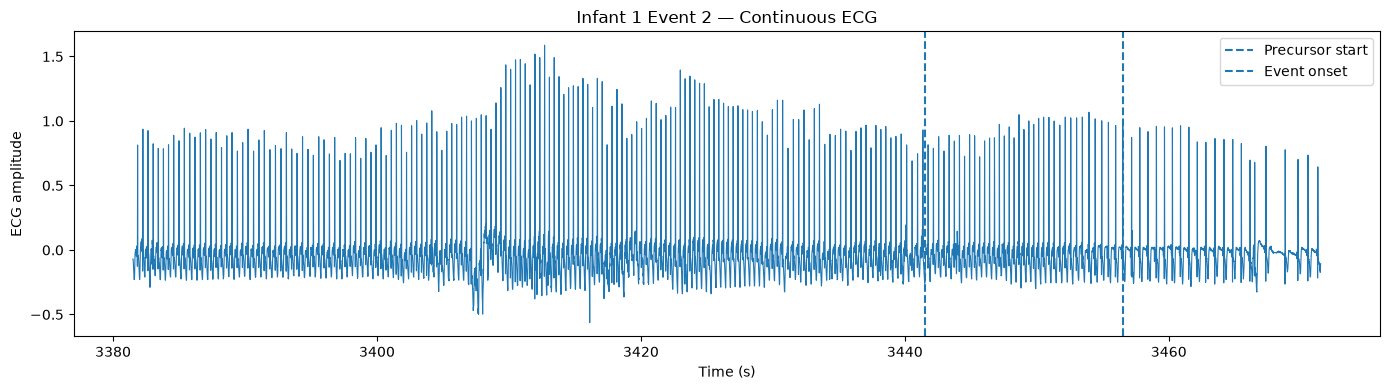

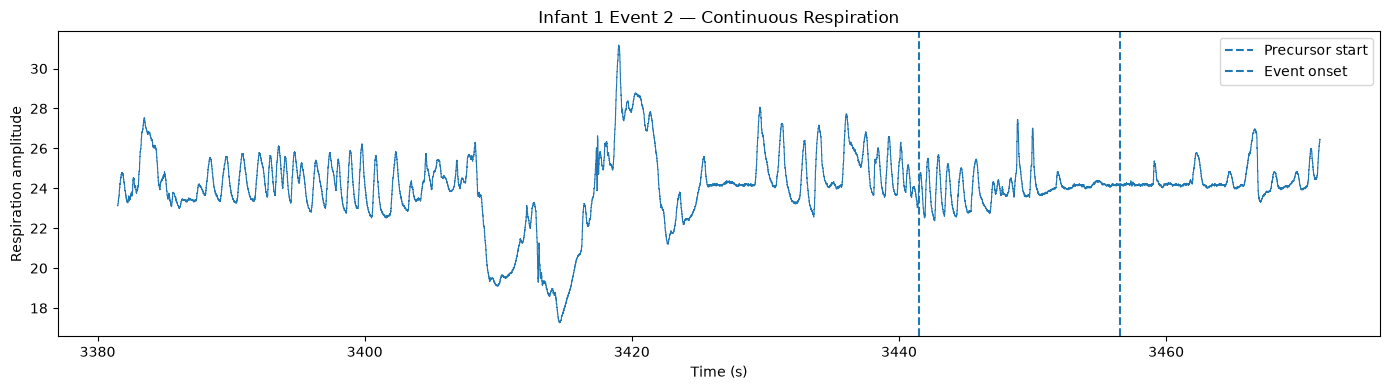


PASS: CONTINUOUS EVENT WINDOW EXTRACTED
STATUS: DEVELOPMENT / VISUAL INSPECTION


In [ ]:
# Cell 64 — Inspect continuous ECG + respiration around one precursor event
#
# Purpose:
# Verify the continuous physiological signals around Infant 1 Event 2
# before designing the temporal sequence extraction.
#
# No training data is created and no model is trained.

print("=" * 70)
print("CONTINUOUS PRECURSOR EVENT INSPECTION")
print("=" * 70)

# Select the first frozen precursor event
event_row = precursor_events.iloc[0]

INFANT = int(event_row["infant"])
EVENT_NUMBER = int(event_row["event_number"])
EVENT_TIME = float(event_row["event_time_s"])
PRECURSOR_START = float(event_row["precursor_start_s"])
PRECURSOR_END = float(event_row["precursor_end_s"])

# Context around the event
CONTEXT_BEFORE_S = 60.0
CONTEXT_AFTER_S = 15.0

WINDOW_START = PRECURSOR_START - CONTEXT_BEFORE_S
WINDOW_END = EVENT_TIME + CONTEXT_AFTER_S

print(f"\nInfant             : {INFANT}")
print(f"Event number       : {EVENT_NUMBER}")
print(f"Event time         : {EVENT_TIME:.3f} s")
print(f"Precursor start    : {PRECURSOR_START:.3f} s")
print(f"Precursor end      : {PRECURSOR_END:.3f} s")
print(f"Inspection start   : {WINDOW_START:.3f} s")
print(f"Inspection end     : {WINDOW_END:.3f} s")

# Load recording headers first
ecg_header = wfdb.rdheader(
    f"infant{INFANT}_ecg",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

resp_header = wfdb.rdheader(
    f"infant{INFANT}_resp",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}"
)

ecg_fs = float(ecg_header.fs)
resp_fs = float(resp_header.fs)

print(f"\nECG sampling rate  : {ecg_fs} Hz")
print(f"RESP sampling rate : {resp_fs} Hz")

# Convert requested time range into sample indices
ecg_start = int(round(WINDOW_START * ecg_fs))
ecg_end = int(round(WINDOW_END * ecg_fs))

resp_start = int(round(WINDOW_START * resp_fs))
resp_end = int(round(WINDOW_END * resp_fs))

# Read only the required continuous region
ecg_record = wfdb.rdrecord(
    f"infant{INFANT}_ecg",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}",
    sampfrom=ecg_start,
    sampto=ecg_end
)

resp_record = wfdb.rdrecord(
    f"infant{INFANT}_resp",
    pn_dir=f"{PICS_DB}/{PICS_VERSION}",
    sampfrom=resp_start,
    sampto=resp_end
)

ecg_signal = np.asarray(
    ecg_record.p_signal[:, 0],
    dtype=float
)

resp_signal = np.asarray(
    resp_record.p_signal[:, 0],
    dtype=float
)

# Verify expected duration
expected_duration = WINDOW_END - WINDOW_START

actual_ecg_duration = len(ecg_signal) / ecg_fs
actual_resp_duration = len(resp_signal) / resp_fs

print("\nSignal extraction:")
print(f"ECG samples        : {len(ecg_signal)}")
print(f"RESP samples       : {len(resp_signal)}")
print(f"Expected duration  : {expected_duration:.3f} s")
print(f"ECG duration       : {actual_ecg_duration:.3f} s")
print(f"RESP duration      : {actual_resp_duration:.3f} s")

# Numerical integrity
assert len(ecg_signal) > 0
assert len(resp_signal) > 0
assert np.isfinite(ecg_signal).all()
assert np.isfinite(resp_signal).all()

# Create time axes
ecg_time = WINDOW_START + np.arange(len(ecg_signal)) / ecg_fs
resp_time = WINDOW_START + np.arange(len(resp_signal)) / resp_fs

# Plot continuous ECG
plt.figure(figsize=(14, 4))
plt.plot(ecg_time, ecg_signal, linewidth=0.8)

plt.axvline(
    PRECURSOR_START,
    linestyle="--",
    label="Precursor start"
)

plt.axvline(
    PRECURSOR_END,
    linestyle="--",
    label="Event onset"
)

plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude")
plt.title(
    f"Infant {INFANT} Event {EVENT_NUMBER} — Continuous ECG"
)
plt.legend()
plt.tight_layout()
plt.show()

# Plot continuous respiration
plt.figure(figsize=(14, 4))
plt.plot(resp_time, resp_signal, linewidth=0.8)

plt.axvline(
    PRECURSOR_START,
    linestyle="--",
    label="Precursor start"
)

plt.axvline(
    PRECURSOR_END,
    linestyle="--",
    label="Event onset"
)

plt.xlabel("Time (s)")
plt.ylabel("Respiration amplitude")
plt.title(
    f"Infant {INFANT} Event {EVENT_NUMBER} — Continuous Respiration"
)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("PASS: CONTINUOUS EVENT WINDOW EXTRACTED")
print("STATUS: DEVELOPMENT / VISUAL INSPECTION")
print("=" * 70)

In [ ]:
# Cell 65 — Build 5-second sliding windows inside one precursor
#
# Purpose:
# Verify temporal feature-window construction for the GRU / 1D-CNN.
#
# Window length : 5 seconds
# Step          : 1 second
# Precursor     : 15 seconds
#
# No model training is performed here.

print("=" * 70)
print("TEMPORAL FEATURE WINDOW CONSTRUCTION")
print("=" * 70)

FEATURE_WINDOW_S = 5.0
FEATURE_STEP_S = 1.0

# Use the continuous signals already extracted in Cell 64.
# We only use the actual precursor interval.
precursor_start = PRECURSOR_START
precursor_end = PRECURSOR_END

# Build window start times.
window_starts = np.arange(
    precursor_start,
    precursor_end - FEATURE_WINDOW_S + 1e-9,
    FEATURE_STEP_S
)

window_ends = window_starts + FEATURE_WINDOW_S

print(f"\nPrecursor interval : {precursor_start:.3f}–{precursor_end:.3f} s")
print(f"Feature window     : {FEATURE_WINDOW_S:.1f} s")
print(f"Feature step       : {FEATURE_STEP_S:.1f} s")
print(f"Number of windows  : {len(window_starts)}")

temporal_window_records = []

for start_s, end_s in zip(window_starts, window_ends):

    # Convert absolute recording time into indices
    # relative to the continuous signal extracted in Cell 64.
    ecg_i0 = int(round((start_s - WINDOW_START) * ecg_fs))
    ecg_i1 = int(round((end_s - WINDOW_START) * ecg_fs))

    resp_i0 = int(round((start_s - WINDOW_START) * resp_fs))
    resp_i1 = int(round((end_s - WINDOW_START) * resp_fs))

    ecg_segment = ecg_signal[ecg_i0:ecg_i1]
    resp_segment = resp_signal[resp_i0:resp_i1]

    expected_ecg_samples = int(round(FEATURE_WINDOW_S * ecg_fs))
    expected_resp_samples = int(round(FEATURE_WINDOW_S * resp_fs))

    assert len(ecg_segment) == expected_ecg_samples
    assert len(resp_segment) == expected_resp_samples

    assert np.isfinite(ecg_segment).all()
    assert np.isfinite(resp_segment).all()

    temporal_window_records.append({
        "window_start_s": float(start_s),
        "window_end_s": float(end_s),
        "ecg_samples": len(ecg_segment),
        "resp_samples": len(resp_segment)
    })

temporal_window_inventory = pd.DataFrame(
    temporal_window_records
)

print("\nConstructed temporal windows:")
print(
    temporal_window_inventory.to_string(index=False)
)

print("\nExpected structure:")
print(
    f"First window : "
    f"{window_starts[0]:.3f}–{window_ends[0]:.3f} s"
)

print(
    f"Last window  : "
    f"{window_starts[-1]:.3f}–{window_ends[-1]:.3f} s"
)

print(
    f"Overlap between consecutive windows: "
    f"{FEATURE_WINDOW_S - FEATURE_STEP_S:.1f} s"
)

print("\n" + "=" * 70)
print("PASS: TEMPORAL WINDOWS CONSTRUCTED")
print("STATUS: DEVELOPMENT / SEQUENCE DESIGN")
print("=" * 70)

TEMPORAL FEATURE WINDOW CONSTRUCTION

Precursor interval : 3441.512–3456.512 s
Feature window     : 5.0 s
Feature step       : 1.0 s
Number of windows  : 11

Constructed temporal windows:
 window_start_s  window_end_s  ecg_samples  resp_samples
       3441.512      3446.512         1250          2500
       3442.512      3447.512         1250          2500
       3443.512      3448.512         1250          2500
       3444.512      3449.512         1250          2500
       3445.512      3450.512         1250          2500
       3446.512      3451.512         1250          2500
       3447.512      3452.512         1250          2500
       3448.512      3453.512         1250          2500
       3449.512      3454.512         1250          2500
       3450.512      3455.512         1250          2500
       3451.512      3456.512         1250          2500

Expected structure:
First window : 3441.512–3446.512 s
Last window  : 3451.512–3456.512 s
Overlap between consecutive windows: 

In [ ]:
# Cell 66 — Verify temporal window construction for all precursor events
#
# Purpose:
# Confirm that every frozen precursor event has exactly 11 valid
# overlapping 5-second windows with continuous ECG + respiration.
#
# No feature extraction or model training is performed here.

print("=" * 70)
print("ALL PRECURSOR TEMPORAL WINDOW VERIFICATION")
print("=" * 70)

FEATURE_WINDOW_S = 5.0
FEATURE_STEP_S = 1.0

all_temporal_window_inventory = []

for _, event_row in precursor_events.iterrows():

    infant = int(event_row["infant"])
    event_number = int(event_row["event_number"])
    event_time = float(event_row["event_time_s"])
    precursor_start = float(event_row["precursor_start_s"])
    precursor_end = float(event_row["precursor_end_s"])

    window_starts = np.arange(
        precursor_start,
        precursor_end - FEATURE_WINDOW_S + 1e-9,
        FEATURE_STEP_S
    )

    window_ends = window_starts + FEATURE_WINDOW_S

    assert len(window_starts) == 11

    # Load headers to obtain sampling rates
    ecg_header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    resp_header = wfdb.rdheader(
        f"infant{infant}_resp",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    ecg_fs_event = float(ecg_header.fs)
    resp_fs_event = float(resp_header.fs)

    # Extract the complete precursor once.
    ecg_start_idx = int(round(precursor_start * ecg_fs_event))
    ecg_end_idx = int(round(precursor_end * ecg_fs_event))

    resp_start_idx = int(round(precursor_start * resp_fs_event))
    resp_end_idx = int(round(precursor_end * resp_fs_event))

    ecg_record_event = wfdb.rdrecord(
        f"infant{infant}_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=ecg_start_idx,
        sampto=ecg_end_idx
    )

    resp_record_event = wfdb.rdrecord(
        f"infant{infant}_resp",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}",
        sampfrom=resp_start_idx,
        sampto=resp_end_idx
    )

    ecg_event_signal = np.asarray(
        ecg_record_event.p_signal[:, 0],
        dtype=float
    )

    resp_event_signal = np.asarray(
        resp_record_event.p_signal[:, 0],
        dtype=float
    )

    expected_ecg_total = int(round(15.0 * ecg_fs_event))
    expected_resp_total = int(round(15.0 * resp_fs_event))

    assert len(ecg_event_signal) == expected_ecg_total
    assert len(resp_event_signal) == expected_resp_total

    assert np.isfinite(ecg_event_signal).all()
    assert np.isfinite(resp_event_signal).all()

    for sequence_index, (start_s, end_s) in enumerate(
        zip(window_starts, window_ends),
        start=1
    ):

        # Convert to indices relative to the extracted precursor.
        ecg_i0 = int(round(
            (start_s - precursor_start) * ecg_fs_event
        ))
        ecg_i1 = int(round(
            (end_s - precursor_start) * ecg_fs_event
        ))

        resp_i0 = int(round(
            (start_s - precursor_start) * resp_fs_event
        ))
        resp_i1 = int(round(
            (end_s - precursor_start) * resp_fs_event
        ))

        ecg_segment = ecg_event_signal[ecg_i0:ecg_i1]
        resp_segment = resp_event_signal[resp_i0:resp_i1]

        expected_ecg_samples = int(round(
            FEATURE_WINDOW_S * ecg_fs_event
        ))
        expected_resp_samples = int(round(
            FEATURE_WINDOW_S * resp_fs_event
        ))

        assert len(ecg_segment) == expected_ecg_samples
        assert len(resp_segment) == expected_resp_samples

        assert np.isfinite(ecg_segment).all()
        assert np.isfinite(resp_segment).all()

        all_temporal_window_inventory.append({
            "infant": infant,
            "event_number": event_number,
            "event_time_s": event_time,
            "sequence_index": sequence_index,
            "window_start_s": float(start_s),
            "window_end_s": float(end_s),
            "ecg_fs": ecg_fs_event,
            "resp_fs": resp_fs_event,
            "ecg_samples": len(ecg_segment),
            "resp_samples": len(resp_segment)
        })

all_temporal_window_inventory_df = pd.DataFrame(
    all_temporal_window_inventory
)

# Global integrity checks
assert len(all_temporal_window_inventory_df) == 55

assert (
    all_temporal_window_inventory_df
    .groupby(["infant", "event_number"])
    .size()
    .eq(11)
    .all()
)

assert (
    all_temporal_window_inventory_df
    .groupby(["infant", "event_number"])["sequence_index"]
    .apply(lambda x: list(x) == list(range(1, 12)))
    .all()
)

print(
    f"\nPrecursor events verified : "
    f"{precursor_events.shape[0]}"
)

print(
    f"Temporal windows created  : "
    f"{len(all_temporal_window_inventory_df)}"
)

print("\nWindows per precursor event:")
print(
    all_temporal_window_inventory_df
    .groupby(["infant", "event_number"])
    .size()
    .rename("window_count")
    .to_string()
)

print("\nSampling rates:")
print(
    all_temporal_window_inventory_df[
        ["infant", "ecg_fs", "resp_fs"]
    ]
    .drop_duplicates()
    .sort_values("infant")
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("PASS: ALL 5 PRECURSOR EVENTS HAVE 11 VALID TEMPORAL WINDOWS")
print("TOTAL TEMPORAL WINDOWS: 55")
print("STATUS: DEVELOPMENT / SEQUENCE DESIGN")
print("=" * 70)

ALL PRECURSOR TEMPORAL WINDOW VERIFICATION

Precursor events verified : 5
Temporal windows created  : 55

Windows per precursor event:
infant  event_number
1       2               11
3       2               11
        3               11
9       1               11
        2               11

Sampling rates:
 infant  ecg_fs  resp_fs
      1   250.0    500.0
      3   500.0     50.0
      9   500.0     50.0

PASS: ALL 5 PRECURSOR EVENTS HAVE 11 VALID TEMPORAL WINDOWS
TOTAL TEMPORAL WINDOWS: 55
STATUS: DEVELOPMENT / SEQUENCE DESIGN


In [ ]:
# Cell 67 — Build complete temporal sequence inventory
#
# Corrected:
# Control windows have no event_number, so NaN is preserved.
#
# Each frozen 15-second window becomes one sequence:
#   11 overlapping 5-second windows
#   1-second stride
#
# No signal processing or model training is performed here.

print("=" * 70)
print("TEMPORAL SEQUENCE INVENTORY")
print("=" * 70)

SEQUENCE_DURATION_S = 15.0
FEATURE_WINDOW_S = 5.0
FEATURE_STEP_S = 1.0
EXPECTED_SEQUENCE_STEPS = 11

sequence_inventory_records = []

# Work from the frozen dataset
sequence_source_df = final_feature_dataset.copy()

for row_index, row in sequence_source_df.iterrows():

    infant = int(row["infant"])

    # Precursor rows have an event number.
    # Control rows intentionally have NaN.
    if pd.notna(row["event_number"]):
        event_number = int(row["event_number"])
    else:
        event_number = np.nan

    risk_label = int(row["risk_label"])
    window_type = str(row["window_type"])

    # Determine the actual 15-second sequence interval
    if risk_label == 1:
        sequence_start = float(row["precursor_start_s"])
        sequence_end = float(row["precursor_end_s"])
    else:
        sequence_start = float(row["control_start_s"])
        sequence_end = float(row["control_end_s"])

    duration = sequence_end - sequence_start

    # Every frozen window must represent exactly 15 seconds
    assert np.isclose(
        duration,
        SEQUENCE_DURATION_S,
        atol=1e-6
    ), (
        f"Invalid duration for row {row_index}: "
        f"{duration}"
    )

    # Construct 11 overlapping feature windows
    step_starts = np.arange(
        sequence_start,
        sequence_end - FEATURE_WINDOW_S + 1e-9,
        FEATURE_STEP_S
    )

    step_ends = step_starts + FEATURE_WINDOW_S

    assert len(step_starts) == EXPECTED_SEQUENCE_STEPS

    for sequence_index, (step_start, step_end) in enumerate(
        zip(step_starts, step_ends),
        start=1
    ):

        sequence_inventory_records.append({
            "source_row_index": int(row_index),
            "infant": infant,
            "event_number": event_number,
            "risk_label": risk_label,
            "window_type": window_type,
            "sequence_start_s": sequence_start,
            "sequence_end_s": sequence_end,
            "sequence_index": sequence_index,
            "feature_window_start_s": float(step_start),
            "feature_window_end_s": float(step_end)
        })

temporal_sequence_inventory = pd.DataFrame(
    sequence_inventory_records
)

# ------------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------------

expected_rows = (
    len(final_feature_dataset)
    * EXPECTED_SEQUENCE_STEPS
)

assert len(temporal_sequence_inventory) == expected_rows

# Every source sequence must have exactly 11 time steps
steps_per_sequence = (
    temporal_sequence_inventory
    .groupby("source_row_index")
    .size()
)

assert steps_per_sequence.eq(
    EXPECTED_SEQUENCE_STEPS
).all()

# Every source row must appear exactly once as a sequence source
assert (
    temporal_sequence_inventory["source_row_index"]
    .nunique()
    == len(final_feature_dataset)
)

# Sequence labels must remain unchanged
sequence_labels = (
    temporal_sequence_inventory
    .groupby("source_row_index")["risk_label"]
    .nunique()
)

assert sequence_labels.eq(1).all()

# Verify event-number behavior
precursor_event_numbers = temporal_sequence_inventory.loc[
    temporal_sequence_inventory["risk_label"] == 1,
    "event_number"
]

control_event_numbers = temporal_sequence_inventory.loc[
    temporal_sequence_inventory["risk_label"] == 0,
    "event_number"
]

assert precursor_event_numbers.notna().all()
assert control_event_numbers.isna().all()

# Sequence-level class distribution
sequence_level_summary = (
    sequence_source_df
    .groupby("risk_label")
    .size()
)

print("\nSequence-level dataset:")
print(
    sequence_level_summary.rename(
        index={
            0: "Control",
            1: "Precursor"
        }
    ).to_string()
)

print("\nTemporal sequence dimensions:")
print(f"Sequences          : {len(sequence_source_df)}")
print(f"Time steps/sequence: {EXPECTED_SEQUENCE_STEPS}")
print(f"Features/step      : {len(PHYSIOLOGICAL_FEATURES)}")
print(
    f"Total feature windows: "
    f"{len(temporal_sequence_inventory)}"
)

print("\nExpected model input shape:")
print(
    f"({len(sequence_source_df)}, "
    f"{EXPECTED_SEQUENCE_STEPS}, "
    f"{len(PHYSIOLOGICAL_FEATURES)})"
)

print("\nSequences by infant:")

sequence_counts_by_infant = (
    sequence_source_df
    .groupby(["infant", "risk_label"])
    .size()
    .unstack(fill_value=0)
)

sequence_counts_by_infant = (
    sequence_counts_by_infant
    .rename(columns={
        0: "control_sequences",
        1: "precursor_sequences"
    })
)

print(
    sequence_counts_by_infant.to_string()
)

print("\n" + "=" * 70)
print("PASS: COMPLETE TEMPORAL SEQUENCE INVENTORY CREATED")
print("STATUS: DEVELOPMENT / SEQUENCE DESIGN")
print("=" * 70)

TEMPORAL SEQUENCE INVENTORY

Sequence-level dataset:
risk_label
Control      50
Precursor     5

Temporal sequence dimensions:
Sequences          : 55
Time steps/sequence: 11
Features/step      : 20
Total feature windows: 605

Expected model input shape:
(55, 11, 20)

Sequences by infant:
risk_label  control_sequences  precursor_sequences
infant                                            
1                           5                    1
2                           5                    0
3                           5                    2
4                           5                    0
5                           5                    0
6                           5                    0
7                           5                    0
8                           5                    0
9                           5                    2
10                          5                    0

PASS: COMPLETE TEMPORAL SEQUENCE INVENTORY CREATED
STATUS: DEVELOPMENT / SEQUENCE DESIGN


In [ ]:
# Cell 68 — Extract temporal physiological features
#
# Each frozen 15-second sequence:
#   11 overlapping 5-second windows
#   1-second stride
#   20 physiological features per step
#
# Output:
#   temporal feature tensor = (55, 11, 20)
#
# DEVELOPMENT / SEQUENCE CONSTRUCTION ONLY.
# No model training is performed here.

from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, find_peaks
import time

print("=" * 70)
print("TEMPORAL PHYSIOLOGICAL FEATURE EXTRACTION")
print("=" * 70)

# ------------------------------------------------------------------
# Fixed parameters
# ------------------------------------------------------------------

FEATURE_WINDOW_S = 5.0
FEATURE_STEP_S = 1.0
CONTEXT_S = 60.0

ECG_LOW_HZ = 0.5
ECG_HIGH_HZ = 40.0
ECG_FILTER_ORDER = 4
NOTCH_FREQ_HZ = 50.0
NOTCH_Q = 30.0

RESP_LOW_HZ = 0.03
RESP_HIGH_HZ = 2.0
RESP_FILTER_ORDER = 4

ECG_MIN_PEAK_DISTANCE_S = 0.30
RESP_MIN_PEAK_DISTANCE_S = 0.80

RR_MIN_S = 0.30
RR_MAX_S = 2.00

RESP_INTERVAL_MIN_S = 0.80
RESP_INTERVAL_MAX_S = 10.0

EXPECTED_STEPS = 11
EXPECTED_FEATURES = len(PHYSIOLOGICAL_FEATURES)

# ------------------------------------------------------------------
# Self-contained signal preprocessing
# ------------------------------------------------------------------

def preprocess_ecg_temporal(signal, fs):
    signal = np.asarray(signal, dtype=float)

    # Bandpass using SOS for numerical stability
    sos = butter(
        ECG_FILTER_ORDER,
        [ECG_LOW_HZ, ECG_HIGH_HZ],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(sos, signal)

    # 50-Hz notch
    b_notch, a_notch = iirnotch(
        NOTCH_FREQ_HZ,
        NOTCH_Q,
        fs=fs
    )

    filtered = filtfilt(
        b_notch,
        a_notch,
        filtered
    )

    return filtered


def preprocess_resp_temporal(signal, fs):
    signal = np.asarray(signal, dtype=float)

    sos = butter(
        RESP_FILTER_ORDER,
        [RESP_LOW_HZ, RESP_HIGH_HZ],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    return sosfiltfilt(sos, signal)


# ------------------------------------------------------------------
# Feature extraction for one 5-second window
# ------------------------------------------------------------------

def extract_temporal_features(ecg_segment, resp_segment, ecg_fs, resp_fs):

    ecg_segment = np.asarray(ecg_segment, dtype=float)
    resp_segment = np.asarray(resp_segment, dtype=float)

    assert np.isfinite(ecg_segment).all()
    assert np.isfinite(resp_segment).all()

    # --------------------------------------------------------------
    # ECG amplitude features
    # --------------------------------------------------------------

    ecg_mean = float(np.mean(ecg_segment))
    ecg_std = float(np.std(ecg_segment))
    ecg_rms = float(np.sqrt(np.mean(ecg_segment ** 2)))

    # --------------------------------------------------------------
    # ECG R-peaks
    # --------------------------------------------------------------

    ecg_peaks, _ = find_peaks(
        ecg_segment,
        distance=int(round(
            ECG_MIN_PEAK_DISTANCE_S * ecg_fs
        )),
        prominence=0.3
    )

    r_peak_count = int(len(ecg_peaks))

    # --------------------------------------------------------------
    # RR / HR features
    # --------------------------------------------------------------

    if len(ecg_peaks) >= 2:

        peak_times = ecg_peaks / ecg_fs
        rr_intervals = np.diff(peak_times)

        # Retain physiologically plausible RR intervals
        rr_valid = rr_intervals[
            (rr_intervals >= RR_MIN_S) &
            (rr_intervals <= RR_MAX_S)
        ]

    else:
        rr_valid = np.array([], dtype=float)

    if len(rr_valid) > 0:

        hr_values = 60.0 / rr_valid

        mean_rr = float(np.mean(rr_valid))
        std_rr = float(np.std(rr_valid))

        mean_hr = float(np.mean(hr_values))
        min_hr = float(np.min(hr_values))
        max_hr = float(np.max(hr_values))
        std_hr = float(np.std(hr_values))

        # SDNN and RMSSD in seconds
        sdnn = float(np.std(rr_valid, ddof=0))

        if len(rr_valid) >= 2:
            successive_differences = np.diff(rr_valid)
            rmssd = float(
                np.sqrt(
                    np.mean(successive_differences ** 2)
                )
            )
        else:
            rmssd = 0.0

    else:

        mean_rr = np.nan
        std_rr = np.nan
        mean_hr = np.nan
        min_hr = np.nan
        max_hr = np.nan
        std_hr = np.nan
        sdnn = np.nan
        rmssd = np.nan

    # --------------------------------------------------------------
    # Respiration amplitude features
    # --------------------------------------------------------------

    resp_mean = float(np.mean(resp_segment))
    resp_std = float(np.std(resp_segment))
    resp_rms = float(
        np.sqrt(np.mean(resp_segment ** 2))
    )

    # --------------------------------------------------------------
    # Respiration peaks
    # --------------------------------------------------------------

    # Use the validated minimum separation.
    # A relative prominence avoids counting tiny numerical fluctuations
    # as breaths in very low-amplitude windows.
    resp_prominence = max(
        0.05 * float(np.std(resp_segment)),
        1e-8
    )

    resp_peaks, _ = find_peaks(
        resp_segment,
        distance=int(round(
            RESP_MIN_PEAK_DISTANCE_S * resp_fs
        )),
        prominence=resp_prominence
    )

    resp_peak_count = int(len(resp_peaks))

    # --------------------------------------------------------------
    # Respiration interval / rate features
    # --------------------------------------------------------------

    if len(resp_peaks) >= 2:

        resp_peak_times = resp_peaks / resp_fs
        resp_intervals = np.diff(resp_peak_times)

        resp_intervals = resp_intervals[
            (resp_intervals >= RESP_INTERVAL_MIN_S) &
            (resp_intervals <= RESP_INTERVAL_MAX_S)
        ]

    else:
        resp_intervals = np.array([], dtype=float)

    if len(resp_intervals) > 0:

        resp_rates = 60.0 / resp_intervals

        mean_resp_interval = float(
            np.mean(resp_intervals)
        )

        std_resp_interval = float(
            np.std(resp_intervals)
        )

        mean_resp_rate = float(
            np.mean(resp_rates)
        )

        std_resp_rate = float(
            np.std(resp_rates)
        )

    else:

        mean_resp_interval = np.nan
        std_resp_interval = np.nan
        mean_resp_rate = np.nan
        std_resp_rate = np.nan

    features = {
        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,
        "r_peak_count": r_peak_count,
        "mean_rr": mean_rr,
        "std_rr": std_rr,
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd,
        "resp_mean": resp_mean,
        "resp_std": resp_std,
        "resp_rms": resp_rms,
        "resp_peak_count": resp_peak_count,
        "mean_resp_interval": mean_resp_interval,
        "std_resp_interval": std_resp_interval,
        "mean_resp_rate": mean_resp_rate,
        "std_resp_rate": std_resp_rate
    }

    return features


# ------------------------------------------------------------------
# Extract one complete sequence at a time
# ------------------------------------------------------------------

temporal_feature_records = []

sequence_ids = (
    temporal_sequence_inventory[
        ["source_row_index"]
    ]
    .drop_duplicates()
    .sort_values("source_row_index")
    ["source_row_index"]
    .tolist()
)

print(f"\nSequences to process: {len(sequence_ids)}")
print(f"Time steps/sequence : {EXPECTED_STEPS}")
print(f"Features/time step  : {EXPECTED_FEATURES}")

start_time = time.time()

for sequence_counter, source_row_index in enumerate(
    sequence_ids,
    start=1
):

    source_row = final_feature_dataset.loc[source_row_index]

    infant = int(source_row["infant"])
    risk_label = int(source_row["risk_label"])

    if pd.notna(source_row["event_number"]):
        event_number = int(source_row["event_number"])
    else:
        event_number = np.nan

    # Determine 15-second sequence interval
    if risk_label == 1:
        sequence_start = float(
            source_row["precursor_start_s"]
        )
        sequence_end = float(
            source_row["precursor_end_s"]
        )
    else:
        sequence_start = float(
            source_row["control_start_s"]
        )
        sequence_end = float(
            source_row["control_end_s"]
        )

    # Read headers for exact sampling rates
    ecg_header = wfdb.rdheader(
        f"infant{infant}_ecg",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    resp_header = wfdb.rdheader(
        f"infant{infant}_resp",
        pn_dir=f"{PICS_DB}/{PICS_VERSION}"
    )

    ecg_fs = float(ecg_header.fs)
    resp_fs = float(resp_header.fs)

    # --------------------------------------------------------------
    # Read 60 seconds of context on both sides.
    # Filtering the extended signal reduces edge effects.
    # --------------------------------------------------------------

    context_start = max(
        0.0,
        sequence_start - CONTEXT_S
    )

    context_end = sequence_end + CONTEXT_S

    ecg_start_idx = int(round(
        context_start * ecg_fs
    ))
    ecg_end_idx = int(round(
        context_end * ecg_fs
    ))

    resp_start_idx = int(round(
        context_start * resp_fs
    ))
    resp_end_idx = int(round(
        context_end * resp_fs
    ))

    # Read continuous ECG
    ecg_record = None
    last_ecg_error = None

    for attempt in range(5):
        try:
            ecg_record = wfdb.rdrecord(
                f"infant{infant}_ecg",
                pn_dir=f"{PICS_DB}/{PICS_VERSION}",
                sampfrom=ecg_start_idx,
                sampto=ecg_end_idx
            )
            break
        except Exception as exc:
            last_ecg_error = exc
            time.sleep(1.0)

    if ecg_record is None:
        raise RuntimeError(
            f"ECG read failed for Infant {infant}, "
            f"row {source_row_index}: {last_ecg_error}"
        )

    # Read continuous respiration
    resp_record = None
    last_resp_error = None

    for attempt in range(5):
        try:
            resp_record = wfdb.rdrecord(
                f"infant{infant}_resp",
                pn_dir=f"{PICS_DB}/{PICS_VERSION}",
                sampfrom=resp_start_idx,
                sampto=resp_end_idx
            )
            break
        except Exception as exc:
            last_resp_error = exc
            time.sleep(1.0)

    if resp_record is None:
        raise RuntimeError(
            f"RESP read failed for Infant {infant}, "
            f"row {source_row_index}: {last_resp_error}"
        )

    ecg_context = np.asarray(
        ecg_record.p_signal[:, 0],
        dtype=float
    )

    resp_context = np.asarray(
        resp_record.p_signal[:, 0],
        dtype=float
    )

    assert len(ecg_context) > 0
    assert len(resp_context) > 0

    assert np.isfinite(ecg_context).all()
    assert np.isfinite(resp_context).all()

    # --------------------------------------------------------------
    # Filter the extended continuous signals
    # --------------------------------------------------------------

    ecg_filtered = preprocess_ecg_temporal(
        ecg_context,
        ecg_fs
    )

    resp_filtered = preprocess_resp_temporal(
        resp_context,
        resp_fs
    )

    assert np.isfinite(ecg_filtered).all()
    assert np.isfinite(resp_filtered).all()

    # --------------------------------------------------------------
    # Extract 11 overlapping temporal feature windows
    # --------------------------------------------------------------

    step_starts = np.arange(
        sequence_start,
        sequence_end - FEATURE_WINDOW_S + 1e-9,
        FEATURE_STEP_S
    )

    step_ends = (
        step_starts + FEATURE_WINDOW_S
    )

    assert len(step_starts) == EXPECTED_STEPS

    for sequence_index, (
        step_start,
        step_end
    ) in enumerate(
        zip(step_starts, step_ends),
        start=1
    ):

        ecg_i0 = int(round(
            (step_start - context_start) * ecg_fs
        ))
        ecg_i1 = int(round(
            (step_end - context_start) * ecg_fs
        ))

        resp_i0 = int(round(
            (step_start - context_start) * resp_fs
        ))
        resp_i1 = int(round(
            (step_end - context_start) * resp_fs
        ))

        ecg_segment = ecg_filtered[
            ecg_i0:ecg_i1
        ]

        resp_segment = resp_filtered[
            resp_i0:resp_i1
        ]

        expected_ecg_samples = int(round(
            FEATURE_WINDOW_S * ecg_fs
        ))

        expected_resp_samples = int(round(
            FEATURE_WINDOW_S * resp_fs
        ))

        assert len(ecg_segment) == expected_ecg_samples
        assert len(resp_segment) == expected_resp_samples

        assert np.isfinite(ecg_segment).all()
        assert np.isfinite(resp_segment).all()

        features = extract_temporal_features(
            ecg_segment,
            resp_segment,
            ecg_fs,
            resp_fs
        )

        # Add sequence metadata
        record = {
            "source_row_index": int(source_row_index),
            "infant": infant,
            "event_number": event_number,
            "risk_label": risk_label,
            "window_type": str(
                source_row["window_type"]
            ),
            "sequence_start_s": sequence_start,
            "sequence_end_s": sequence_end,
            "sequence_index": sequence_index,
            "feature_window_start_s": float(
                step_start
            ),
            "feature_window_end_s": float(
                step_end
            )
        }

        record.update(features)

        temporal_feature_records.append(record)

    if (
        sequence_counter == 1
        or sequence_counter % 10 == 0
        or sequence_counter == len(sequence_ids)
    ):
        elapsed = time.time() - start_time
        print(
            f"Processed {sequence_counter:2d}/"
            f"{len(sequence_ids)} sequences "
            f"({elapsed:.1f} s)"
        )

# ------------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------------

temporal_features_df = pd.DataFrame(
    temporal_feature_records
)

expected_rows = (
    len(final_feature_dataset)
    * EXPECTED_STEPS
)

assert len(temporal_features_df) == expected_rows

# Verify every sequence has exactly 11 steps
steps_per_sequence = (
    temporal_features_df
    .groupby("source_row_index")
    .size()
)

assert steps_per_sequence.eq(
    EXPECTED_STEPS
).all()

# Verify all 20 features exist
missing_features = [
    feature for feature in PHYSIOLOGICAL_FEATURES
    if feature not in temporal_features_df.columns
]

assert len(missing_features) == 0

# ------------------------------------------------------------------
# Numerical QC
# ------------------------------------------------------------------

feature_matrix_temporal = temporal_features_df[
    PHYSIOLOGICAL_FEATURES
].to_numpy(dtype=float)

finite_mask = np.isfinite(
    feature_matrix_temporal
)

finite_count = int(finite_mask.sum())
total_count = int(finite_mask.size)

print("\n" + "=" * 70)
print("TEMPORAL FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\nTemporal feature rows : {len(temporal_features_df)}")
print(f"Expected rows         : {expected_rows}")
print(f"Feature columns       : {EXPECTED_FEATURES}")
print(f"Finite values         : {finite_count}/{total_count}")

print("\nMissing values by feature:")
missing_summary = (
    temporal_features_df[
        PHYSIOLOGICAL_FEATURES
    ]
    .isna()
    .sum()
)

print(
    missing_summary[
        missing_summary > 0
    ].to_string()
    if (missing_summary > 0).any()
    else "None"
)

print("\nSequence shape:")
print(
    f"({len(final_feature_dataset)}, "
    f"{EXPECTED_STEPS}, "
    f"{EXPECTED_FEATURES})"
)

print("\n" + "=" * 70)
print("STATUS: TEMPORAL FEATURE EXTRACTION")
print("=" * 70)